In [1]:
# standard
import gc
import logging
import numpy as np
import pandas as pd
from pathlib import Path

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# stats et clustering
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations
from kneed import KneeLocator

# config plotly
pio.renderers.default = 'notebook'

In [2]:
# charte graphique globale
PALETTE = {
    'ink': '#243746',
    'muted': '#6c7a86',
    'grid': '#d9e2ea',
    'paper': '#f7f4ef',
    'panel': '#fffdf8',
    'primary': '#2f6c7a',
    'secondary': '#c97b63',
    'accent': '#d7a84a',
    'success': '#5b8f72',
    'danger': '#bf5a4f',
    'cluster_1': '#2f6c7a',
    'cluster_2': '#c97b63',
    'cluster_3': '#5b8f72',
    'cluster_4': '#8f6f9a',
    'cluster_5': '#d7a84a',
}
SERIES_COLORS = [
    PALETTE['primary'],
    PALETTE['secondary'],
    PALETTE['success'],
    PALETTE['cluster_4'],
    PALETTE['accent'],
    '#5f8fa3',
    '#a86a78',
]
CLUSTER_COLORS = [
    PALETTE['cluster_1'],
    PALETTE['cluster_2'],
    PALETTE['cluster_3'],
    PALETTE['cluster_4'],
    PALETTE['cluster_5'],
]
HEATMAP_CMAP = sns.diverging_palette(20, 190, s=85, l=55, center='light', as_cmap=True)
EMISSIONS_CMAP = sns.blend_palette([PALETTE['paper'], PALETTE['accent'], PALETTE['danger']], as_cmap=True)
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette=SERIES_COLORS,
    rc={
        'axes.facecolor': PALETTE['panel'],
        'figure.facecolor': PALETTE['paper'],
        'axes.edgecolor': PALETTE['grid'],
        'axes.labelcolor': PALETTE['ink'],
        'axes.titlecolor': PALETTE['ink'],
        'xtick.color': PALETTE['muted'],
        'ytick.color': PALETTE['muted'],
        'grid.color': PALETTE['grid'],
        'grid.linestyle': '-',
        'grid.alpha': 0.55,
    }
)
plt.rcParams.update({
    'figure.facecolor': PALETTE['paper'],
    'axes.facecolor': PALETTE['panel'],
    'savefig.facecolor': PALETTE['paper'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'legend.frameon': False,
    'legend.fontsize': 9,
    'font.family': 'DejaVu Sans',
})
plotly_template = go.layout.Template(
    layout=go.Layout(
        paper_bgcolor=PALETTE['paper'],
        plot_bgcolor=PALETTE['panel'],
        font=dict(family='DejaVu Sans', color=PALETTE['ink'], size=13),
        title=dict(font=dict(size=20, color=PALETTE['ink'])),
        colorway=SERIES_COLORS,
        legend=dict(bgcolor='rgba(0,0,0,0)'),
        margin=dict(t=70, r=30, b=55, l=65),
        xaxis=dict(showgrid=True, gridcolor=PALETTE['grid'], zeroline=False),
        yaxis=dict(showgrid=True, gridcolor=PALETTE['grid'], zeroline=False),
        scene=dict(
            bgcolor=PALETTE['panel'],
            xaxis=dict(showgrid=True, gridcolor=PALETTE['grid'], backgroundcolor=PALETTE['panel']),
            yaxis=dict(showgrid=True, gridcolor=PALETTE['grid'], backgroundcolor=PALETTE['panel']),
            zaxis=dict(showgrid=True, gridcolor=PALETTE['grid'], backgroundcolor=PALETTE['panel']),
        ),
    )
)
pio.templates['sae_unified'] = plotly_template
pio.templates.default = 'sae_unified'
pio.renderers.default = 'notebook'

def style_note_box(**kwargs):
    base = dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor=PALETTE['grid'], alpha=0.95)
    base.update(kwargs)
    return base

def cluster_color_map(keys):
    return {key: CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i, key in enumerate(keys)}

Projet réalisé dans le cadre de la Situation d'Apprentissage et d'Evaluation - Data Mining par : 
- Ibrahim BENKHERFELLAH
- Axel COULET
- Nathan  RUELLE

# Phase 1 - Analyse Exploratoire des Données

## Analyse Exploratoire des Émissions Mondiales de Gaz à Effet de Serre

**Dataset :** Our World in Data (OWID) × EDGAR 2025\
**Période couverte :** 2013 - 2022\
**Thème :** Émissions de CO₂ et GES par pays, secteur et combustible


## 1. Présentation du Dataset

### 1.1 Origine et contexte

Ce dataset est issu de la fusion de deux sources institutionnelles de référence mondiale :

- **Our World in Data (OWID)** : organisation de recherche basée à l'Université d'Oxford, qui compile et publie des données agrégées sur les grands enjeux de développement. Les données CO₂ proviennent elles: mêmes de la **Global Carbon Project**, référence du GIEC pour les budgets carbone annuels.
- **EDGAR 2025** _(Emissions Database for Global Atmospheric Research)_ - base de données de la Commission Européenne (JRC) fournissant les émissions détaillées par secteur pour le CO₂ fossile, le CH₄, le N₂O et les F-gaz.

Ces deux sources ont été fusionnées via une jointure sur `(country, year, iso_code)` après filtrage sur la période 2013-2022 et suppression des agrégats régionaux (absence d'`iso_code` → lignes supprimées automatiquement).

### 1.2 Structure du dataset

| Dimension    | Valeur                    |
| :----------- | :------------------------ |
| Observations | 2 180 (218 pays × 10 ans) |
| Variables    | 60                        |
| Période      | 2013 à 2022               |
| Granularité  | Annuelle, par pays        |

### 1.3 Catégories de variables

| Catégorie           | Variables clés                                                                | Unité                    |
| :------------------ | :---------------------------------------------------------------------------- | :----------------------- |
| Macro               | `co2`, `total_ghg`, `gdp`, `population`, `primary_energy_consumption`         | t, t CO₂eq, USD, - , TWh |
| CO₂ par combustible | `CO2_Coal`, `CO2_Oil`, `CO2_Gas`, `CO2_Cement`, `CO2_Flaring`                 | t CO₂                    |
| CO₂ par secteur     | `CO2_Electricity and heat`, `CO2_Transport`, `CO2_Buildings`, `CO2_Industry`… | t CO₂                    |
| CH₄ par secteur     | `CH4_Agriculture`, `CH4_Fugitive emissions`…                                  | t CO₂eq                  |
| N₂O par secteur     | `N2O_Agriculture`, `N2O_Industry`…                                            | t CO₂eq                  |
| F-gaz (EDGAR)       | `FGASES_Industry`                                                             | t CO₂eq                  |
| Fossiles (EDGAR)    | `FOSSIL_Energy`, `FOSSIL_Transport`, `FOSSIL_Industry`…                       | t CO₂eq                  |


## 2. Nettoyage des Données

Le pipeline de nettoyage réalise les opérations suivantes :

1. **Fusion de 11 sources** (1 base OWID + 6 détails sectoriels OWID + 4 feuilles EDGAR) via jointure gauche sur `(country, year, iso_code)`.
2. **Filtrage temporel** : restriction à la période 2013-2022, dictée par la disponibilité des données sectorielles EDGAR.
3. **Suppression des agrégats** : toute ligne sans `iso_code` (régions continentales, groupes de revenus, "World") est retirée automatiquement.
4. **Conversion d'unités** : `co2` OWID (en Mt) × 1 000 000 → tonnes ; variables EDGAR (en kt) × 1 000 → tonnes.
5. **Valeurs manquantes → 0** : après jointure, les NaN résiduels sont imputés à 0 (absence de données = émissions nulles ou non rapportées, convention EDGAR).


In [3]:
# Configuration et constantes
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

DATA_DIR = Path("./data")
OUTPUT_CSV = DATA_DIR / "donnees_nettoyees.csv"

YEAR_MIN = 2013
YEAR_MAX = 2022

JOIN_KEYS = ["country", "year", "iso_code"]

EDGAR_SOURCE = DATA_DIR / "EDGAR_2025_GHGs_CO2eq_AR5_NUTS2_by_country_sector_1990-2024_b.xlsx"

EDGAR_SHEETS = {
    "Fossil CO2": "FOSSIL",
    "CH4 AR5": "CH4",
    "N2O AR5": "N2O",
    "F-gases AR5": "FGASES",
}

EDGAR_FIXED_COLS = [
    "Substance", "ISO", "Country",
    "Subnational code *", "Subnational desc", "Sector",
]
EDGAR_HEADER_ROW = 6

EDGAR_DROP_COLS = {
    "Fossil CO2": [
        "Substance", "Subnational code *", "Subnational desc",
        "FOSSIL_Int_Avi", "FOSSIL_Int_Ship", "FOSSIL_Off-shore",
    ],
    "CH4 AR5": [
        "Substance", "Subnational code *", "Subnational desc",
        "CH4_Agriculture", "CH4_Buildings", "CH4_Energy",
        "CH4_Industry", "CH4_Transport", "CH4_Waste",
        "CH4_Int_Avi", "CH4_Int_Ship", "CH4_Off-shore",
    ],
    "N2O AR5": [
        "Substance", "Subnational code *", "Subnational desc",
        "N2O_Agriculture", "N2O_Buildings", "N2O_Energy",
        "N2O_Industry", "N2O_Transport", "N2O_Waste",
        "N2O_Int_Avi", "N2O_Int_Ship", "N2O_Off-shore",
    ],
    "F-gases AR5": [
        "Substance", "Subnational code *", "Subnational desc",
    ],
}


# 1. Chargement OWID
log.info("Chargement OWID initial…")

cols_owid_base = [
    "country", "year", "iso_code", "population",
    "gdp", "co2", "total_ghg", "primary_energy_consumption",
]
base = pd.read_csv(
    DATA_DIR / "initial_owid_dataset.csv",
    usecols=cols_owid_base,
    dtype={"gdp": float, "co2": float, "total_ghg": float, "primary_energy_consumption": float},
)
base["co2"] = base["co2"] * 1_000_000
base["total_ghg"] = base["total_ghg"] * 1_000_000
base["primary_energy_consumption"] = base["primary_energy_consumption"] * 1_000_000
base = base.loc[base["year"].between(YEAR_MIN, YEAR_MAX)]
base = base.dropna(subset=["iso_code"])
base = base.reset_index(drop=True)


# 2. Chargement EDGAR - 4 feuilles
log.info("Chargement EDGAR (%d feuilles)…", len(EDGAR_SHEETS))

edgar_raw = {}
for sheet_name, prefix in EDGAR_SHEETS.items():
    # Lecture du '.xlsx'
    df_edgar = pd.read_excel(str(EDGAR_SOURCE), sheet_name=sheet_name, header=None, engine="openpyxl")

    # Promotion des en-têtes
    headers = df_edgar.iloc[EDGAR_HEADER_ROW].tolist()
    df_edgar = df_edgar.iloc[EDGAR_HEADER_ROW + 1:].reset_index(drop=True)
    df_edgar.columns = [str(h) for h in headers]

    # Colonnes année
    year_cols = [c for c in df_edgar.columns if c.startswith("Y_")]
    for col in year_cols:
        df_edgar[col] = pd.to_numeric(df_edgar[col], errors="coerce")

    # Unpivot
    melted = df_edgar.melt(
        id_vars=EDGAR_FIXED_COLS,
        value_vars=year_cols,
        var_name="Annee",
        value_name="Valeur",
    )

    # Pivot par secteur
    pivot_index = ["ISO", "Country", "Annee"]
    pivoted = melted.pivot_table(
        index=pivot_index,
        columns="Sector",
        values="Valeur",
        aggfunc="sum",
    ).reset_index()
    pivoted.columns.name = None

    # Préfixe sur les colonnes secteur + conversion kt → t
    keep = set(pivot_index)
    sector_cols = [c for c in pivoted.columns if c not in keep]
    rename_map = {c: f"{prefix}_{c}" for c in sector_cols}
    pivoted = pivoted.rename(columns=rename_map)
    for new_c in rename_map.values():
        pivoted[new_c] = pivoted[new_c] * 1_000

    # Nettoyage année
    pivoted["Annee"] = pivoted["Annee"].str.replace("Y_", "", regex=False)

    edgar_raw[sheet_name] = pivoted
    log.info("  %s : %d lignes, %d colonnes", sheet_name, pivoted.shape[0], pivoted.shape[1])

# Filtrage et renommage EDGAR
edgar = {}
for sheet_name, df_edgar in edgar_raw.items():
    df_edgar["Annee"] = pd.to_numeric(df_edgar["Annee"], errors="coerce")
    df_edgar = df_edgar.loc[df_edgar["Annee"].notna()]
    df_edgar["Annee"] = df_edgar["Annee"].astype(int)
    df_edgar = df_edgar.loc[df_edgar["Annee"].between(YEAR_MIN, YEAR_MAX)]
    df_edgar = df_edgar.rename(columns={"ISO": "iso_code", "Country": "country", "Annee": "year"})
    cols_to_drop = [c for c in EDGAR_DROP_COLS[sheet_name] if c in df_edgar.columns]
    df_edgar = df_edgar.drop(columns=cols_to_drop)
    df_edgar = df_edgar.dropna(subset=["iso_code"])
    edgar[sheet_name] = df_edgar.reset_index(drop=True)

del edgar_raw
gc.collect()

# 3. Chargement OWID - 6 fichiers
log.info("Chargement OWID détaillé (6 fichiers)…")

owid_details = {}

# 3.1 CO2 fossil + land-use
df = pd.read_csv(DATA_DIR / "co2-fossil-plus-land-use.csv")
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
df = df.rename(columns={
    "Land-use change": "CO2_Land-use change",
    "Fossil fuels": "CO2_Fossil fuels",
})
total_col = "Total (fossil fuels and land-use change)"
if total_col in df.columns:
    df = df.drop(columns=[total_col])
owid_details["co2_fossil_lu"] = df

# 3.2 CO2 embedded in trade
df = pd.read_csv(DATA_DIR / "co2-emissions-embedded-in-global-trade.csv")
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
col_trade = "Annual CO₂ emissions embedded in trade"
df["CO2_net_exporters"] = df[col_trade].where(df[col_trade] < 0, 0).abs()
df["CO2_net_importers"] = df[col_trade].where(df[col_trade] > 0, 0)
df = df.drop(columns=[col_trade])
owid_details["co2_trade"] = df

# 3.3 CO2 by fuel
emissions_dtypes = {k: float for k in ("Oil", "Coal", "Cement", "Gas", "Flaring", "Other industry")}
df = pd.read_csv(DATA_DIR / "co2-emissions-by-fuel-line.csv", dtype=emissions_dtypes)
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
keep_fuel_cols = ["country", "iso_code", "year", "Oil", "Coal", "Cement", "Gas", "Flaring"]
df = df[[c for c in keep_fuel_cols if c in df.columns]]
df = df.rename(columns={
    "Oil": "CO2_Oil", "Coal": "CO2_Coal", "Cement": "CO2_Cement",
    "Gas": "CO2_Gas", "Flaring": "CO2_Flaring",
})
owid_details["co2_fuel"] = df

# 3.4 CH4 by sector
df = pd.read_csv(DATA_DIR / "methane-emissions-by-sector.csv")
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
df = df.rename(columns={
    "Agriculture": "CH4_Agriculture",
    "Industry": "CH4_Industry",
    "Other fuel combustion": "CH4_Other fuel combustion",
    "Waste": "CH4_Waste",
    "Land-use change and forestry": "CH4_Land-use change and forestry",
    "Fugitive emissions": "CH4_Fugitive emissions",
    "Buildings": "CH4_Buildings",
    "Electricity and heat": "CH4_Electricity and heat",
    "Manufacturing and construction": "CH4_Manufacturing and construction",
    "Transport": "CH4_Transport",
})
if "Aviation and shipping" in df.columns:
    df = df.drop(columns=["Aviation and shipping"])
owid_details["ch4_sector"] = df

# 3.5 N2O by sector
df = pd.read_csv(DATA_DIR / "nitrous-oxide-emissions-by-sector.csv")
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
df = df.rename(columns={
    "Agriculture": "N2O_Agriculture",
    "Industry": "N2O_Industry",
    "Other fuel combustion": "N2O_Other fuel combustion",
    "Waste": "N2O_Waste",
    "Land-use change and forestry": "N2O_Land-use change and forestry",
    "Fugitive emissions": "N2O_Fugitive emissions",
    "Buildings": "N2O_Buildings",
    "Electricity and heat": "N2O_Electricity and heat",
    "Manufacturing and construction": "N2O_Manufacturing and construction",
    "Transport": "N2O_Transport",
})
if "Aviation and shipping" in df.columns:
    df = df.drop(columns=["Aviation and shipping"])
owid_details["n2o_sector"] = df

# 3.6 CO2 by sector
df = pd.read_csv(DATA_DIR / "co2-emissions-by-sector.csv")
df = df.rename(columns={"Year": "year", "Code": "iso_code", "Entity": "country"})
df = df.loc[df["year"].between(YEAR_MIN, YEAR_MAX)]
df = df.dropna(subset=["iso_code"]).reset_index(drop=True)
df = df.rename(columns={
    "Industry": "CO2_Industry",
    "Other fuel combustion": "CO2_Other fuel combustion",
    "Land-use change and forestry": "CO2_Land-use change and forestry",
    "Fugitive emissions": "CO2_Fugitive emissions",
    "Buildings": "CO2_Buildings",
    "Electricity and heat": "CO2_Electricity and heat",
    "Manufacturing and construction": "CO2_Manufacturing and construction",
    "Transport": "CO2_Transport",
    "Aviation and shipping": "CO2_Aviation and shipping",
})
owid_details["co2_sector"] = df


# 4. Préparation des DataFrames pour la jointure
log.info("Préparation des DataFrames pour la jointure…")

frames_to_join = []
for key in ["co2_fossil_lu", "co2_trade", "co2_fuel", "co2_sector", "ch4_sector"]:
    df = owid_details[key]
    data_cols = [c for c in df.columns if c not in JOIN_KEYS]
    numeric_data_cols = df[data_cols].select_dtypes(include="number").columns.tolist()
    prepared = df[JOIN_KEYS + numeric_data_cols].groupby(JOIN_KEYS, as_index=False)[numeric_data_cols].sum(min_count=1)
    frames_to_join.append(prepared)

# CH4 EDGAR
df = edgar["CH4 AR5"]
data_cols = [c for c in df.columns if c not in JOIN_KEYS]
numeric_data_cols = df[data_cols].select_dtypes(include="number").columns.tolist()
prepared = df[JOIN_KEYS + numeric_data_cols].groupby(JOIN_KEYS, as_index=False)[numeric_data_cols].sum(min_count=1)
frames_to_join.append(prepared)

# N2O OWID
df = owid_details["n2o_sector"]
data_cols = [c for c in df.columns if c not in JOIN_KEYS]
numeric_data_cols = df[data_cols].select_dtypes(include="number").columns.tolist()
prepared = df[JOIN_KEYS + numeric_data_cols].groupby(JOIN_KEYS, as_index=False)[numeric_data_cols].sum(min_count=1)
frames_to_join.append(prepared)

# N2O EDGAR, F-gases EDGAR, Fossil CO2 EDGAR
for edgar_key in ["N2O AR5", "F-gases AR5", "Fossil CO2"]:
    df = edgar[edgar_key]
    data_cols = [c for c in df.columns if c not in JOIN_KEYS]
    numeric_data_cols = df[data_cols].select_dtypes(include="number").columns.tolist()
    prepared = df[JOIN_KEYS + numeric_data_cols].groupby(JOIN_KEYS, as_index=False)[numeric_data_cols].sum(min_count=1)
    frames_to_join.append(prepared)

# Libérer la mémoire
del owid_details, edgar
collected = gc.collect()
log.info("GC : %d objets récupérés après préparation.", collected)


# 5. Jointure en chaîne
log.info("Jointure de %d sources…", len(frames_to_join))

result = base.copy()
result["year"] = result["year"].astype(int)
for df in frames_to_join:
    df["year"] = df["year"].astype(int)
    result = result.merge(df, on=JOIN_KEYS, how="left")

result = result.fillna(0)
result = result.sort_values(JOIN_KEYS[:2]).reset_index(drop=True)

df_final = result


# 6. Export CSV
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_final.to_csv(str(OUTPUT_CSV), index=False)
log.info("Fichier exporté → %s", OUTPUT_CSV)


# 7. Vérification
print(f"Nombre de lignes base : {base.shape[0]}")
print(f"Nombre de lignes final : {df_final.shape[0]}")
if base.shape[0] != df_final.shape[0]:
    print("Attention : Le nombre de lignes a changé")

22:51:29  INFO      Chargement OWID initial…
22:51:29  INFO      Chargement EDGAR (4 feuilles)…
22:51:31  INFO        Fossil CO2 : 7910 lignes, 14 colonnes
22:51:33  INFO        CH4 AR5 : 7805 lignes, 14 colonnes
22:51:35  INFO        N2O AR5 : 7910 lignes, 15 colonnes
22:51:35  INFO        F-gases AR5 : 5460 lignes, 4 colonnes
22:51:35  INFO      Chargement OWID détaillé (6 fichiers)…
22:51:36  INFO      Préparation des DataFrames pour la jointure…
22:51:36  INFO      GC : 0 objets récupérés après préparation.
22:51:36  INFO      Jointure de 10 sources…
22:51:36  INFO      Fichier exporté → data\donnees_nettoyees.csv


Nombre de lignes base : 2180
Nombre de lignes final : 2180


In [4]:
df = pd.read_csv('./data/donnees_nettoyees.csv')
latest_year = df['year'].max()
first_year  = df['year'].min()

print(f'Dimensions      : {df.shape[0]} observations x {df.shape[1]} variables')
print(f'Periode         : {first_year} - {latest_year}')
print(f'Pays uniques    : {df["country"].nunique()}')
print(f'Annees          : {sorted(df["year"].unique().tolist())}')
print()
print('--- Apercu (5 premieres lignes, 8 premieres colonnes) ---')
print(df.head(5).iloc[:, :8])

Dimensions      : 2180 observations x 60 variables
Periode         : 2013 - 2022
Pays uniques    : 218
Annees          : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

--- Apercu (5 premieres lignes, 8 premieres colonnes) ---
       country  year iso_code  population           gdp        co2  \
0  Afghanistan  2013      AFG  31622709.0  6.299370e+10  8891000.0   
1  Afghanistan  2014      AFG  32792528.0  6.434611e+10  8698000.0   
2  Afghanistan  2015      AFG  33831767.0  6.278339e+10  9384000.0   
3  Afghanistan  2016      AFG  34700613.0  6.437222e+10  8606000.0   
4  Afghanistan  2017      AFG  35688941.0  6.516928e+10  9311000.0   

   primary_energy_consumption   total_ghg  
0                  31869000.0  30170000.0  
1                  26630000.0  30691000.0  
2                  30954000.0  30707000.0  
3                  28075000.0  29947000.0  
4                  36517000.0  33678000.0  


Les deux vérifications de cohérence ci-dessous confirment la qualité de la fusion.


In [5]:
# Diagnostic général
print("=== DIAGNOSTIC GENERAL ===")
print(f"Dimensions du dataset : {df.shape[0]} observations x {df.shape[1]} variables")
print(f"Période               : {df['year'].min()} - {df['year'].max()}")
print(f"Pays uniques          : {df['country'].nunique()}")
print(f"Années disponibles    : {sorted(df['year'].unique().tolist())}")

# Valeurs manquantes
print("\n=== VALEURS MANQUANTES ===")

null_counts = df.isna().sum()
null_ratio = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "n_null": null_counts,
    "pct_null": null_ratio
}).sort_values("n_null", ascending=False)

missing_summary = missing_summary[missing_summary["n_null"] > 0]

if missing_summary.empty:
    print("Aucune valeur manquante.")
else:
    display(missing_summary)

# Variables informatives
print("\n=== VARIABLES PEU INFORMATIVES ===")

# On exclut les colonnes identifiantes du calcul
cols_exclues = ["country", "iso_code", "year"]
cols_numeriques = [col for col in df.columns if col not in cols_exclues]

ratio_info = ((df[cols_numeriques] != 0) & (~df[cols_numeriques].isna())).sum() / len(df)

# Seuil global recommandé pour tout le notebook
seuil_info = max(0.20, ratio_info.quantile(0.25))

print(f"Seuil de conservation retenu : {seuil_info:.2%}")

# Cohérence CO2
print("\n=== COHERENCE : Somme(CO2_combustibles) vs CO2 total ===")

df_ch = df[df["year"] == latest_year].copy()

src_cols = ["CO2_Coal", "CO2_Oil", "CO2_Gas", "CO2_Cement", "CO2_Flaring"]
src_cols_existantes = [col for col in src_cols if col in df_ch.columns]

df_ch["sum_comb"] = df_ch[src_cols_existantes].sum(axis=1)

pos = df_ch[df_ch["co2"] > 0].copy()
pos["ecart_pct"] = ((pos["sum_comb"] - pos["co2"]).abs() / pos["co2"]) * 100

print(f"Ecart moyen (%)       : {pos['ecart_pct'].mean():.2f}%")
print(f"Ecart médian (%)      : {pos['ecart_pct'].median():.2f}%")
print(f"Pays avec écart < 15% : {(pos['ecart_pct'] < 15).sum()} / {len(pos)}")

# Construction du dataset de travail
df_work = df[(df["co2"] > 0) & (df["gdp"] > 0) & (df["population"] > 0)].copy()

df_work["co2_per_capita"] = df_work["co2"] / df_work["population"]
df_work["gdp_per_capita"] = df_work["gdp"] / df_work["population"]

if "total_ghg" in df_work.columns:
    df_work["ghg_non_co2"] = df_work["total_ghg"] - df_work["co2"]

print("\n=== DATASET DE TRAVAIL ===")
print(f"Dataset initial       : {df.shape[0]} obs.")
print(f"Dataset de travail    : {df_work.shape[0]} obs.")

# Filtrage global des variables
cols_exclues_work = ["country", "iso_code", "year"]
cols_numeriques_work = [col for col in df_work.columns if col not in cols_exclues_work]

ratio_info_work = ((df_work[cols_numeriques_work] != 0) & (~df_work[cols_numeriques_work].isna())).sum() / len(df_work)

cols_to_keep = ratio_info_work[ratio_info_work >= seuil_info].index.tolist()

print("\n=== FILTRAGE GLOBAL ===")
print(f"Variables numériques avant filtrage : {len(cols_numeriques_work)}")
print(f"Variables conservées                : {len(cols_to_keep)}")
print(f"Variables supprimées                : {len(cols_numeriques_work) - len(cols_to_keep)}")

# Dataset final pour analyses
df_work = df_work[["country", "iso_code", "year"] + cols_to_keep].copy()

# Imputation recommandée pour les analyses multivariées
df_work[cols_to_keep] = df_work[cols_to_keep].fillna(df_work[cols_to_keep].mean())

print("\n=== DATASET FINAL D'ANALYSE ===")
print(f"Dimensions : {df_work.shape[0]} observations x {df_work.shape[1]} colonnes")

=== DIAGNOSTIC GENERAL ===
Dimensions du dataset : 2180 observations x 60 variables
Période               : 2013 - 2022
Pays uniques          : 218
Années disponibles    : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== VALEURS MANQUANTES ===
Aucune valeur manquante.

=== VARIABLES PEU INFORMATIVES ===
Seuil de conservation retenu : 45.09%

=== COHERENCE : Somme(CO2_combustibles) vs CO2 total ===
Ecart moyen (%)       : 0.35%
Ecart médian (%)      : 0.01%
Pays avec écart < 15% : 213 / 213

=== DATASET DE TRAVAIL ===
Dataset initial       : 2180 obs.
Dataset de travail    : 1640 obs.

=== FILTRAGE GLOBAL ===
Variables numériques avant filtrage : 60
Variables conservées                : 51
Variables supprimées                : 9

=== DATASET FINAL D'ANALYSE ===
Dimensions : 1640 observations x 54 colonnes


### Bilan du nettoyage

- **Aucune valeur manquante** : la convention OWID/EDGAR impute les données non rapportées à zéro, ce qui est cohérent avec l'interprétation "émissions nulles ou non renseignées".
- **Cohérence vérifiée** : l'écart entre la somme des émissions par combustible et le total `co2` est inférieur à 15 % pour la grande majorité des pays, reflétant les différences de périmètre entre les deux sources (OWID exclut certains types d'émissions fugitives mineurs).
- **Variables dérivées** créées pour l'analyse :
  - `co2_per_capita` = `co2 / population` (en t CO₂/habitant)
  - `gdp_per_capita` = `gdp / population` (en USD/habitant)
  - `ghg_non_co2` = `total_ghg − co2` (CH₄ + N₂O + F-gaz, en t CO₂eq) - variable indépendante de `co2`


## 3. Analyse en Dimension 1


### 3.1 Statistiques Descriptives


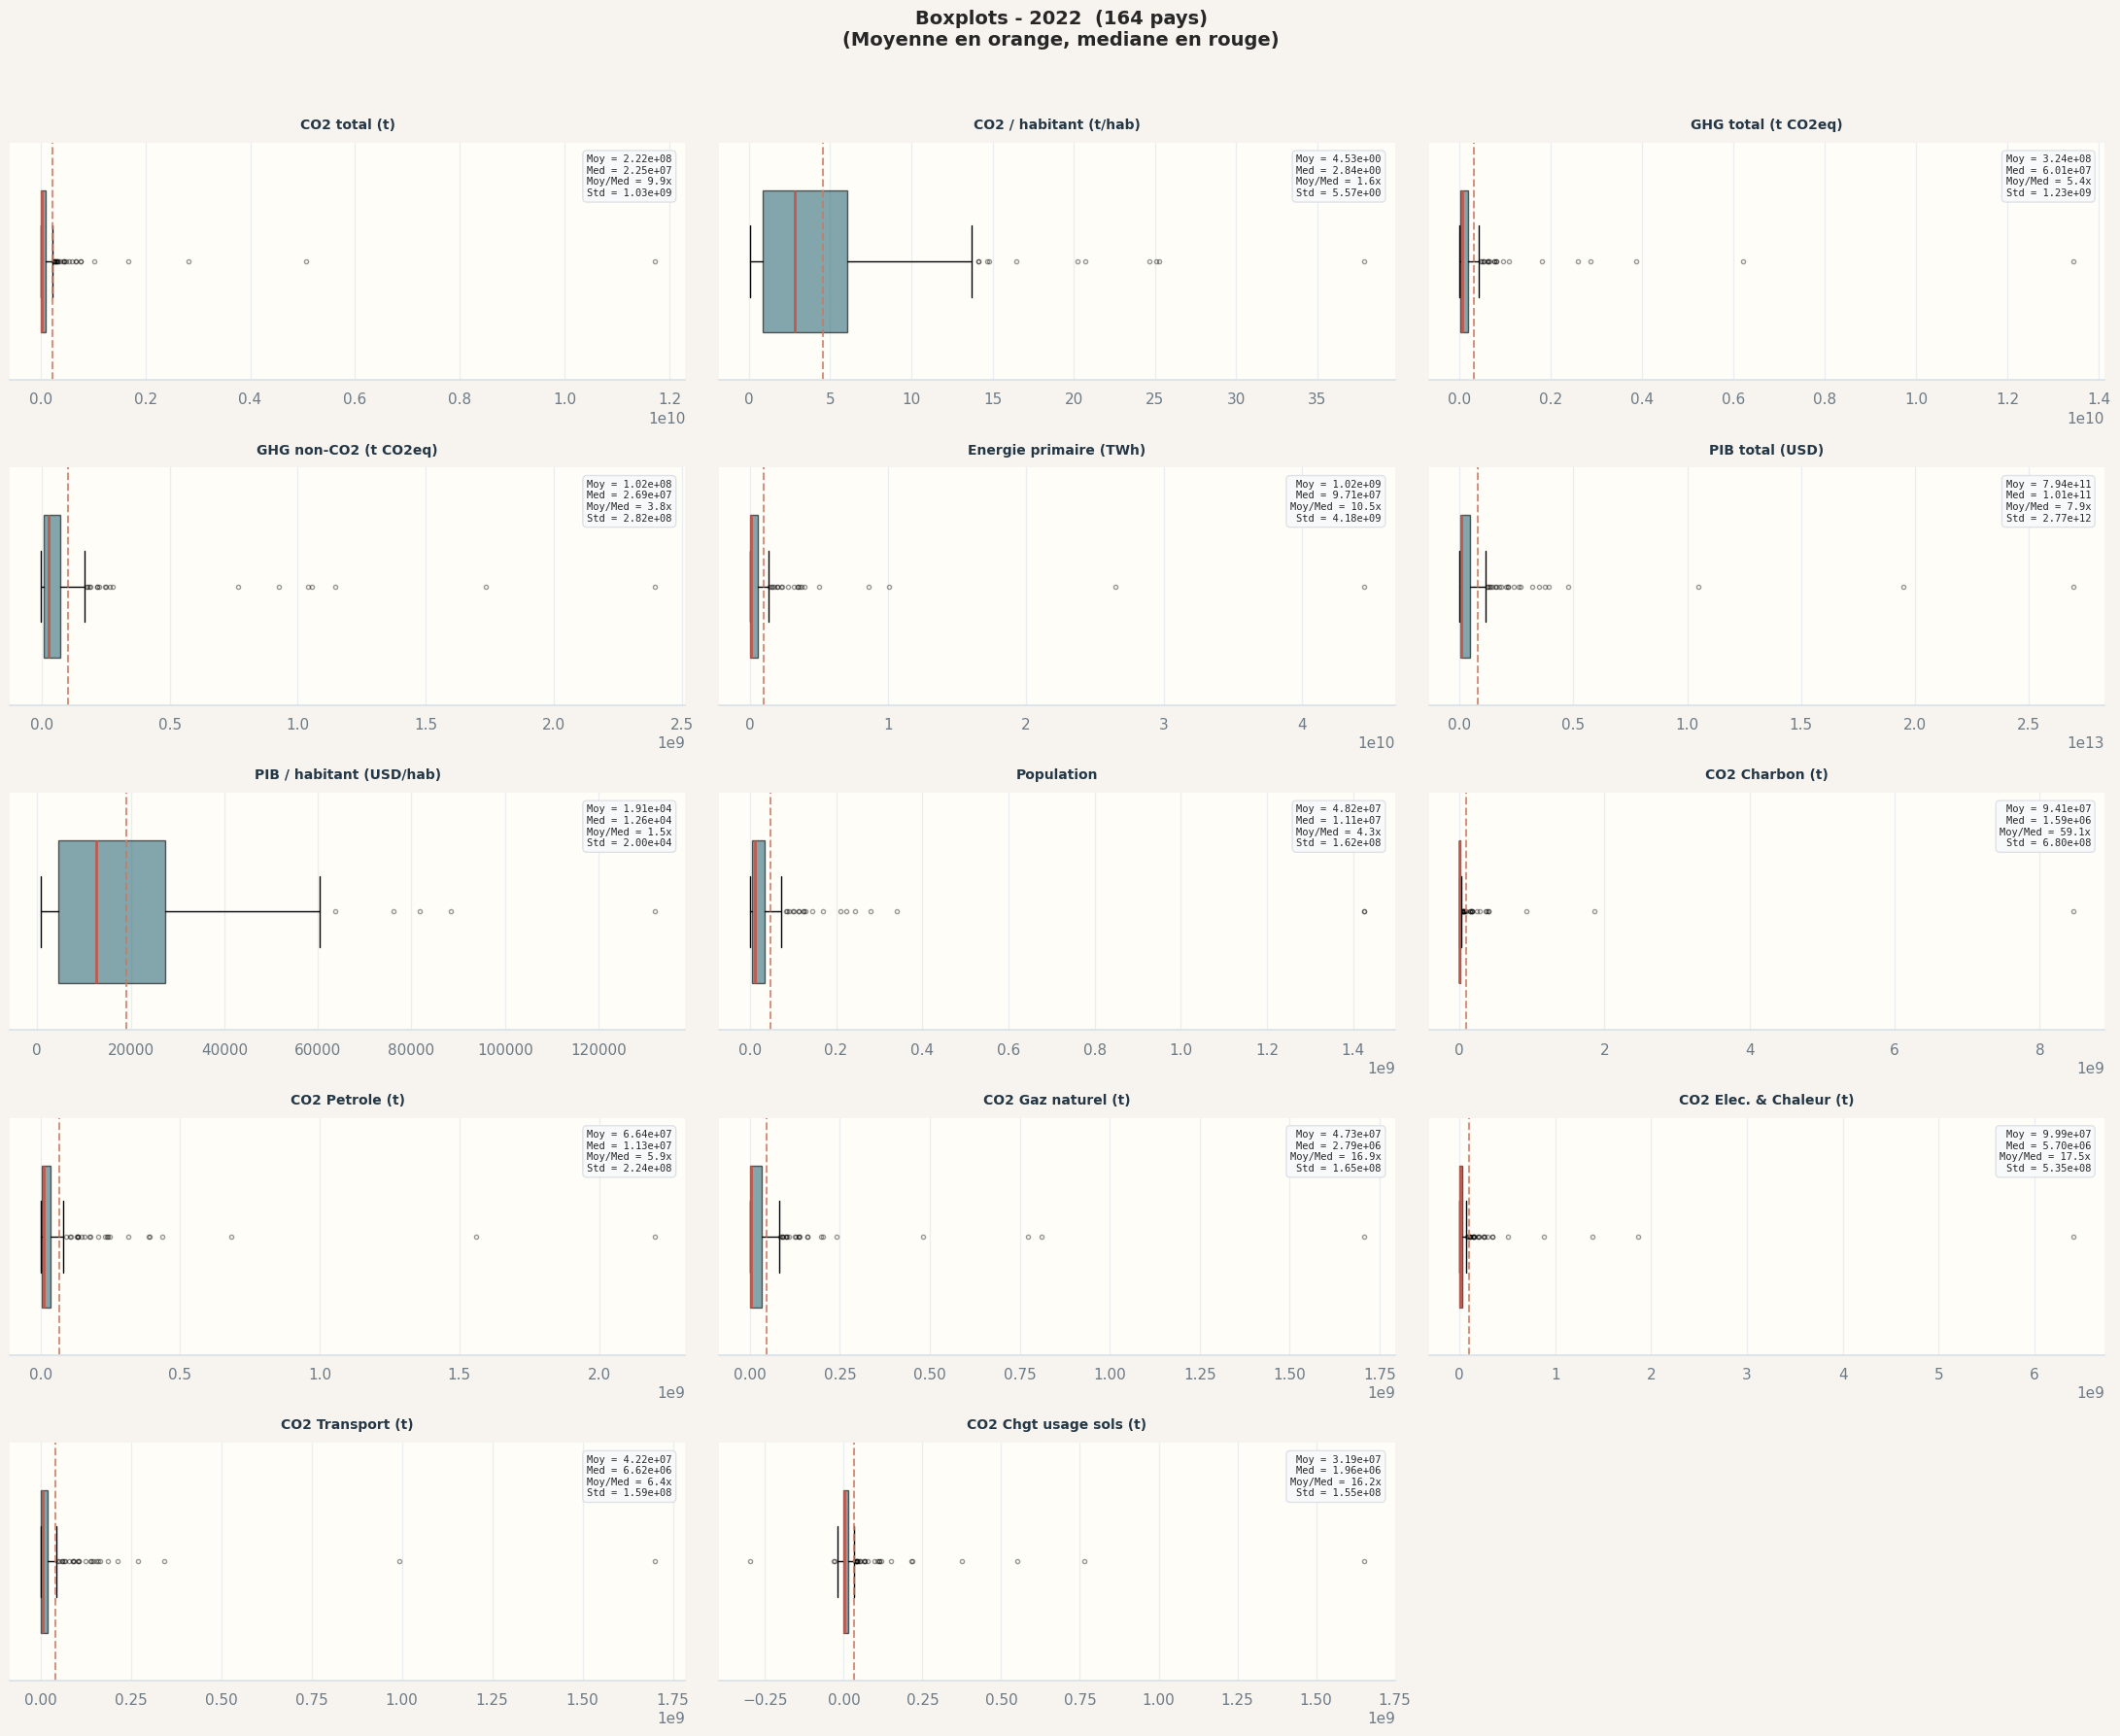

In [6]:
df_stat = df_work[df_work['year'] == latest_year].copy()

vars_stats = [
    ('co2',                       'CO2 total (t)'),
    ('co2_per_capita',            'CO2 / habitant (t/hab)'),
    ('total_ghg',                 'GHG total (t CO2eq)'),
    ('ghg_non_co2',               'GHG non-CO2 (t CO2eq)'),
    ('primary_energy_consumption','Energie primaire (TWh)'),
    ('gdp',                       'PIB total (USD)'),
    ('gdp_per_capita',            'PIB / habitant (USD/hab)'),
    ('population',                'Population'),
    ('CO2_Coal',                  'CO2 Charbon (t)'),
    ('CO2_Oil',                   'CO2 Petrole (t)'),
    ('CO2_Gas',                   'CO2 Gaz naturel (t)'),
    ('CO2_Electricity and heat',  'CO2 Elec. & Chaleur (t)'),
    ('CO2_Transport',             'CO2 Transport (t)'),
    ('CO2_Land-use change',       'CO2 Chgt usage sols (t)'),
]

vars_stats = [(c, l) for c, l in vars_stats if c in df_stat.columns]

ncols = 3
nrows = (len(vars_stats) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, (col, label) in enumerate(vars_stats):
    ax = axes[i]
    s = df_stat[col].dropna()

    bp = ax.boxplot(s, vert=False, widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE['primary'], alpha=0.6),
                    medianprops=dict(color=PALETTE['danger'], linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    # moyenne en orange
    mean_v = s.mean()
    ax.axvline(mean_v, color=PALETTE['secondary'], linestyle='--', linewidth=1.5, alpha=0.8)

    med_v = s.median()
    std_v = s.std()
    ratio = mean_v / med_v if med_v != 0 else float('nan')

    stats_text = (
        f'Moy = {mean_v:.2e}\n'
        f'Med = {med_v:.2e}\n'
        f'Moy/Med = {ratio:.1f}x\n'
        f'Std = {std_v:.2e}'
    )
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#dee2e6'))

    # cadrage : petit padding autour du min/max reel
    pad = (s.max() - s.min()) * 0.05
    ax.set_xlim(s.min() - pad, s.max() + pad)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)

for j in range(len(vars_stats), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Boxplots - {latest_year}  ({df_stat.shape[0]} pays)\n'
             '(Moyenne en orange, mediane en rouge)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interprétation des Boxplots (avec outliers)

Les boxplots confirment la forte asymétrie des distributions déjà observée dans les histogrammes :

- **Variables absolues** (CO2 total, PIB, population, énergie) : les boîtes sont écrasées à gauche, avec de longs whiskers et de nombreux outliers à droite. Le ratio Moy/Med entre 4x et 17x reflète la domination de quelques pays géants (Chine, USA, Inde) qui tirent la moyenne loin de la médiane.

- **Variables per capita** (CO2/hab, PIB/hab) : l'asymétrie est nettement réduite (Moy/Med ≈ 1.5x), ce qui valide le choix de travailler en variables intensives pour la classification - elles neutralisent l'effet taille et rendent les pays comparables.

- **CO2 Charbon** : cas extrême avec Moy/Med ≈ 59x - la majorité des pays n'utilisent presque pas de charbon, mais quelques gros consommateurs (Chine, Inde) créent une queue de distribution massive.

- **CO2 Changement d'usage des sols** : seule variable présentant des valeurs négatives (pays absorbeurs nets grâce à la reforestation), ce qui en fait une variable particulièrement informative.

La présence systématique d'outliers rend la lecture des boîtes difficile sur plusieurs graphiques - les distributions étant compressées à gauche par les valeurs extrêmes. Pour mieux visualiser la structure centrale des données, nous reproduisons les mêmes boxplots en retirant les outliers (méthode IQR ×1.5).


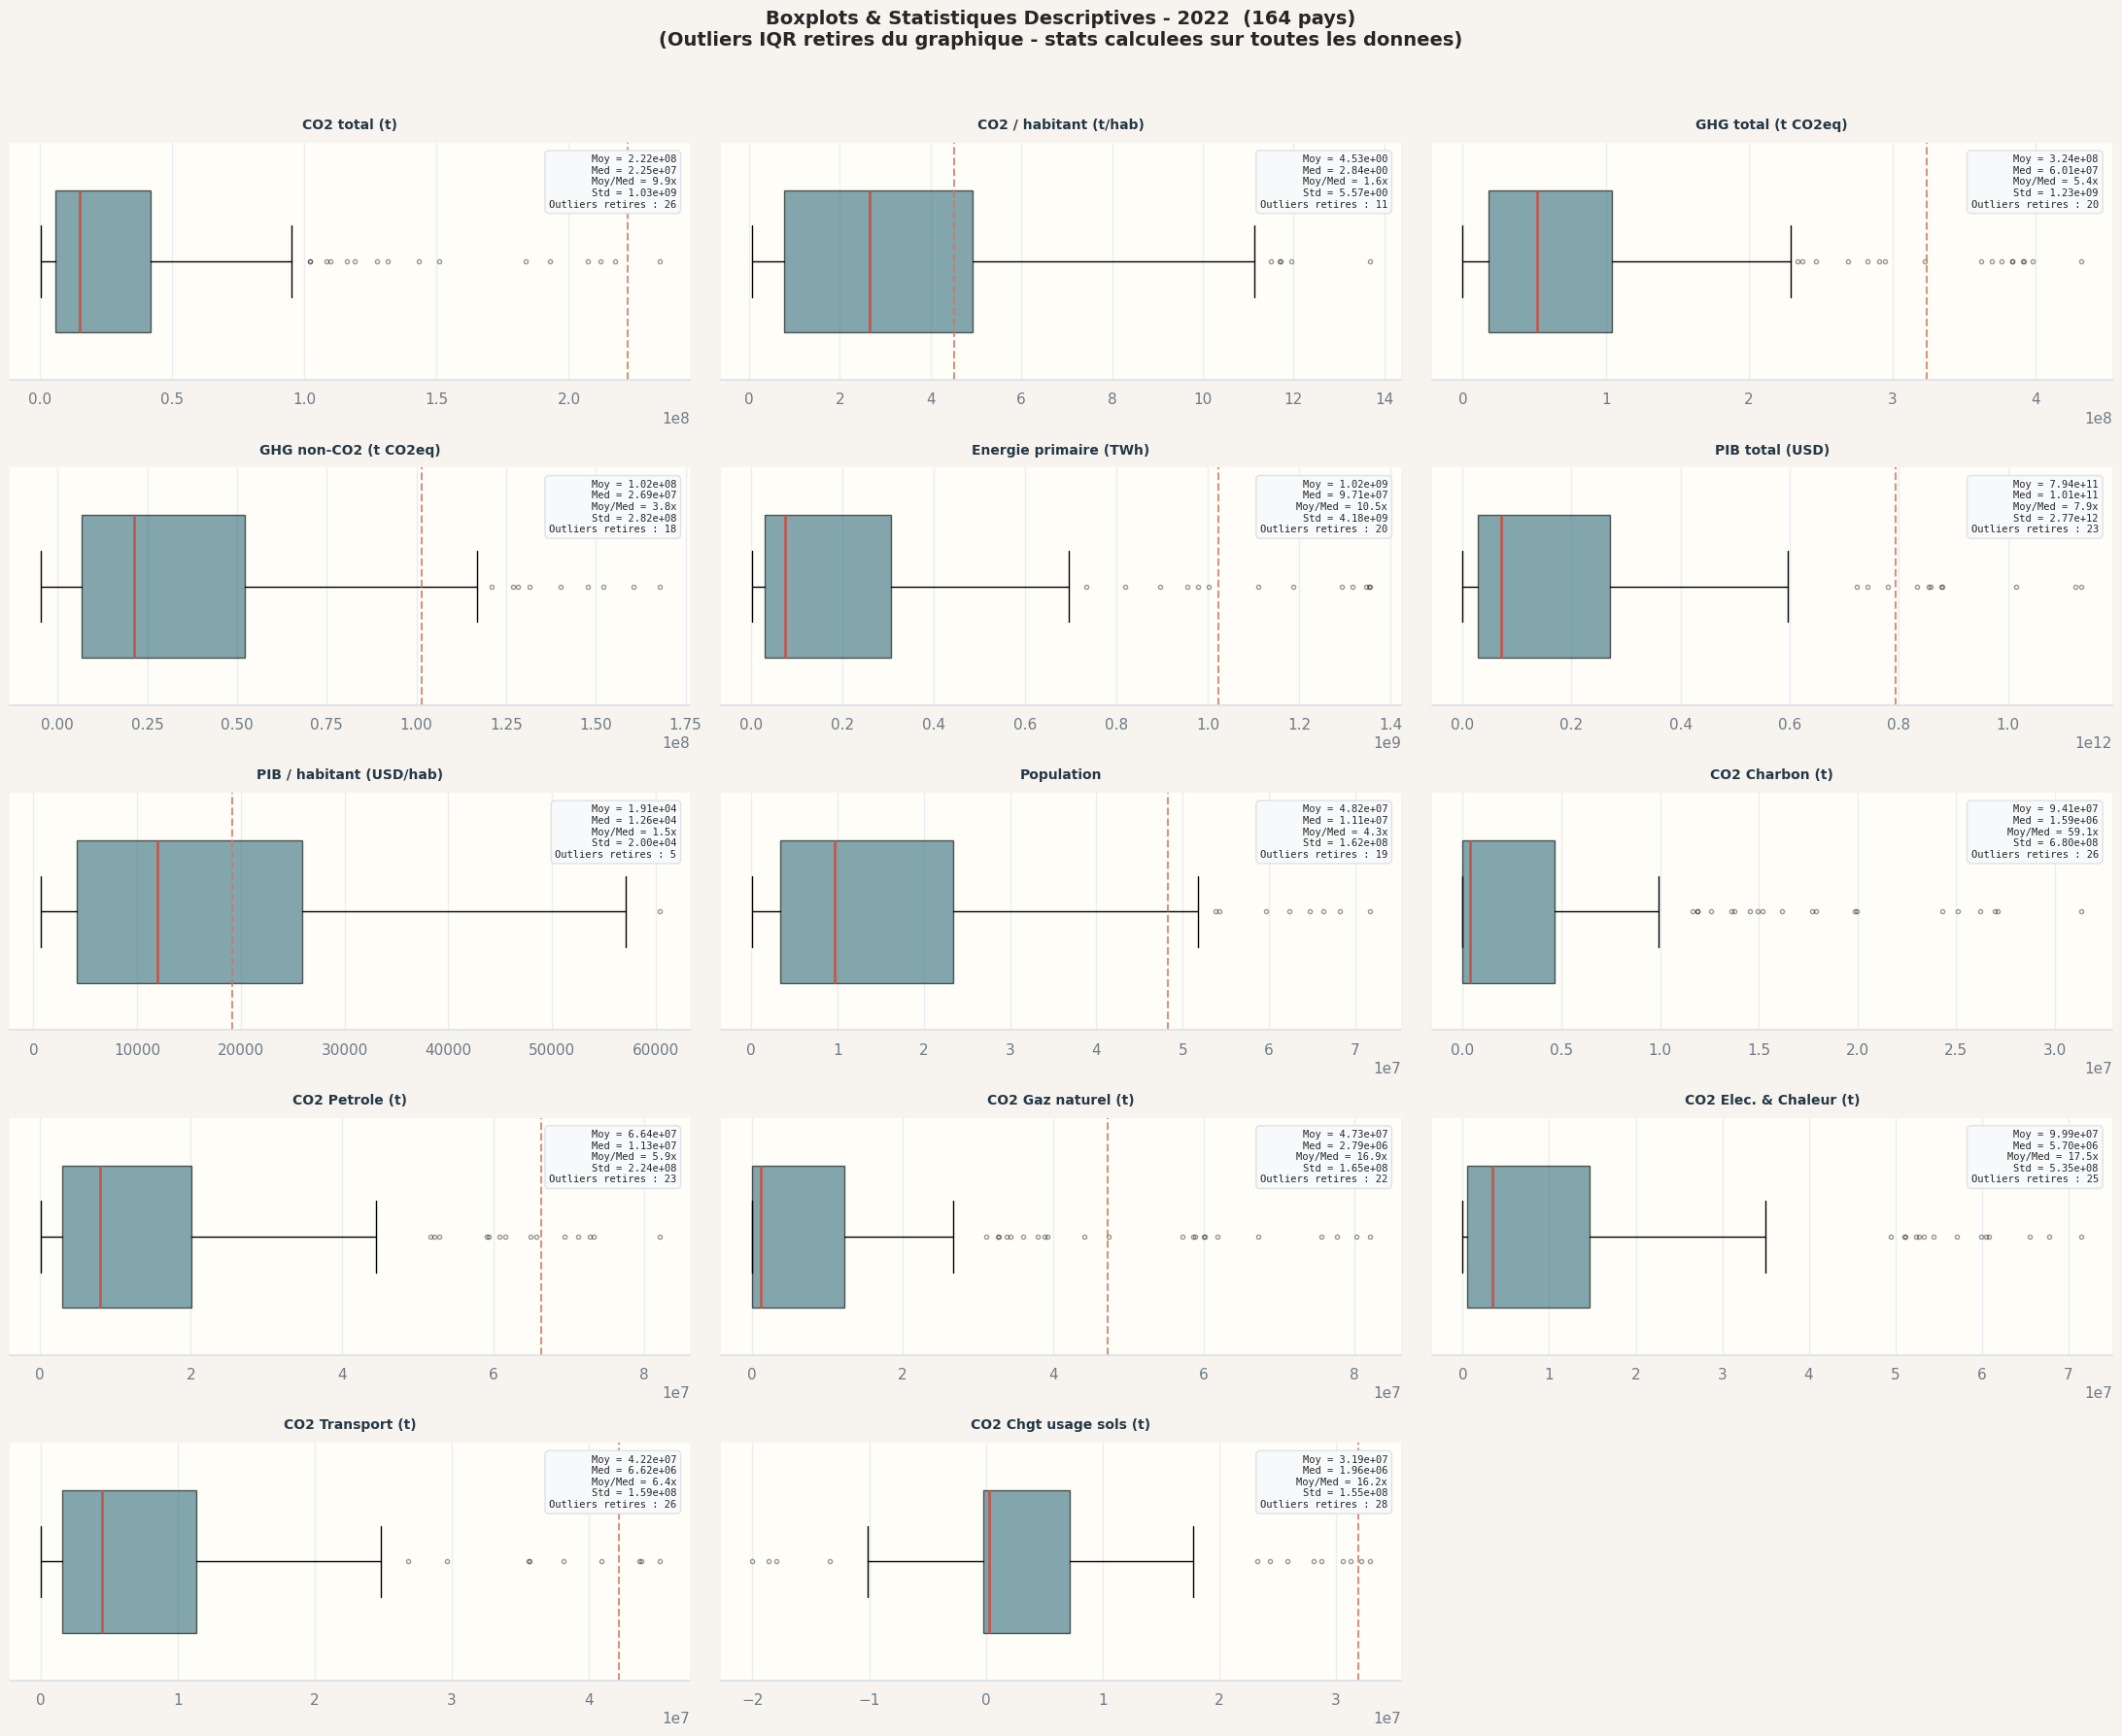

In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, (col, label) in enumerate(vars_stats):
    ax = axes[i]
    s = df_stat[col].dropna()

    # filtrer les outliers via IQR classique
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    s_clean = s[(s >= lower) & (s <= upper)]
    n_out = len(s) - len(s_clean)

    bp = ax.boxplot(s_clean, vert=False, widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE['primary'], alpha=0.6),
                    medianprops=dict(color=PALETTE['danger'], linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    # stats sur les donnees completes (pas filtrées)
    mean_v = s.mean()
    med_v = s.median()
    std_v = s.std()
    ratio = mean_v / med_v if med_v != 0 else float('nan')

    stats_text = (
        f'Moy = {mean_v:.2e}\n'
        f'Med = {med_v:.2e}\n'
        f'Moy/Med = {ratio:.1f}x\n'
        f'Std = {std_v:.2e}\n'
        f'Outliers retires : {n_out}'
    )
    ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#dee2e6'))

    # moyenne en orange seulement si elle tombe dans la plage visible
    xlim = ax.get_xlim()
    if xlim[0] <= mean_v <= xlim[1]:
        ax.axvline(mean_v, color=PALETTE['secondary'], linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)

for j in range(len(vars_stats), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Boxplots & Statistiques Descriptives - {latest_year}  ({df_stat.shape[0]} pays)\n'
             '(Outliers IQR retires du graphique - stats calculees sur toutes les donnees)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interprétation des Boxplots (sans outliers IQR)

En retirant les outliers par la méthode classique IQR ×1.5, la structure centrale des distributions devient lisible :

- **CO2/habitant** : la boîte s'étend de ~1 à ~7 t/hab, avec une médiane autour de 3 t/hab. L'intervalle interquartile montre que la moitié des pays se situe dans une fourchette relativement resserrée, malgré les extrêmes des pays pétroliers. 11 outliers ont été retirés.

- **PIB/habitant** : distribution la plus symétrique du panel (Moy/Med = 1.5x, 5 outliers seulement), confirmant que les inégalités de richesse entre pays sont moins extrêmes que les inégalités d'émissions.

- **Variables sectorielles** (Charbon, Pétrole, Gaz, Électricité, Transport) : entre 20 et 30 outliers retirés à chaque fois, ce qui illustre la concentration sectorielle - une poignée de pays concentre l'essentiel des émissions dans chaque secteur.

- **Population** : 19 outliers retirés, la boîte se resserre autour de pays de taille modeste (< 50M hab), montrant que les pays très peuplés sont l'exception statistique.

> Les statistiques affichées (moyenne, médiane, écart-type) restent calculées sur l'ensemble complet des données, seule la représentation graphique est filtrée pour améliorer la lisibilité.

> _Source : [Interquartile Range Method (IQR)](https://procogia.com/interquartile-range-method-for-reliable-data-analysis/)_


### 3.2 Distributions des Variables Clés (Zoom Q95)

Pour compléter l'analyse des boxplots, nous visualisons ici les distributions sous forme d'histogrammes en zoomant sur les 95% de la population. Ce zoom permet de mieux observer la forme des distributions sans être écrasé par les valeurs extrêmes, tout en conservant la moyenne et la médiane calculées sur l'ensemble des données.


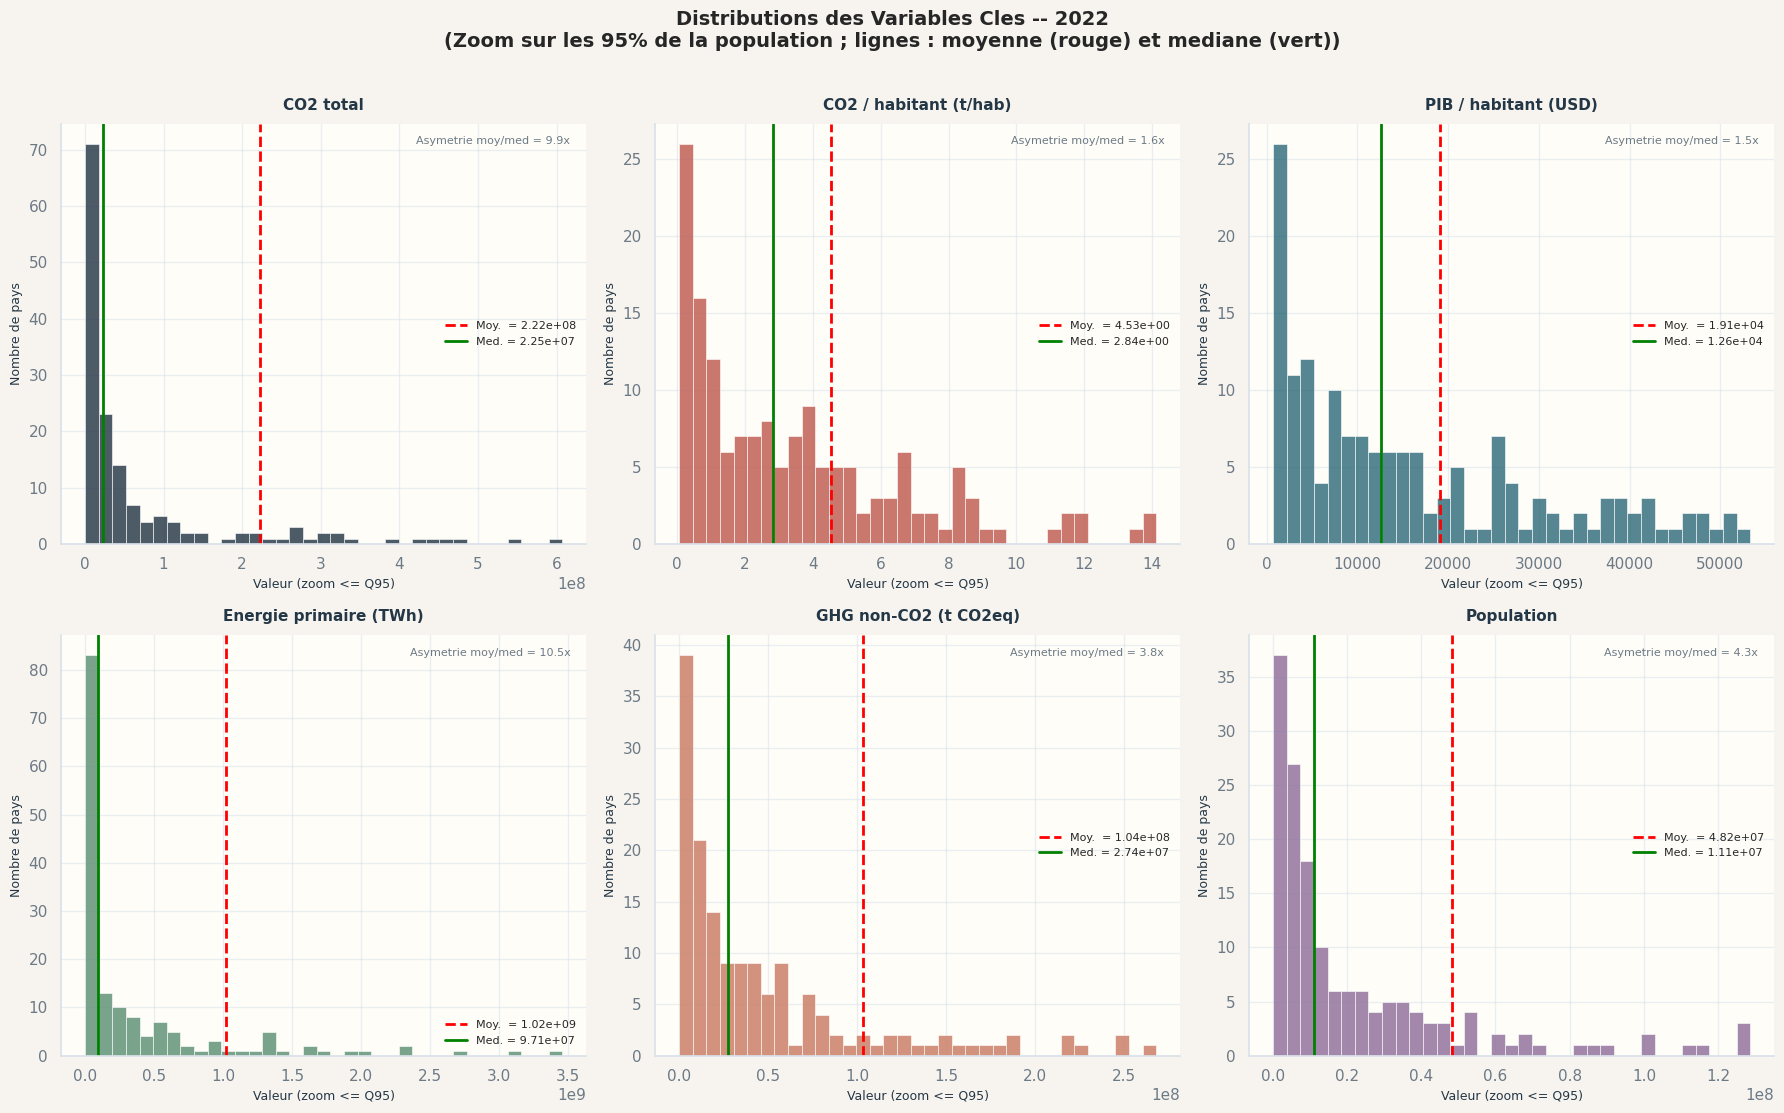

In [8]:
df_hist = df_work[df_work['year'] == latest_year].copy()

vars_hist = [
    ('co2',                        'CO2 total',                  PALETTE['ink']),
    ('co2_per_capita',             'CO2 / habitant (t/hab)',     PALETTE['danger']),
    ('gdp_per_capita',             'PIB / habitant (USD)',       PALETTE['primary']),
    ('primary_energy_consumption', 'Energie primaire (TWh)',     PALETTE['success']),
    ('ghg_non_co2',                'GHG non-CO2 (t CO2eq)',      PALETTE['secondary']),
    ('population',                 'Population',                 PALETTE['cluster_4']),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f'Distributions des Variables Cles -- {latest_year}\n'
    '(Zoom sur les 95% de la population ; lignes : moyenne (rouge) et mediane (vert))',
    fontsize=14, fontweight='bold', y=1.01
)

for ax, (col, label, color) in zip(axes.flatten(), vars_hist):
    s = df_hist[col].dropna()
    s = s[s > 0]
    q95    = s.quantile(0.95)
    s_zoom = s[s <= q95]

    ax.hist(s_zoom, bins=35, color=color, alpha=0.82, edgecolor='white', linewidth=0.5)

    mean_v, med_v = s.mean(), s.median()
    ratio = mean_v / med_v if med_v > 0 else float('nan')

    if mean_v <= q95:
        ax.axvline(mean_v, color='red',   linestyle='--', linewidth=2,
                   label=f'Moy.  = {mean_v:.2e}')
    if med_v <= q95:
        ax.axvline(med_v,  color='green', linestyle='-',  linewidth=2,
                   label=f'Med. = {med_v:.2e}')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur (zoom <= Q95)', fontsize=9)
    ax.set_ylabel('Nombre de pays', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.annotate(f'Asymetrie moy/med = {ratio:.1f}x',
                xy=(0.97, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8, color=PALETTE['muted'])

plt.tight_layout()
plt.show()

Les histogrammes confirment et affinent les observations des boxplots. Toutes les variables absolues (CO2 total, énergie, population) présentent une distribution fortement concentrée à gauche avec une longue queue droite - la majorité des pays émettent peu, consomment peu et sont de taille modeste. L'écart entre la moyenne (rouge) et la médiane (vert) illustre visuellement l'asymétrie : plus ces deux lignes sont éloignées, plus la distribution est tirée par quelques pays extrêmes.

Les variables `per capita` se distinguent nettement avec des distributions plus étalées et un ratio moy/méd de seulement 1.5x - signe que la normalisation par la population réduit considérablement l'effet de concentration et rend les pays plus comparables entre eux. Le GHG non-CO2 (moy/méd = 3.8x) occupe une position intermédiaire, reflétant le fait que le méthane agricole est plus uniformément réparti que les émissions fossiles.


### 3.3 Évolution de la Répartition des Émissions (2013 vs 2022)

Afin de compléter la vue statique des donuts, nous comparons ici les parts relatives de chaque combustible et secteur entre 2013 et 2022 via un slope chart. La pente de chaque ligne indique le sens et l'ampleur du changement sur la décennie.


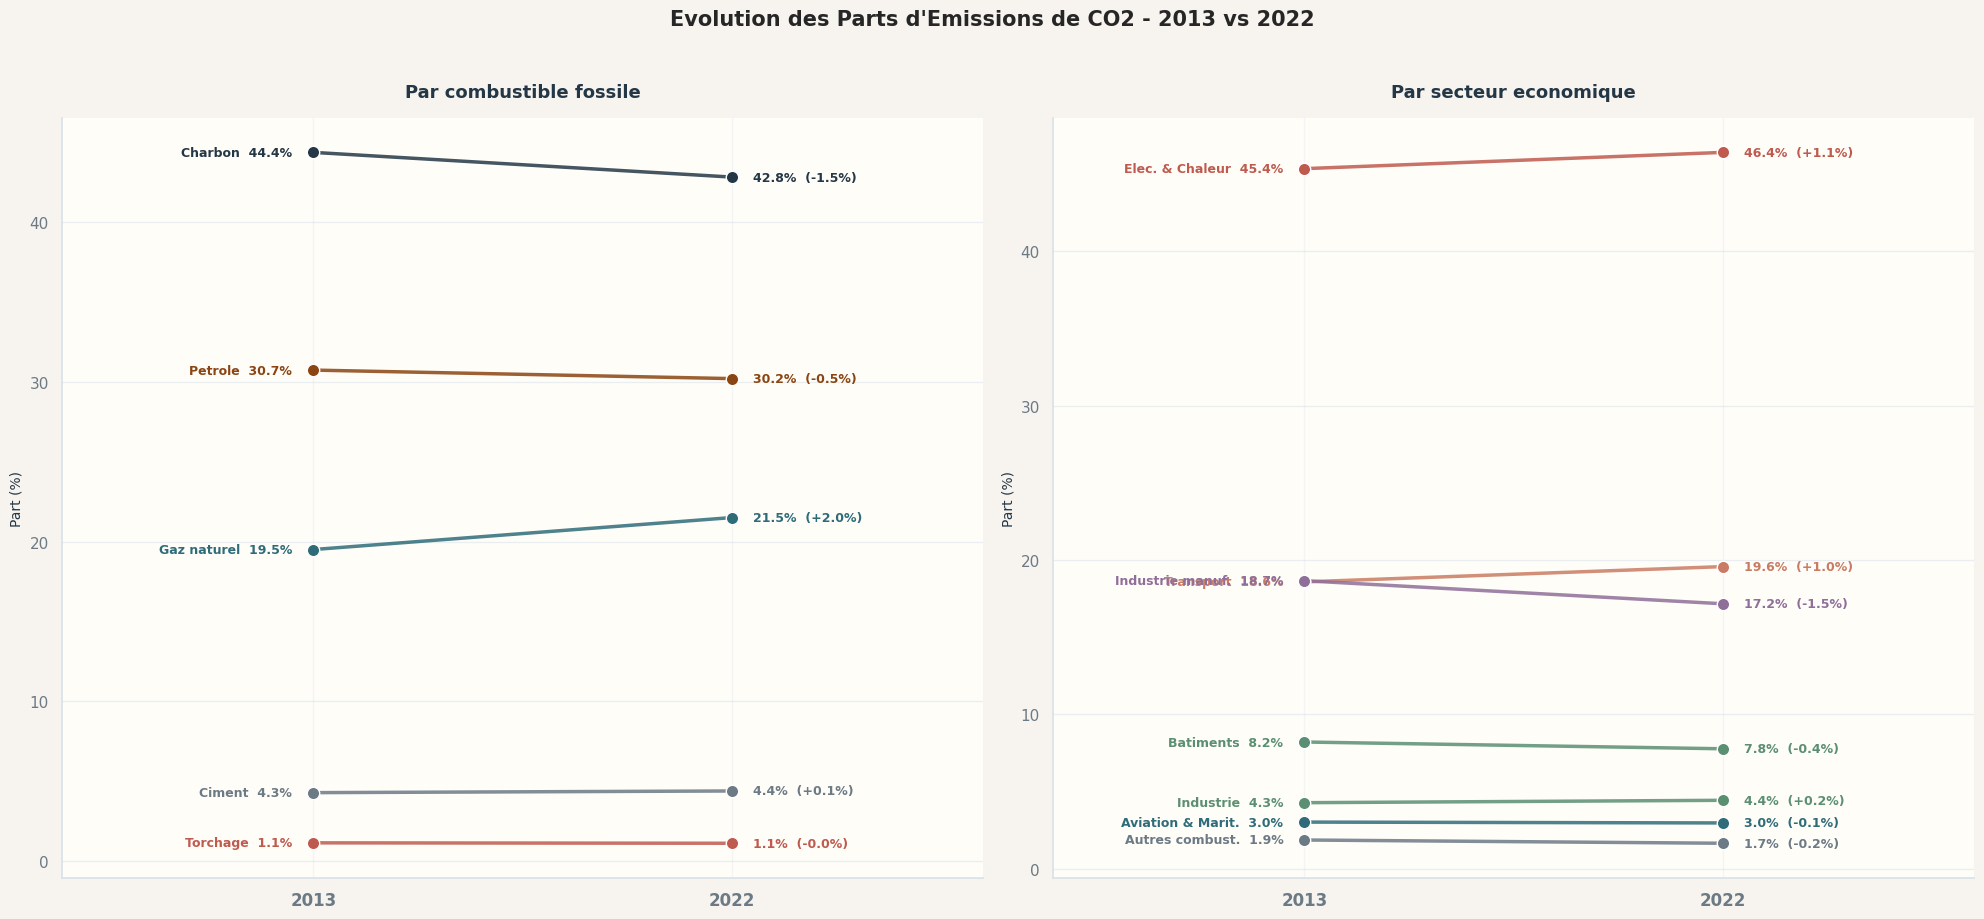

In [9]:
df_2013 = df_work[df_work['year'] == first_year].copy()
df_2022 = df_work[df_work['year'] == latest_year].copy()

fuel_cols   = ['CO2_Coal', 'CO2_Oil', 'CO2_Gas', 'CO2_Cement', 'CO2_Flaring']
fuel_labels = ['Charbon', 'Petrole', 'Gaz naturel', 'Ciment', 'Torchage']
fuel_colors = [PALETTE['ink'], '#8B4513', PALETTE['primary'], PALETTE['muted'], PALETTE['danger']]

sect_cols   = ['CO2_Electricity and heat', 'CO2_Transport',
               'CO2_Manufacturing and construction', 'CO2_Buildings',
               'CO2_Industry', 'CO2_Aviation and shipping','CO2_Other fuel combustion']
sect_labels = ['Elec. & Chaleur', 'Transport', 'Industrie manuf.',
               'Batiments', 'Industrie', 'Aviation & Marit.',
               'Autres combust.']
sect_colors = [PALETTE['danger'], PALETTE['secondary'], PALETTE['cluster_4'], PALETTE['success'],
               PALETTE['success'], PALETTE['primary'], PALETTE['muted']]

def calc_pcts(df, cols):
    vals = np.array([df[c].fillna(0).sum() for c in cols])
    return vals / vals.sum() * 100

fuel_pct_13 = calc_pcts(df_2013, fuel_cols)
fuel_pct_22 = calc_pcts(df_2022, fuel_cols)
sect_pct_13 = calc_pcts(df_2013, sect_cols)
sect_pct_22 = calc_pcts(df_2022, sect_cols)

def draw_slope(ax, pct_13, pct_22, labels, colors, title):
    y_left  = list(range(len(labels)))
    y_right = list(range(len(labels)))

    for i in range(len(labels)):
        ax.plot([0, 1], [pct_13[i], pct_22[i]], color=colors[i],
                linewidth=2.5, alpha=0.85, zorder=3)
        ax.scatter([0], [pct_13[i]], color=colors[i], s=80, zorder=4, edgecolors='white')
        ax.scatter([1], [pct_22[i]], color=colors[i], s=80, zorder=4, edgecolors='white')

        # labels a gauche (2013)
        ax.text(-0.05, pct_13[i], f'{labels[i]}  {pct_13[i]:.1f}%',
                ha='right', va='center', fontsize=9, color=colors[i], fontweight='bold')

        # labels a droite (2022)
        diff = pct_22[i] - pct_13[i]
        sign = '+' if diff > 0 else ''
        ax.text(1.05, pct_22[i], f'{pct_22[i]:.1f}%  ({sign}{diff:.1f}%)',
                ha='left', va='center', fontsize=9, color=colors[i], fontweight='bold')

    ax.set_xlim(-0.6, 1.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([str(first_year), str(latest_year)], fontsize=12, fontweight='bold')
    ax.set_ylabel('Part (%)', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle(f'Evolution des Parts d\'Emissions de CO2 - {first_year} vs {latest_year}',
             fontsize=15, fontweight='bold', y=1.02)

draw_slope(ax1, fuel_pct_13, fuel_pct_22, fuel_labels, fuel_colors, 'Par combustible fossile')
draw_slope(ax2, sect_pct_13, sect_pct_22, sect_labels, sect_colors, 'Par secteur economique')

plt.tight_layout()
plt.show()

Le constat principal est l'inertie du système énergétique mondial : en dix ans, aucune part ne bouge de plus de 2 points. Le gaz naturel grignote du terrain au charbon côté combustibles, traduisant une transition lente vers des fossiles moins carbonés. Côté secteurs, l'électricité et chaleur renforce sa domination $\Rightarrow$ décarbonation de la production électrique reste le levier prioritaire pour réduire les émissions globales.


## 4. Analyse en Dimension 2


### 4.1 Matrices de Corrélation et Gestion de la Multicolinéarité

Avant d'étudier les relations entre variables, il faut traiter un problème fondamental : la **multicolinéarité**. Les variables brutes (CO2_Coal, CO2_Oil, CO2_Transport, etc.) sont des composantes additives du CO2 total - elles partagent mécaniquement la même variance de taille. Les corréler entre elles revient à mesurer à quel point "les gros pays sont gros", ce qui n'apprend rien.

**Pourquoi la log-transformation ?** La corrélation de Pearson mesure des relations linéaires, or nos variables brutes suivent des distributions exponentielles (quelques géants, beaucoup de petits pays). Le logarithme linéarise ces relations multiplicatives et rend Pearson pertinent. On l'applique aux variables de base (CO2, PIB, énergie) mais pas aux parts qui sont déjà bornées entre 0 et 1.

**Comment réduire la multicolinéarité ?** On transforme les variables brutes en **variables intensives** : des parts (part du charbon dans le mix, part du transport dans les émissions) et des ratios per capita (CO2/hab, PIB/hab). Ces variables neutralisent l'effet taille et captent la _structure_ des émissions plutôt que leur _volume_. La première heatmap illustre le problème (corrélations > 0.8 partout), la seconde montre le résultat après transformation.


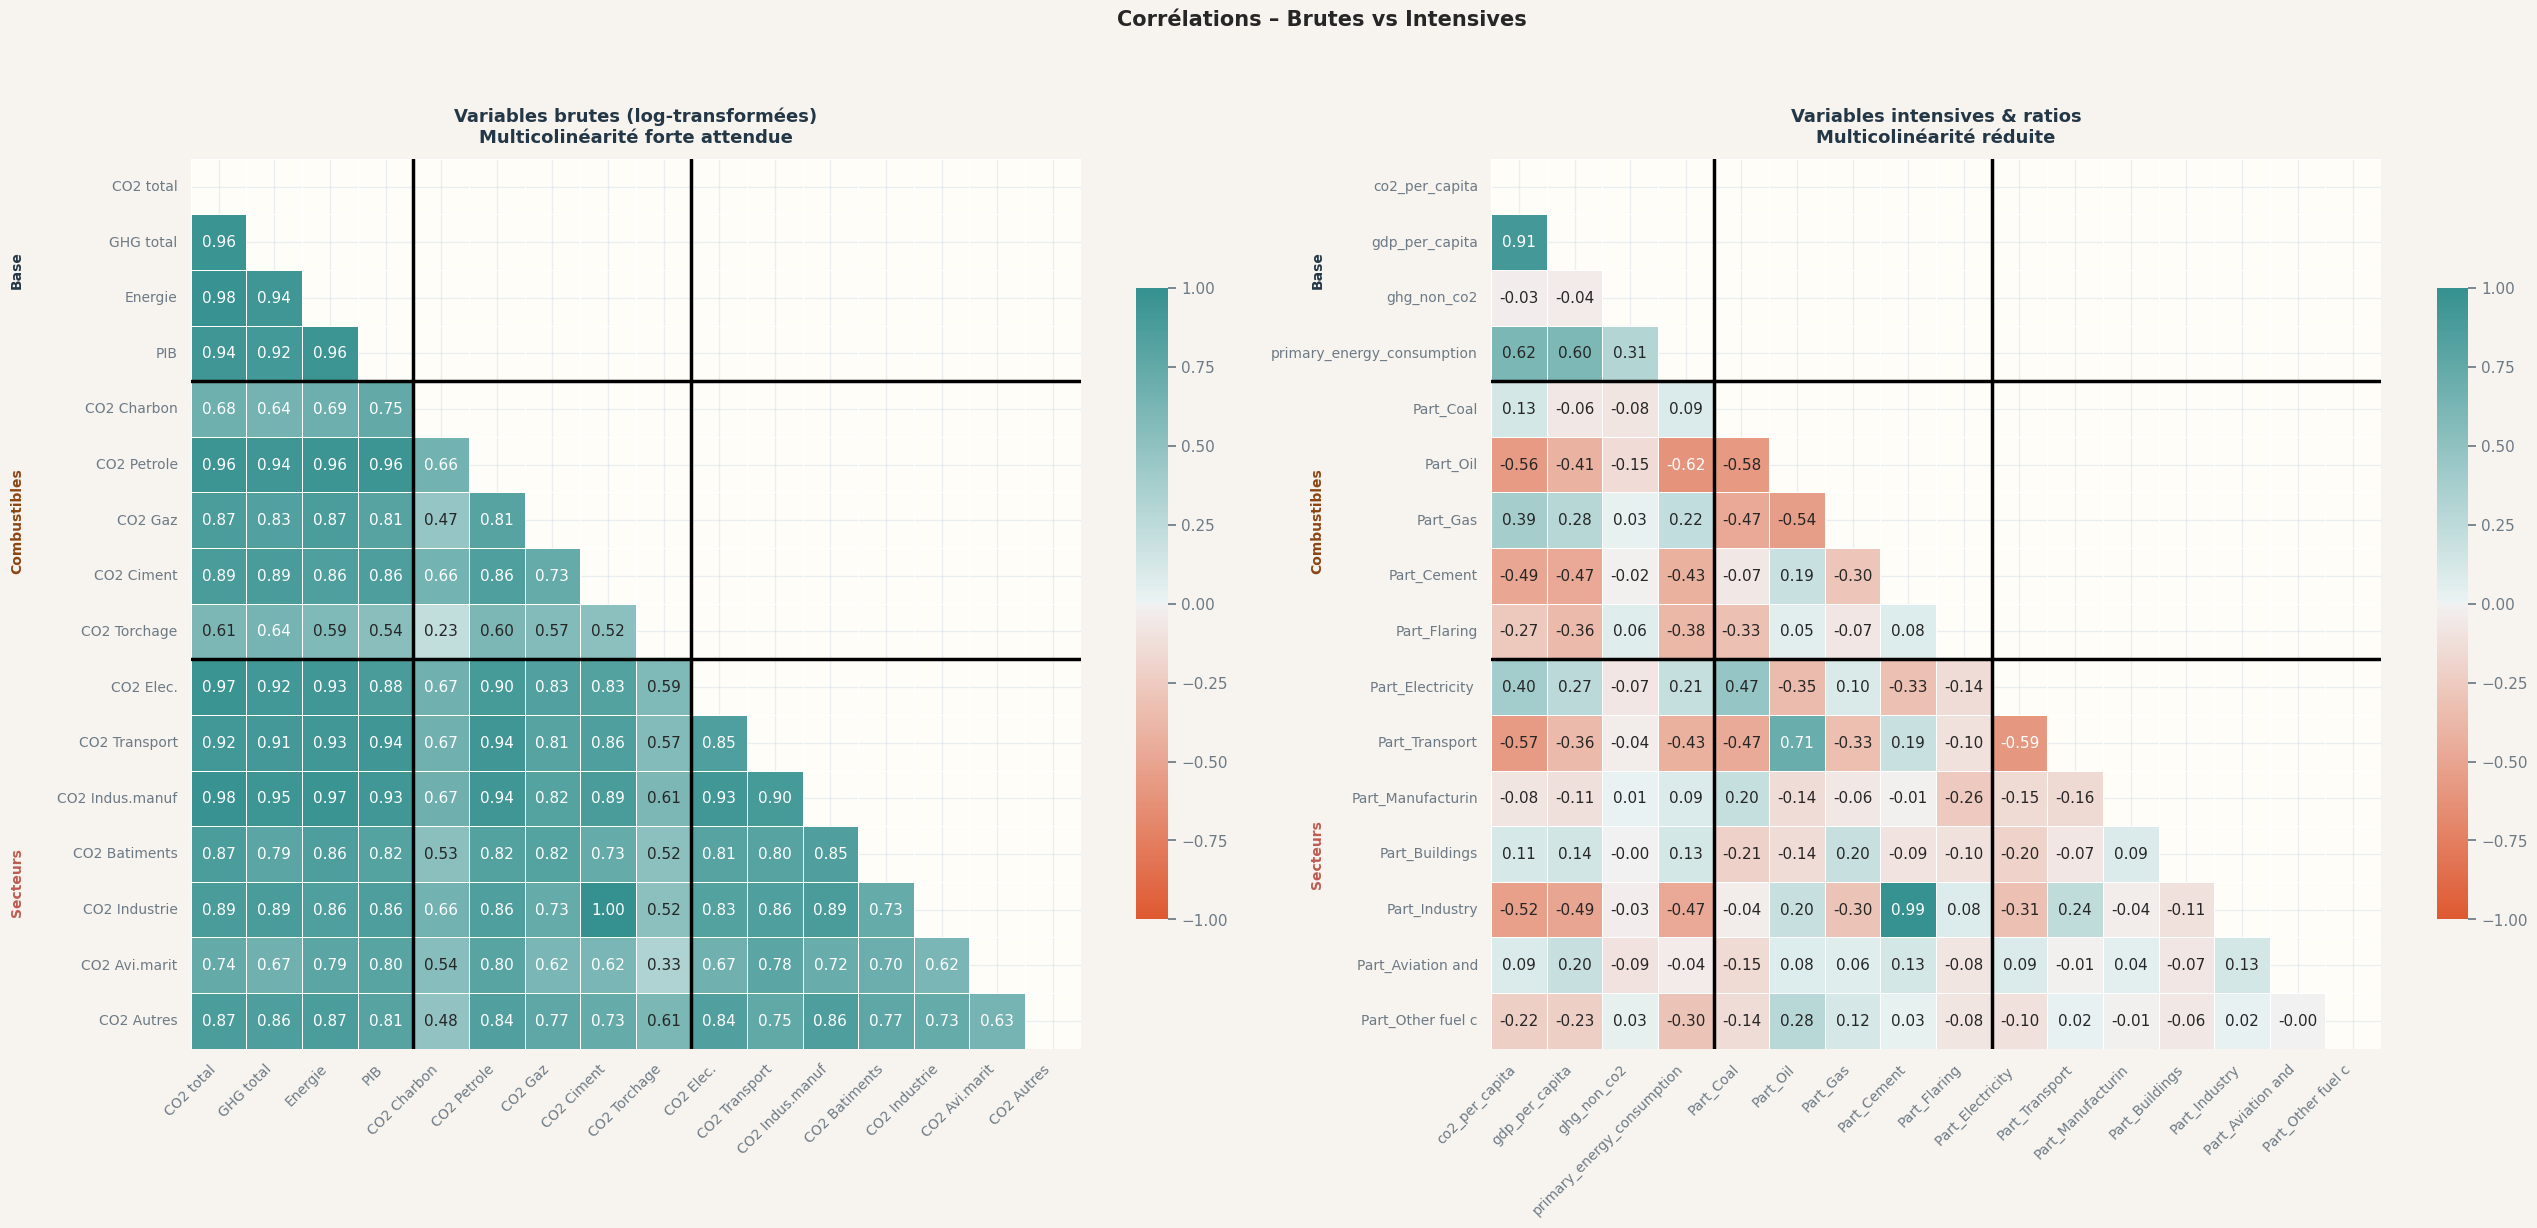

Corrélations avec CO2/hab (variables intensives, triées par |r|) :
  *** gdp_per_capita                  r = +0.907
  *** primary_energy_consumption      r = +0.615
  *** Part_Transport                  r = -0.565
  *** Part_Oil                        r = -0.564
  *** Part_Industry                   r = -0.524
  *** Part_Cement                     r = -0.487
  *** Part_Electricity                r = +0.397
  *** Part_Gas                        r = +0.387
      Part_Flaring                    r = -0.271
      Part_Other fuel c               r = -0.224
      Part_Coal                       r = +0.131
      Part_Buildings                  r = +0.112
      Part_Aviation and               r = +0.093
      Part_Manufacturin               r = -0.079
      ghg_non_co2                     r = -0.030


In [10]:
hm_kw = dict(annot=True, fmt='.2f', cmap=HEATMAP_CMAP, center=0, vmin=-1, vmax=1,
             square=True, linewidths=0.5, annot_kws={'size': 11},
             cbar_kws={'shrink': 0.6})

def draw_separators(ax, n_base, n_fuel, n_sect):
    for pos in [n_base, n_base + n_fuel]:
        ax.axhline(y=pos, color='black', linewidth=2.5)
        ax.axvline(x=pos, color='black', linewidth=2.5)

    labels = [
        (n_base / 2,                   'Base',         PALETTE['ink']),
        (n_base + n_fuel / 2,          'Combustibles', '#8B4513'),
        (n_base + n_fuel + n_sect / 2, 'Secteurs',     PALETTE['danger']),
    ]
    for y, text, color in labels:
        ax.text(-3, y, text, ha='right', va='center', fontsize=10,
                fontweight='bold', color=color, rotation=90)

# deux heatmaps côte à côte
fig, axes = plt.subplots(1, 2, figsize=(26, 12))


# heatmap brute
all_raw = ['co2', 'total_ghg', 'primary_energy_consumption', 'gdp'] + \
          ['CO2_Coal', 'CO2_Oil', 'CO2_Gas', 'CO2_Cement', 'CO2_Flaring'] + \
          ['CO2_Electricity and heat', 'CO2_Transport',
           'CO2_Manufacturing and construction', 'CO2_Buildings',
           'CO2_Industry', 'CO2_Aviation and shipping',
           'CO2_Other fuel combustion']

raw_labels = {
    'co2': 'CO2 total', 'total_ghg': 'GHG total',
    'primary_energy_consumption': 'Energie', 'gdp': 'PIB',
    'CO2_Coal': 'CO2 Charbon', 'CO2_Oil': 'CO2 Petrole',
    'CO2_Gas': 'CO2 Gaz', 'CO2_Cement': 'CO2 Ciment',
    'CO2_Flaring': 'CO2 Torchage',
    'CO2_Electricity and heat': 'CO2 Elec.',
    'CO2_Transport': 'CO2 Transport',
    'CO2_Manufacturing and construction': 'CO2 Indus.manuf',
    'CO2_Buildings': 'CO2 Batiments', 'CO2_Industry': 'CO2 Industrie',
    'CO2_Aviation and shipping': 'CO2 Avi.marit',
    'CO2_Other fuel combustion': 'CO2 Autres',
}

df_r = df_stat[all_raw].rename(columns=raw_labels)
df_r = df_r[(df_r > 0).all(axis=1)]
corr_raw = np.log10(df_r).corr()

mask_raw = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(corr_raw, mask=mask_raw, ax=axes[0], **hm_kw)
draw_separators(axes[0], 4, 5, 8)
axes[0].set_title(
    'Variables brutes (log-transformées)\nMulticolinéarité forte attendue',
    fontsize=13, fontweight='bold', pad=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(),
                         rotation=0, fontsize=10)


# heatmap intensive
for col in ['CO2_Coal', 'CO2_Oil', 'CO2_Gas', 'CO2_Cement', 'CO2_Flaring']:
    df_stat[f'Part_{col.split("_", 1)[1]}'] = df_stat[col] / df_stat['co2'].clip(lower=1)

for col in ['CO2_Electricity and heat', 'CO2_Transport',
            'CO2_Manufacturing and construction', 'CO2_Buildings',
            'CO2_Industry', 'CO2_Aviation and shipping',
            'CO2_Other fuel combustion']:
    short = col.replace('CO2_', '')
    df_stat[f'Part_{short[:12]}'] = df_stat[col] / df_stat['co2'].clip(lower=1)

base_int = ['co2_per_capita', 'gdp_per_capita', 'ghg_non_co2',
            'primary_energy_consumption']
fuel_int = [c for c in df_stat.columns if c.startswith('Part_') and c.split('_')[1] in
            ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring']]
sect_int = [c for c in df_stat.columns if c.startswith('Part_') and c not in fuel_int]

all_int = base_int + fuel_int + sect_int
df_i = df_stat[all_int].copy().replace(0, np.nan)
for v in base_int:
    df_i[v] = np.log10(df_i[v].clip(lower=1e-9))
corr_int = df_i.corr()

# on masque la moitié supérieure pour éviter la redondance visuelle
mask_int = np.triu(np.ones_like(corr_int, dtype=bool))
sns.heatmap(corr_int, mask=mask_int, ax=axes[1], **hm_kw)
draw_separators(axes[1], len(base_int), len(fuel_int), len(sect_int))
axes[1].set_title(
    'Variables intensives & ratios\nMulticolinéarité réduite',
    fontsize=13, fontweight='bold', pad=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(),
                         rotation=0, fontsize=10)

fig.suptitle('Corrélations – Brutes vs Intensives',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

# résumé
print("Corrélations avec CO2/hab (variables intensives, triées par |r|) :")
co2_corr = corr_int['co2_per_capita'].drop('co2_per_capita').sort_values(key=abs, ascending=False)
for var, val in co2_corr.items():
    flag = "***" if abs(val) > 0.3 else "   "
    print(f"  {flag} {var:<30s}  r = {val:+.3f}")

### Interprétation

**Heatmap brute :** Comme attendu, la matrice est quasi uniformément verte - des corrélations supérieures à 0.7 partout. CO2 total, énergie, PIB, et toutes les composantes sectorielles mesurent essentiellement la même chose : la taille du pays. Utiliser ces variables ensemble dans une régression ou une classification serait une erreur méthodologique.

**Heatmap intensive :** Le paysage change radicalement. Les corrélations deviennent nuancées et interprétables :

- **CO2/hab × PIB/hab (r = 0.91)** : la relation la plus forte - les pays riches émettent plus par tête, mais c'est la seule corrélation élevée du panel, ce qui confirme que les autres variables apportent de l'information indépendante.
- **Part_Oil × Part_Transport (r = 0.71)** : lien logique, le transport est quasi exclusivement alimenté par le pétrole.
- **Part_Oil × CO2/hab (r = −0.56)** et **Part_Transport × CO2/hab (r = −0.57)** : les pays à forte intensité carbone ne sont pas ceux qui dépendent du pétrole/transport, mais ceux qui brûlent du charbon pour l'électricité.
- **GHG_non_CO2** est décorrélé de presque tout (r ≈ 0) - le méthane et le N2O dépendent de l'agriculture, pas du système énergétique fossile. Cela confirme son intérêt comme dimension indépendante.

La transformation en variables intensives a bien rempli son rôle : on passe d'une matrice dominée par un seul facteur (la taille) à une structure multidimensionnelle exploitable pour la régression et la classification en Phase 2.


### 4.2 Relations Bivariées Clés

Pour aller au-delà des coefficients de corrélation, nous visualisons trois paires de variables choisies pour leur intérêt analytique : une corrélation forte, une modérée, et une faible. La taille et la couleur des points reflètent le CO2 total du pays.


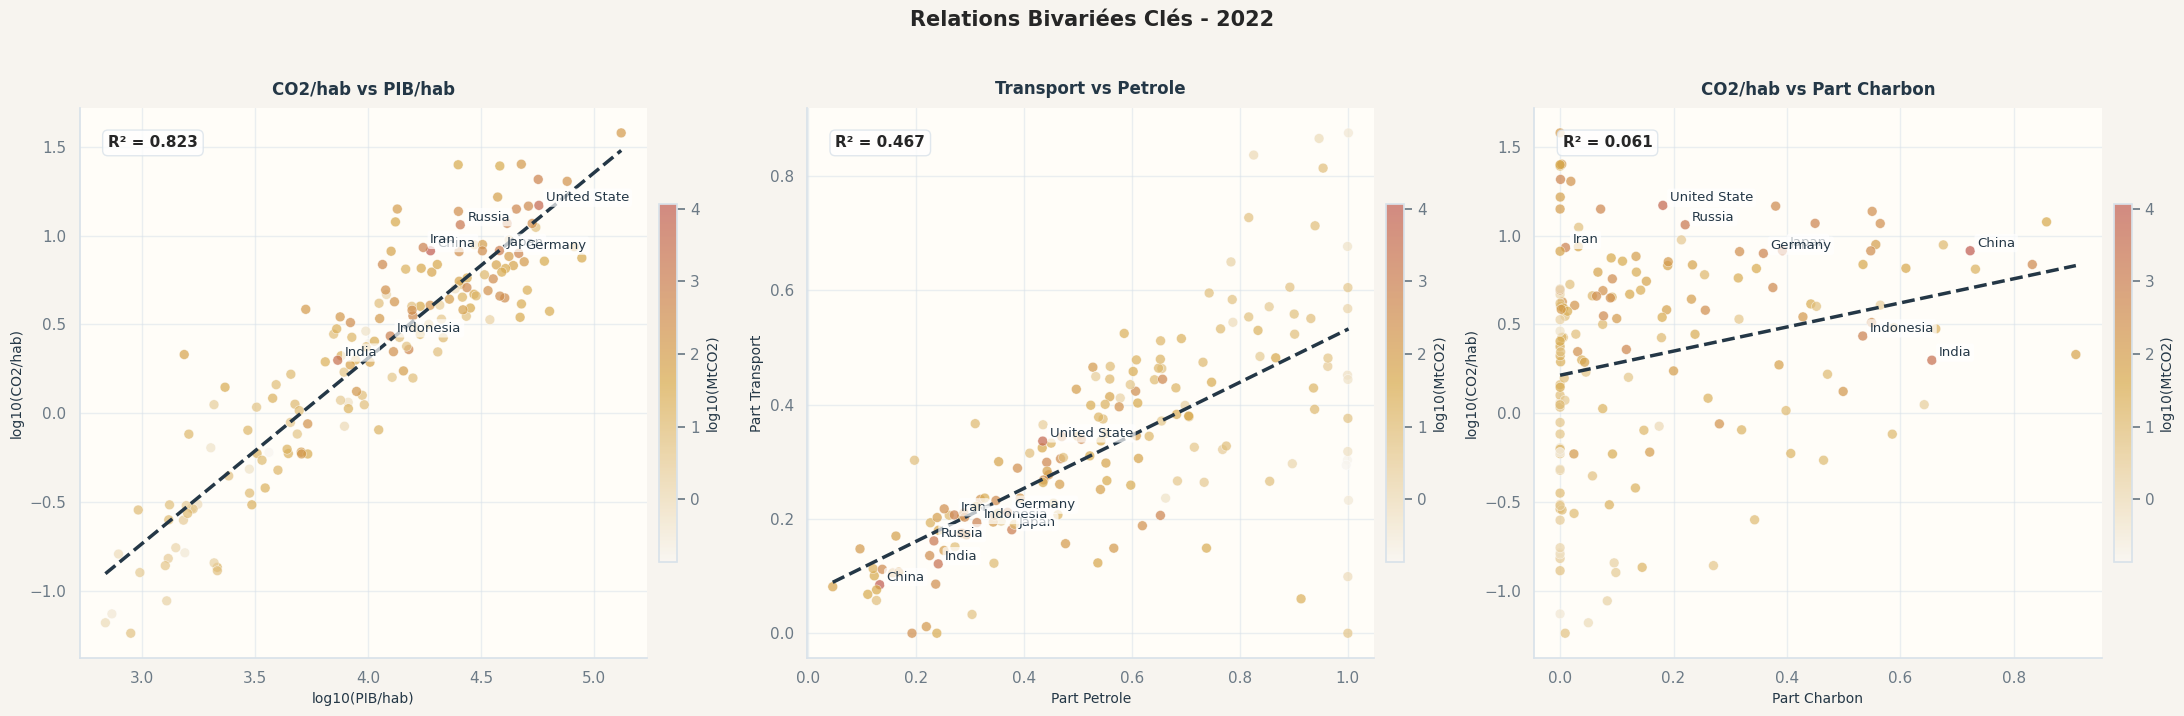

In [11]:
df_sc = df_stat[['country', 'co2_per_capita', 'gdp_per_capita', 'co2']].copy()
df_sc['Part_Coal'] = df_stat['CO2_Coal'] / df_stat['co2'].clip(lower=1)
df_sc['Part_Oil']  = df_stat['CO2_Oil']  / df_stat['co2'].clip(lower=1)
df_sc['Part_Transport'] = df_stat['CO2_Transport'] / df_stat['co2'].clip(lower=1)
df_sc['co2_mt'] = df_sc['co2'] / 1e6
df_sc = df_sc[(df_sc['co2_per_capita'] > 0) & (df_sc['gdp_per_capita'] > 0)].copy()

pairs = [
    ('gdp_per_capita',  'co2_per_capita',  'log10(PIB/hab)', 'log10(CO2/hab)',  'CO2/hab vs PIB/hab'),
    ('Part_Oil',        'Part_Transport',  'Part Petrole',   'Part Transport',  'Transport vs Petrole'),
    ('Part_Coal',       'co2_per_capita',  'Part Charbon',   'log10(CO2/hab)',  'CO2/hab vs Part Charbon'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f'Relations Bivariées Clés - {latest_year}', fontsize=15, fontweight='bold', y=1.02)

for ax, (xvar, yvar, xlabel, ylabel, title) in zip(axes, pairs):
    x = df_sc[xvar].copy()
    y = df_sc[yvar].copy()

    # log pour les variables de base, pas pour les parts
    if 'log' in xlabel:
        x = np.log10(x.clip(lower=1e-9))
    if 'log' in ylabel:
        y = np.log10(y.clip(lower=1e-9))

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    co2_size = df_sc.loc[mask.index[mask], 'co2_mt']

    # scatter avec taille proportionnelle au CO2 total
    sc = ax.scatter(x, y, c=np.log10(co2_size.clip(lower=1e-3)),
                    cmap=EMISSIONS_CMAP, s=50, alpha=0.7, edgecolors='white', linewidth=0.4)

    # droite de regression
    z = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), '--', color=PALETTE['ink'], linewidth=2.5)

    # R²
    ss_res = ((y - np.poly1d(z)(x)) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot

    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=11, fontweight='bold', va='top',
                bbox=style_note_box(alpha=0.8))

    # annoter les top emetteurs
    top = df_sc.loc[mask.index[mask]].nlargest(8, 'co2_mt')
    for _, row in top.iterrows():
        xp = np.log10(row[xvar]) if 'log' in xlabel else row[xvar]
        yp = np.log10(row[yvar]) if 'log' in ylabel else row[yvar]
        ax.annotate(row['country'][:12], (xp, yp), xytext=(5, 3),
                    textcoords='offset points', fontsize=9.5, color=PALETTE['ink'],
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              alpha=0.7, edgecolor='none'))

    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='log10(MtCO2)')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Interprétation

Le log10(PIB/hab) domine largement l'explication du log10(CO2/hab) $\rightarrow$ le niveau de développement reste le premier déterminant des émissions par tête.

La relation pétrole-transport confirme une dépendance structurelle attendue mais imparfaite.

Le résultat le plus parlant est le troisième scatter : la part du charbon seule n'explique quasiment rien avec un paquet de pays à charbon quasi nul mais des niveaux d'émissions très variés. Cela suggère que ce n'est pas un combustible isolé qui détermine le profil d'émissions d'un pays, mais la combinaison de l'ensemble du mix - une intuition qui justifie le recours à la régression multiple et à l'ACP en Phase 2.


## 5. Classification en Dimension 2

### 5.1 Choix des variables et justification

**Variables retenues :** `log(CO2/habitant)` × `log(PIB/habitant)`

Ces deux variables sont issues de la transformation en variables intensives réalisée pour traiter la multicolinéarité (section 4.1). Elles neutralisent l'effet taille et captent deux dimensions complémentaires : la **pression climatique** (CO2/hab) et le **niveau de développement** (PIB/hab).

Leur corrélation est élevée mais acceptable dans le cadre d'une classification en dimension 2 - le scatter plot (section 4.2) montre une dispersion importante autour de la droite de tendance, signe que les deux variables ne sont pas redondantes. C'est précisément cette dispersion que la classification va exploiter : à PIB/hab égal, certains pays émettent bien plus que d'autres selon leur mix énergétique.

La log-transformation est appliquée avant standardisation pour linéariser les distributions asymétriques, comme justifié lors de l'analyse des corrélations. Ce couple de variables correspond à la représentation classique de la **courbe de Kuznets environnementale**, utilisée pour segmenter les pays selon leur trajectoire développement-émissions.


In [12]:
df_clust_src = df_work[df_work['year'] == latest_year].copy()
df_clust_src['log_co2pc'] = np.log10(df_clust_src['co2_per_capita'].clip(lower=1e-9))
df_clust_src['log_gdppc'] = np.log10(df_clust_src['gdp_per_capita'].clip(lower=1e-9))
df_clust = df_clust_src[['country', 'log_co2pc', 'log_gdppc', 'co2_per_capita',
                          'gdp_per_capita', 'population', 'co2']].dropna().copy()
df_clust = df_clust[np.isfinite(df_clust[['log_co2pc', 'log_gdppc']]).all(axis=1)]

scaler = StandardScaler()
X = scaler.fit_transform(df_clust[['log_co2pc', 'log_gdppc']])

### 5.2 Recherche du nombre optimal de clusters - CAH

Les données sont maintenant standardisées sur les deux axes log-transformés. On attaque la classification par la CAH avec la méthode de Ward, une approche hiérarchique qui construit les groupes de bas en haut sans qu'on ait à fixer k à l'avance. La méthode du coude sur les distances de fusion va nous indiquer à quel saut il devient trop coûteux de continuer à fusionner.


Nombre optimal de clusters (CAH) : 4


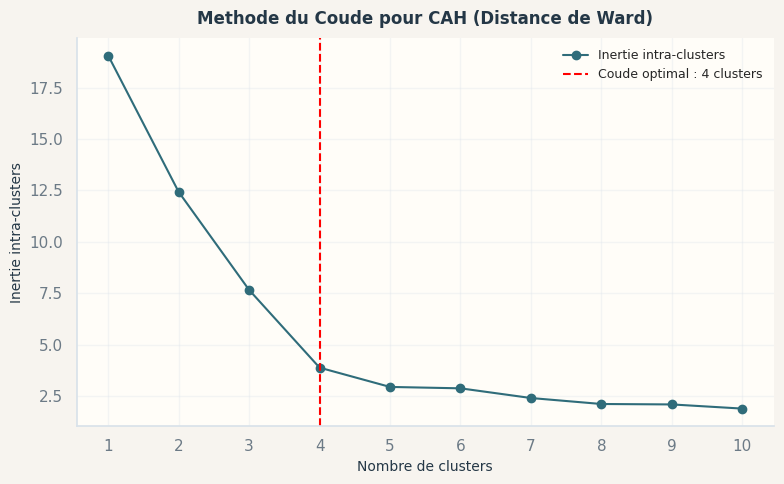

In [13]:
# Calcul de la matrice de distance
distance_matrix = pdist(X, metric='euclidean')
# Application de la méthode de linkage de Ward
Z = linkage(distance_matrix, method='ward')
# Calcul de la distance entre les clusters à chaque étape
last = Z[-10:, 2]
last_rev = last[::-1]
idxs = np.arange(1, len(last) + 1)
# Utilisation de KneeLocator pour trouver le coude
knee = KneeLocator(idxs, last_rev, curve='convex', direction='decreasing')
optimal_clusters = knee.knee
print(f'Nombre optimal de clusters (CAH) : {optimal_clusters}')

# Graphique du coude
plt.figure(figsize=(8, 5))
plt.plot(idxs, last_rev, marker='o', label='Inertie intra-clusters')
plt.axvline(optimal_clusters, color='red', linestyle='--', label=f'Coude optimal : {optimal_clusters} clusters')
plt.title('Methode du Coude pour CAH (Distance de Ward)', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de clusters', fontsize=10)
plt.ylabel('Inertie intra-clusters', fontsize=10)
plt.xticks(idxs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Le coude repère un saut dans les distances de fusion, mais c'est un signal indirect. Il ne montre pas la géographie réelle des regroupements. Le dendrogramme, lui, représente l'arbre de fusion complet et permet de confirmer visuellement si le nombre de clusters détecté correspond bien à une rupture structurelle dans les données.


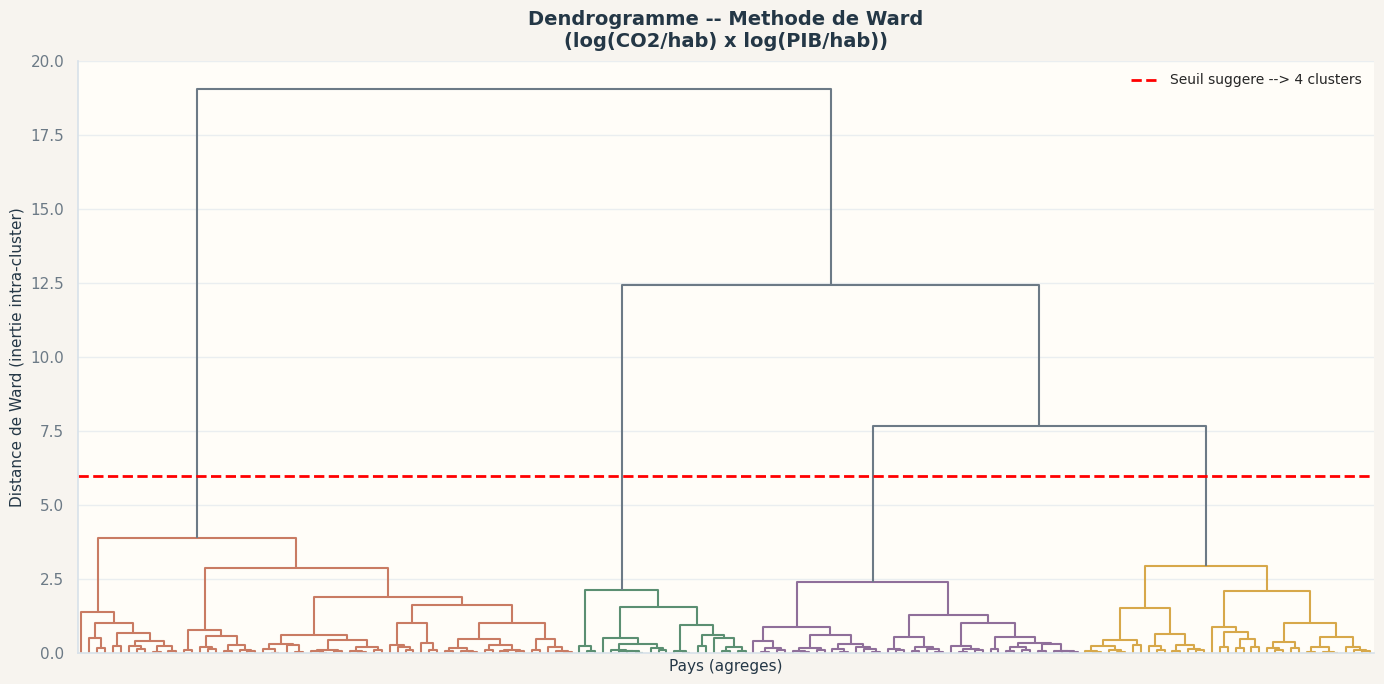

In [14]:
# Comparaison avec le dendrogramme

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, no_labels=True, color_threshold=Z[-3, 2], ax=ax,
           leaf_rotation=90, above_threshold_color=PALETTE['muted'])
ax.axhline(y=6, color='red',    linestyle='--', linewidth=2,
           label=f'Seuil suggere --> 4 clusters')

ax.set_title('Dendrogramme -- Methode de Ward\n(log(CO2/hab) x log(PIB/hab))',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pays (agreges)', fontsize=11)
ax.set_ylabel('Distance de Ward (inertie intra-cluster)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Le dendrogramme confirme une structure claire : au-delà du seuil en rouge, les branches se séparent en quatre groupes distincts avec des sauts de hauteur bien marqués entre les dernières fusions. Ce découpage est cohérent avec le signal du coude : on coupe l'arbre à 4 clusters et on projette maintenant chaque pays dans le plan CO2/PIB pour voir à quoi ressemble cette partition.


In [15]:
pio.renderers.default = 'notebook'
df_clust['cluster_cah'] = fcluster(Z, t=4, criterion='maxclust') - 1
df_clust['cluster_cah_str'] = df_clust['cluster_cah'].astype(str)
COLORS_CAH = cluster_color_map(['0', '1', '2', '3'])

# Sample random de pays pour les labels
seed = 123456789
labels_df = (
    df_clust
    .groupby('cluster_cah', group_keys=False)
    .sample(n=2, random_state=seed, replace=True)
)

# Subplots
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.7, 0.3],
    subplot_titles=(
        "Nuage de points - Clusters CAH",
        "Effectifs par cluster"
    )
)

# Nuage de points
for k in df_clust['cluster_cah_str'].unique():
    subset = df_clust[df_clust['cluster_cah_str'] == k]
    fig.add_trace(
        go.Scatter(
            x=subset['log_gdppc'],
            y=subset['log_co2pc'],
            mode='markers',
            name=f'Cluster {k}',
            marker=dict(
                color=COLORS_CAH[k],
                size=8,
                line=dict(width=0.5, color='white')
            ),
            text=subset['country'],
            hovertemplate="<b>%{text}</b><br>CO2: %{y}<br>PIB: %{x}<extra></extra>"
        ),
        row=1, col=1
    )

# centroïdes (étoiles colorées par cluster)
centroids = (
    df_clust
    .groupby('cluster_cah')[['log_gdppc', 'log_co2pc']]
    .mean()
    .reset_index()
)
for _, c in centroids.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[c['log_gdppc']], y=[c['log_co2pc']],
            mode='markers',
            marker=dict(size=18, symbol='star', color=COLORS_CAH[str(int(c['cluster_cah']))],
                        line=dict(width=1.5, color='black')),
            showlegend=False,
        ),
        row=1, col=1
    )

# étoile noire pour la légende
fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=14, symbol='star', color='black'),
        name='Centroïde',
    ),
    row=1, col=1
)

# labels
for _, row in labels_df.iterrows():
    fig.add_annotation(
        x=row['log_gdppc'],
        y=row['log_co2pc'],
        text=row['country'],
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        xshift=5,
        font=dict(size=11, color=PALETTE['ink']),
        bgcolor=PALETTE['paper'],
        bordercolor="rgba(0,0,0,0)",
        borderpad=3
    )

# Histogramme des effectifs par cluster
sizes = df_clust['cluster_cah'].value_counts().sort_index()
fig.add_trace(
    go.Bar(
        x=[f'Cluster {k}' for k in sizes.index],
        y=sizes.values,
        marker_color=[COLORS_CAH[str(k)] for k in sizes.index],
        text=sizes.values,
        textposition='outside',
        showlegend=False
    ),
    row=1, col=2
)

# layout
fig.update_layout(
    title=f'CAH - CO2/hab vs PIB/hab ({latest_year})',
    height=600
)

fig.update_xaxes(title_text='log10(PIB / habitant)', row=1, col=1)
fig.update_yaxes(title_text='log10(CO2 / habitant)', row=1, col=1)
fig.update_yaxes(title_text='Nombre de pays', row=1, col=2)
fig.show()

Le nuage de points dessine une organisation géographiquement et économiquement cohérente : les pays riches à fortes émissions s'isolent dans un coin, les pays pauvres dans l'autre, avec des profils intermédiaires entre les deux. Les positions visuelles sont parlantes, mais pour donner un vrai sens à chaque groupe il faut calculer leurs caractéristiques moyennes et leur trouver un nom.


In [16]:
# Nommage des clusters
cluster_names = {
    0: "Pays développés",
    1: "Pays en développement",
    2: "Pays en transition",
    3: "Pays en difficulté"
}  
df_clust['cluster_name'] = df_clust['cluster_cah'].map(cluster_names)
print('\n=== CARACTERISATION DETAILLEE DES CLUSTERS ===')
for k in sorted(df_clust['cluster_cah'].unique()):
    cluster_data = df_clust[df_clust['cluster_cah'] == k]
    n_pays = len(cluster_data)
    co2_pc_mean = cluster_data['co2_per_capita'].mean()
    gdppc_mean = cluster_data['gdp_per_capita'].mean()
    name = cluster_names.get(k, f'Cluster {k}')

    print(f'\nCluster {k} -- {name} ({n_pays} pays)')
    print(f' - CO2 par habitant moyen : {co2_pc_mean:.2f} t/hab')
    print(f' - PIB par habitant moyen : {gdppc_mean:.2f} USD/hab')

    top_countries = cluster_data.nlargest(3, 'co2_per_capita')['country']
    print(' - Top 3 pays par CO2/habitant :')
    for c in top_countries:
        print(f'   * {c}')


=== CARACTERISATION DETAILLEE DES CLUSTERS ===

Cluster 0 -- Pays développés (63 pays)
 - CO2 par habitant moyen : 9.26 t/hab
 - PIB par habitant moyen : 38110.35 USD/hab
 - Top 3 pays par CO2/habitant :
   * Qatar
   * Kuwait
   * Trinidad and Tobago

Cluster 1 -- Pays en développement (22 pays)
 - CO2 par habitant moyen : 0.19 t/hab
 - PIB par habitant moyen : 1395.23 USD/hab
 - Top 3 pays par CO2/habitant :
   * Gambia
   * Mali
   * Togo

Cluster 2 -- Pays en transition (42 pays)
 - CO2 par habitant moyen : 2.91 t/hab
 - PIB par habitant moyen : 12652.68 USD/hab
 - Top 3 pays par CO2/habitant :
   * Iraq
   * Barbados
   * Algeria

Cluster 3 -- Pays en difficulté (37 pays)
 - CO2 par habitant moyen : 0.89 t/hab
 - PIB par habitant moyen : 4786.89 USD/hab
 - Top 3 pays par CO2/habitant :
   * North Korea
   * Kyrgyzstan
   * Congo


### 5.3 Validation par K-Means

La CAH produit 4 groupes aux profils bien contrastés. Pour tester la robustesse de cette partition, on passe à K-Means : une méthode radicalement différente qui part des données brutes sans structure hiérarchique et minimise la variance interne des clusters. Si les deux méthodes convergent vers une organisation similaire, c'est un bon signal de stabilité de la structure sous-jacente.


Nombre optimal de clusters (K-Means) : 3


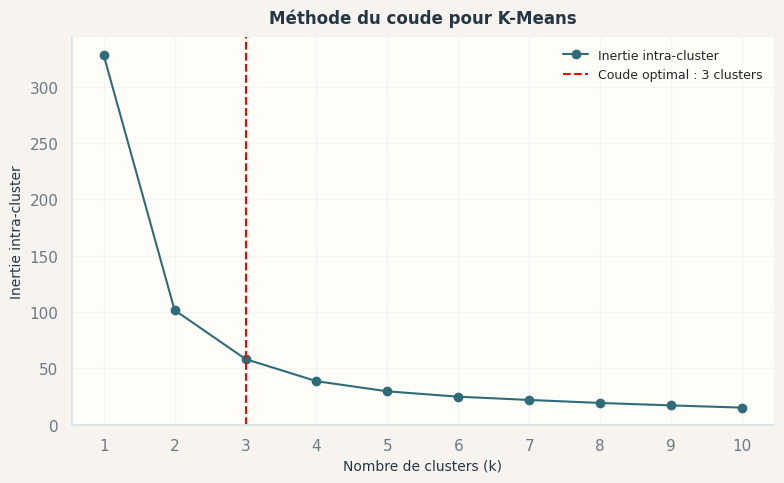

In [17]:
K_range = range(1, 11)
inertias = []

# K-Means pour différentes valeurs de K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=21, n_init=150)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Calcul du coude
knee = KneeLocator(
    K_range,
    inertias,
    curve='convex',
    direction='decreasing'
)

optimal_k = knee.knee

print(f'Nombre optimal de clusters (K-Means) : {optimal_k}')

# Graphique du coude
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertias, marker='o', label='Inertie intra-cluster')

plt.axvline(
    optimal_k,
    color='red',
    linestyle='--',
    label=f'Coude optimal : {optimal_k} clusters'
)

plt.title('Méthode du coude pour K-Means', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de clusters (k)', fontsize=10)
plt.ylabel('Inertie intra-cluster', fontsize=10)

plt.xticks(K_range)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

K-Means identifie un coude à trois clusters, un de moins que la CAH. Ce n'est pas un désaccord fondamental : K-Means est plus sensible à la compacité géométrique des groupes et peut en fusionner deux que la CAH distinguait pour d'autres raisons. Le scatter va montrer concrètement comment les frontières se sont repositionnées par rapport à la partition précédente.


In [18]:
# Clusterisation K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=150)
df_clust['cluster_kmeans'] = kmeans.fit_predict(
    df_clust[['log_gdppc', 'log_co2pc']]
)
df_clust['cluster_kmeans_str'] = df_clust['cluster_kmeans'].astype(str)
COLORS_KMEANS = cluster_color_map(['0', '1', '2', '3'])

# Sample random de pays pour les labels
seed = 123456789
labels_df = (
    df_clust
    .groupby('cluster_kmeans', group_keys=False)
    .sample(n=2, random_state=seed, replace=True)
)

# Subplots
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.7, 0.3],
    subplot_titles=(
        "Nuage de points - Clusters K-Means",
        "Effectifs par cluster"
    )
)

# nuage de points
for k in df_clust['cluster_kmeans_str'].unique():
    subset = df_clust[df_clust['cluster_kmeans_str'] == k]
    fig.add_trace(
        go.Scatter(
            x=subset['log_gdppc'],
            y=subset['log_co2pc'],
            mode='markers',
            name=f'Cluster {k}',
            marker=dict(
                color=COLORS_KMEANS[k],
                size=8,
                line=dict(width=0.5, color='white')
            ),
            text=subset['country'],
            hovertemplate="<b>%{text}</b><br>CO2: %{y}<br>PIB: %{x}<extra></extra>"
        ),
        row=1, col=1
    )

# centroïdes (étoiles colorées par cluster)
centroids = kmeans.cluster_centers_
for k in range(optimal_k):
    fig.add_trace(
        go.Scatter(
            x=[centroids[k, 0]], y=[centroids[k, 1]],
            mode='markers',
            marker=dict(size=18, symbol='star', color=COLORS_KMEANS[str(k)],
                        line=dict(width=1.5, color='black')),
            showlegend=False,
        ),
        row=1, col=1
    )

# étoile noire pour la légende
fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=14, symbol='star', color='black'),
        name='Centroïde',
    ),
    row=1, col=1
)

# labels
for _, row in labels_df.iterrows():
    fig.add_annotation(
        x=row['log_gdppc'],
        y=row['log_co2pc'],
        text=row['country'],
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        xshift=5,
        font=dict(size=11, color=PALETTE['ink']),
        bgcolor=PALETTE['paper'],
        bordercolor="rgba(0,0,0,0)",
        borderpad=3
    )

# Histogramme des effectifs par cluster
sizes = df_clust['cluster_kmeans'].value_counts().sort_index()
fig.add_trace(
    go.Bar(
        x=[f'Cluster {k}' for k in sizes.index],
        y=sizes.values,
        marker_color=[COLORS_KMEANS[str(k)] for k in sizes.index],
        text=sizes.values,
        textposition='outside',
        showlegend=False
    ),
    row=1, col=2
)

# Layout
fig.update_layout(
    title=f'K-Means (k={optimal_k}) - CO2/hab vs PIB/hab ({latest_year})',
    height=600
)
fig.update_xaxes(title_text='log10(PIB / habitant)', row=1, col=1)
fig.update_yaxes(title_text='log10(CO2 / habitant)', row=1, col=1)
fig.update_yaxes(title_text='Nombre de pays', row=1, col=2)
fig.show()

In [19]:
cluster_names_km = {
    0: "Pays en développement",
    1: "Pays développés",
    2: "Pays en transition"
}
df_clust['cluster_kmeans_name'] = df_clust['cluster_kmeans'].map(cluster_names_km)
print('\n=== CARACTERISATION DETAILLEE DES CLUSTERS K-MEANS ===')
for k in sorted(df_clust['cluster_kmeans'].unique()):
    cluster_data = df_clust[df_clust['cluster_kmeans'] == k]
    n_pays = len(cluster_data)
    co2_pc_mean = cluster_data['co2_per_capita'].mean()
    gdppc_mean = cluster_data['gdp_per_capita'].mean()
    name = cluster_names_km.get(k, f'Cluster {k}')

    print(f'\nCluster {k} -- {name} ({n_pays} pays)')
    print(f' - CO2 par habitant moyen : {co2_pc_mean:.2f} t/hab')
    print(f' - PIB par habitant moyen : {gdppc_mean:.2f} USD/hab')

    top_countries = cluster_data.nlargest(3, 'co2_per_capita')['country']
    print(' - Top 3 pays par CO2/habitant :')
    for c in top_countries:
        print(f'   * {c}')


=== CARACTERISATION DETAILLEE DES CLUSTERS K-MEANS ===

Cluster 0 -- Pays en développement (32 pays)
 - CO2 par habitant moyen : 0.29 t/hab
 - PIB par habitant moyen : 1872.45 USD/hab
 - Top 3 pays par CO2/habitant :
   * Zimbabwe
   * Comoros
   * Nepal

Cluster 1 -- Pays développés (75 pays)
 - CO2 par habitant moyen : 8.40 t/hab
 - PIB par habitant moyen : 34708.33 USD/hab
 - Top 3 pays par CO2/habitant :
   * Qatar
   * Kuwait
   * Trinidad and Tobago

Cluster 2 -- Pays en transition (57 pays)
 - CO2 par habitant moyen : 1.81 t/hab
 - PIB par habitant moyen : 8370.73 USD/hab
 - Top 3 pays par CO2/habitant :
   * Equatorial Guinea
   * Venezuela
   * Ukraine


La clustering via K-Means a identifié 3 clusters optimaux, légèrement moins que les 4 clusters suggérés par la CAH. Les clusters K-Means présentent des caractéristiques similaires à ceux de la CAH, avec des groupes de pays développés, en développement et en transition. Cependant, la répartition des pays entre les clusters peut différer légèrement entre les deux méthodes, ce qui souligne l'importance de comparer les résultats et d'interpréter les clusters dans le contexte de l'analyse.


### 5.4 Comparaison des deux méthodes - Score de silhouette

On a maintenant deux partitions distinctes sur les mêmes données. Pour les départager objectivement, on calcule le **score de silhouette**.

#### Qu'est-ce que le score de silhouette ?

Le score de silhouette évalue, pour chaque individu, à quel point il est **bien classé** dans son cluster. L'idée est simple : on compare la distance moyenne d'un individu aux autres membres de son propre cluster avec la distance moyenne aux membres du cluster voisin le plus proche.

Pour un individu $i$ appartenant au cluster $C_k$, on définit deux quantités :

- $a(i)$ : la **distance intra-cluster**, c'est-à-dire la distance moyenne entre $i$ et tous les autres points de $C_k$. Elle reflète la **cohésion**, plus $a(i)$ est petit, plus l'individu est proche de ses voisins de cluster.

- $b(i)$ : la **distance inter-cluster**, c'est-à-dire la plus petite distance moyenne entre $i$ et l'ensemble des points d'un autre cluster $C_l$ ($l \neq k$). Elle reflète la **séparation**, plus $b(i)$ est grand, plus l'individu est éloigné du cluster voisin.

Le score de silhouette de l'individu $i$ est alors :

$$
s(i) = \frac{b(i) - a(i)}{\max\bigl(a(i),\; b(i)\bigr)}
$$

Le score $s(i)$ est borné :

$$
-1 \leq s(i) \leq 1
$$

#### Interprétation

| Valeur de $s(i)$ | Signification |
|---|---|
| $s(i) \approx 1$ | L'individu est **très bien classé** : il est beaucoup plus proche de son propre cluster que du cluster voisin ($a(i) \ll b(i)$). |
| $s(i) \approx 0$ | L'individu se situe **à la frontière** entre deux clusters : il pourrait appartenir à l'un ou à l'autre sans grande différence ($a(i) \approx b(i)$). |
| $s(i) < 0$ | L'individu est **mal classé** : il est en moyenne plus proche des points d'un autre cluster que de ceux du sien ($a(i) > b(i)$). Il aurait probablement dû être affecté ailleurs. |

En résumé : un score négatif signale un individu qui « n'est pas à sa place » dans le cluster qui lui a été attribué. Plus le score est proche de 1, plus l'appartenance au cluster est nette et justifiée.

#### Score global

Pour résumer la qualité d'une partition entière, on calcule la **moyenne des scores de silhouette** sur tous les individus :

$$
\bar{s} = \frac{1}{n} \sum_{i=1}^{n} s(i)
$$

C'est cette valeur globale qu'on utilise pour **comparer les deux méthodes de clustering** : la partition avec le score moyen le plus élevé offre des clusters plus cohérents et mieux séparés.

> _Source : [K-Means & Silhouette Analysis](https://scikit-learn.org/stable/modules/clustering.html)_

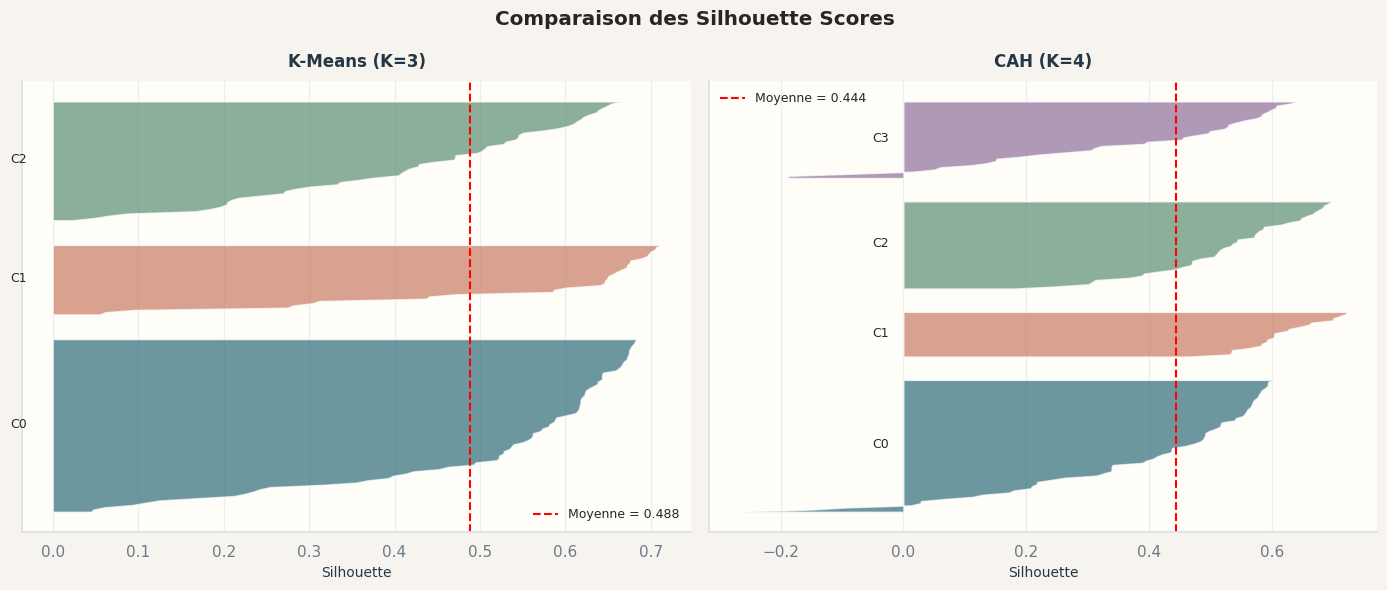

K-Means (K=3) : silhouette = 0.488
CAH (K=4) : silhouette = 0.444


In [20]:
labels_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=150).fit_predict(X)
labels_cah = df_clust['cluster_cah'] = fcluster(Z, t=4, criterion='maxclust') - 1


methods = {
    'K-Means (K=3)': labels_kmeans,
    'CAH (K=4)': labels_cah,
}

fig, axes = plt.subplots(1, len(methods), figsize=(14, 6))

for ax, (name, labels) in zip(axes, methods.items()):
    score = silhouette_score(X, labels)
    sample_scores = silhouette_samples(X, labels)

    y_lower = 10
    n_clusters = len(set(labels))

    for k in range(n_clusters):
        cluster_scores = np.sort(sample_scores[labels == k])
        size = len(cluster_scores)
        y_upper = y_lower + size

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores, alpha=0.7)
        ax.text(-0.05, y_lower + size / 2, f'C{k}', fontsize=9, va='center')
        y_lower = y_upper + 10

    ax.axvline(score, color='red', linestyle='--', label=f'Moyenne = {score:.3f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Silhouette')
    ax.set_yticks([])
    ax.legend(fontsize=9)

plt.suptitle('Comparaison des Silhouette Scores', fontweight='bold')
plt.tight_layout()
plt.show()

# résumé rapide
for name, labels in methods.items():
    print(f'{name} : silhouette = {silhouette_score(X, labels):.3f}')

K-Means obtient un score de silhouette de **0.488** contre **0.444** pour la CAH, ce qui confirme que sa partition est géométriquement plus compacte dans cet espace à deux dimensions. Ce résultat était d'ailleurs prévisible en observant le graphique de la CAH : avec 4 clusters, certains groupes sont très proches les uns des autres voire empilés dans le nuage de points (notamment les clusters 2 et 3 qui se chevauchent dans la zone intermédiaire du PIB). Des individus situés à la frontière entre ces clusters empilés se retrouvent naturellement plus proches du centroïde voisin que du leur, ce qui produit les **scores de silhouette négatifs** visibles sur le diagramme de droite. Avec seulement 3 clusters, le K-Means évite ce problème : chaque groupe dispose de plus d'espace et les frontières entre clusters sont plus nettes, d'où l'absence de valeurs négatives et un score global plus élevé.

Pour autant, la CAH n'est pas à écarter : elle capture une nuance supplémentaire (la distinction entre pays intermédiaires et pays en transition) qui pourrait devenir pertinente dès qu'on enrichira l'espace avec les variables énergétiques. Ces deux lectures complémentaires serviront de base pour la suite de l'analyse.

## 6. Problématique

### Question centrale

> **Parmi les principaux déterminants (économiques, démographiques et industriels), lesquels d'entre eux expliquent le mieux l'évolution des émissions de CO₂ et du réchauffement climatique, et sur quels leviers prioritaires faut-il agir pour les réduire ?**

L'EDA a mis en évidence plusieurs éléments de réponse partiels. Le PIB/hab explique à lui seul 82% de la variance du CO2/hab (section 4.2), mais la dispersion autour de cette tendance montre que le niveau de richesse ne suffit pas : à PIB/hab comparable, certains pays émettent deux à trois fois plus que d'autres selon leur mix énergétique. Par ailleurs, la part du charbon prise isolément n'explique quasiment rien ($R^2$ = 0.06), ce qui suggère que c'est la **combinaison** des déterminants (et non un facteur unique) qui structure les profils d'émissions.

La classification en dimension 2 a permis de segmenter les pays en grands profils développement-émissions, mais elle reste limitée à deux variables. Elle ne capte ni la structure du mix énergétique, ni les GHG non-CO2 (méthane, N2O), ni les dynamiques sectorielles.

### Ce que nos analyses n'ont pas encore résolu

**Quels déterminants précisément ?** Le PIB/hab domine, mais quelle part de la variance revient au mix énergétique une fois l'effet richesse contrôlé ? → _Régression linéaire multiple (N > 2)_

**Quels profils en haute dimension ?** En intégrant simultanément les parts de combustibles, les secteurs, les GHG non-CO2 et les indicateurs économiques, quels groupes de pays émergent ? → _Classification N > 2_

**Quels leviers prioritaires ?** Quelles variables portent le plus d'inertie dans la structure des émissions mondiales ? → _ACP et cercle des corrélations_

### Hypothèse pour la Phase 2

La structure du mix énergétique (parts combustibles et sectorielles), combinée au PIB/habitant, constitue un meilleur prédicteur des émissions CO₂ per capita que les facteurs démographiques ou économiques seuls - une hypothèse testable par régression multiple et dont l'ACP permettra d'identifier les axes dominants.


# Phase 2 - Analyse des données en dimension n > 2


### 7.1 Variables retenues

On utilise des variables **intensives** (per capita, parts, ratios) pour neutraliser l'effet taille. Une ACP sur les variables brutes donnerait un premier axe trivial "gros pays vs petits pays" - sans intérêt pour notre problématique.

| Dimension       | Variables                                                                        |
| --------------- | -------------------------------------------------------------------------------- |
| **Niveau**      | CO2/hab, PIB/hab                                                                 |
| **Mix fossile** | Parts charbon, pétrole, gaz, élec., transport, industrie                         |
| **GES non-CO2** | CH4 agri./hab, CH4 fugitif/hab, CH4 déchets/hab, N2O agri./hab, F-gaz indus./hab |
| **Efficacité**  | Intensité énergétique, intensité carbone du PIB                                  |


In [21]:
# --- préparation des variables pour la Phase 2 ---

# 1. df_acp + colonnes dérivées
df_acp = df_work[df_work['year'] == latest_year].copy()

# parts combustibles
df_acp['part_charbon']   = df_acp['CO2_Coal'] / df_acp['co2'].clip(lower=1)
df_acp['part_petrole']   = df_acp['CO2_Oil']  / df_acp['co2'].clip(lower=1)
df_acp['part_gaz']       = df_acp['CO2_Gas']  / df_acp['co2'].clip(lower=1)

# parts sectorielles
df_acp['part_elec']      = df_acp['CO2_Electricity and heat'] / df_acp['co2'].clip(lower=1)
df_acp['part_transport'] = df_acp['CO2_Transport'] / df_acp['co2'].clip(lower=1)
df_acp['part_industrie'] = df_acp['CO2_Manufacturing and construction'] / df_acp['co2'].clip(lower=1)

# GES non-CO2 per capita
df_acp['ch4_agri_pc']   = df_acp['CH4_Agriculture']       / df_acp['population']
df_acp['ch4_fugit_pc']  = df_acp['CH4_Fugitive emissions'] / df_acp['population']
df_acp['ch4_waste_pc']  = df_acp['CH4_Waste']             / df_acp['population']
df_acp['n2o_agri_pc']   = df_acp['N2O_Agriculture']       / df_acp['population']
df_acp['fgaz_indus_pc'] = df_acp['FGASES_Industry']       / df_acp['population']

# intensités
df_acp['intensite_energ']   = df_acp['primary_energy_consumption'] / (df_acp['gdp'] / 1e9).clip(lower=1e-6)
df_acp['intensite_carbone'] = df_acp['co2'] / (df_acp['gdp'] / 1e9).clip(lower=1e-6)

# 2. acp_vars et acp_labels
acp_vars = [
    'co2_per_capita', 'gdp_per_capita',
    'part_charbon', 'part_petrole', 'part_gaz',
    'part_elec', 'part_transport', 'part_industrie',
    'ch4_agri_pc', 'ch4_fugit_pc', 'ch4_waste_pc',
    'n2o_agri_pc', 'fgaz_indus_pc',
    'intensite_energ', 'intensite_carbone',
]

acp_labels = [
    'CO2/hab', 'PIB/hab',
    'Part Charbon', 'Part Pétrole', 'Part Gaz',
    'Part Élec.', 'Part Transport', 'Part Industrie',
    'CH4 Agri./hab', 'CH4 Fugitif/hab', 'CH4 Déchets/hab',
    'N2O Agri./hab', 'F-gaz Indus./hab',
    'Intens. énerg.', 'Intens. carbone',
]

# 3. clip des zéros
for v in acp_vars:
    df_acp[v] = df_acp[v].clip(lower=1e-10)

# 4. df_pca
df_pca = df_acp[acp_vars + ['country', 'co2']].dropna().copy()

# 5. standardisation unique
scaler = StandardScaler()
X_std = scaler.fit_transform(df_pca[acp_vars])

# 6. ACP complète (eigenvalues, eigenvectors, projections, contributions)
n, p = X_std.shape
R = (1 / n) * X_std.T @ X_std
eigvals, eigvecs = np.linalg.eigh(R)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
Y = X_std @ eigvecs
s = np.sqrt(eigvals)
contribs = eigvals / eigvals.sum()
cumul = np.cumsum(contribs)
n_lambda_sup_1 = (eigvals >= 1).sum()

# 7. variables utilitaires
countries = df_pca['country'].values
co2_total = df_pca['co2'].values
co2_pc    = df_pca['co2_per_capita'].values

# restaure COLORS_CAH int-keys pour Phase 2 (Phase 1 les redéfinit en str-keys)
COLORS_CAH = {k: CLUSTER_COLORS[k] for k in range(4)}

print(f'Individus : {len(df_pca)} pays | Variables : {len(acp_vars)} | Année : {latest_year}')

Individus : 164 pays | Variables : 15 | Année : 2022


### 7.2 Centrage-réduction, diagonalisation et vérifications


In [22]:
# vérifications
checks = [
    ('Σλ_k = p',       f'{eigvals.sum():.4f} = {p}',  np.isclose(eigvals.sum(), p)),
]

for name, detail, ok in checks:
    print(f'  {"✓" if ok else "✗"}  {name:18s}  {detail}')

  ✓  Σλ_k = p            15.0000 = 15


La somme des valeurs propres est égale à 15, ce qui correspond exactement au nombre de variables actives utilisées dans l'ACP. C'est cohérent puisque les données ont été centrées-réduites : chaque variable contribue une variance unitaire de 1, et l'inertie totale du nuage est donc égale au nombre de variables.


### 7.3 Scree plot et choix des composantes

On cherche combien de composantes retenir. Sur la matrice de corrélation, chaque variable originale a une variance de 1 - donc une composante qui capte $\lambda_k < 1$ apporte moins qu'une seule variable d'origine. On retient les composantes avec $\lambda_k \geq 1$, complété par le seuil de 80% de variance cumulée.


In [23]:
# tableau des valeurs propres et variance expliquée
tab = pd.DataFrame({
    'Composante': [f'C{k+1}' for k in range(p)],
    'λ_k': eigvals,
    '% variance': contribs * 100,
    '% cumulé': cumul * 100,
})
print(tab.to_string(index=False, float_format='{:.3f}'.format))

n_80 = np.searchsorted(cumul, 0.80) + 1
print(f'\nλ ≥ 1 : {n_lambda_sup_1} composantes | 80% variance : {n_80} composantes')

Composante   λ_k  % variance  % cumulé
        C1 4.782      31.878    31.878
        C2 2.097      13.981    45.859
        C3 1.911      12.739    58.598
        C4 1.358       9.056    67.654
        C5 1.202       8.016    75.670
        C6 0.950       6.331    82.001
        C7 0.791       5.271    87.272
        C8 0.503       3.355    90.627
        C9 0.415       2.764    93.391
       C10 0.334       2.229    95.620
       C11 0.325       2.168    97.788
       C12 0.138       0.921    98.710
       C13 0.096       0.639    99.348
       C14 0.067       0.447    99.796
       C15 0.031       0.204   100.000

λ ≥ 1 : 5 composantes | 80% variance : 6 composantes


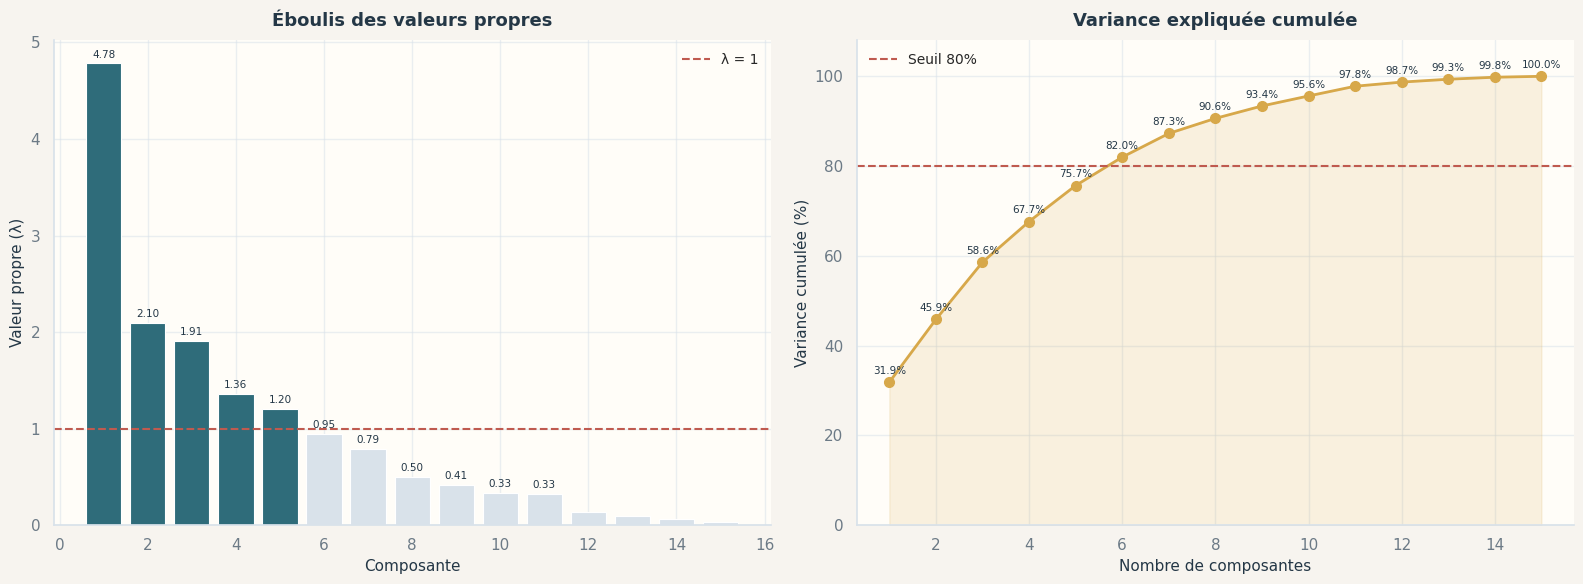

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = [PALETTE['primary'] if v >= 1 else PALETTE['grid'] for v in eigvals]
ax1.bar(range(1, p + 1), eigvals, color=colors_bar, edgecolor='white', linewidth=0.8)
ax1.axhline(y=1, color=PALETTE['danger'], linestyle='--', linewidth=1.5, label='λ = 1')
for k, v in enumerate(eigvals):
    if v > 0.15:
        ax1.text(k + 1, v + 0.06, f'{v:.2f}', ha='center', fontsize=7.5, color=PALETTE['ink'])
ax1.set_xlabel('Composante', fontsize=11)
ax1.set_ylabel('Valeur propre (λ)', fontsize=11)
ax1.set_title('Éboulis des valeurs propres', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

ax2.plot(range(1, p + 1), cumul * 100, '-o', color=PALETTE['accent'], linewidth=2, markersize=7)
ax2.axhline(y=80, color=PALETTE['danger'], linestyle='--', linewidth=1.5, label='Seuil 80%')
ax2.fill_between(range(1, p + 1), cumul * 100, alpha=0.15, color=PALETTE['accent'])
for k, c in enumerate(cumul):
    ax2.text(k + 1, c * 100 + 1.8, f'{c*100:.1f}%', ha='center', fontsize=7.5, color=PALETTE['ink'])
ax2.set_xlabel('Nombre de composantes', fontsize=11)
ax2.set_ylabel('Variance cumulée (%)', fontsize=11)
ax2.set_title('Variance expliquée cumulée', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 108)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Interprétation

Le critère $\lambda \geq 1$ retient **5 composantes** (~76% d'inertie). Le seuil 80% est atteint à 6 composantes. C'est cohérent avec un jeu de 15 variables couvrant des dimensions très différentes - la variance est naturellement répartie.


### 7.4 Plan C1 × C2 - Individus et cercle des corrélations


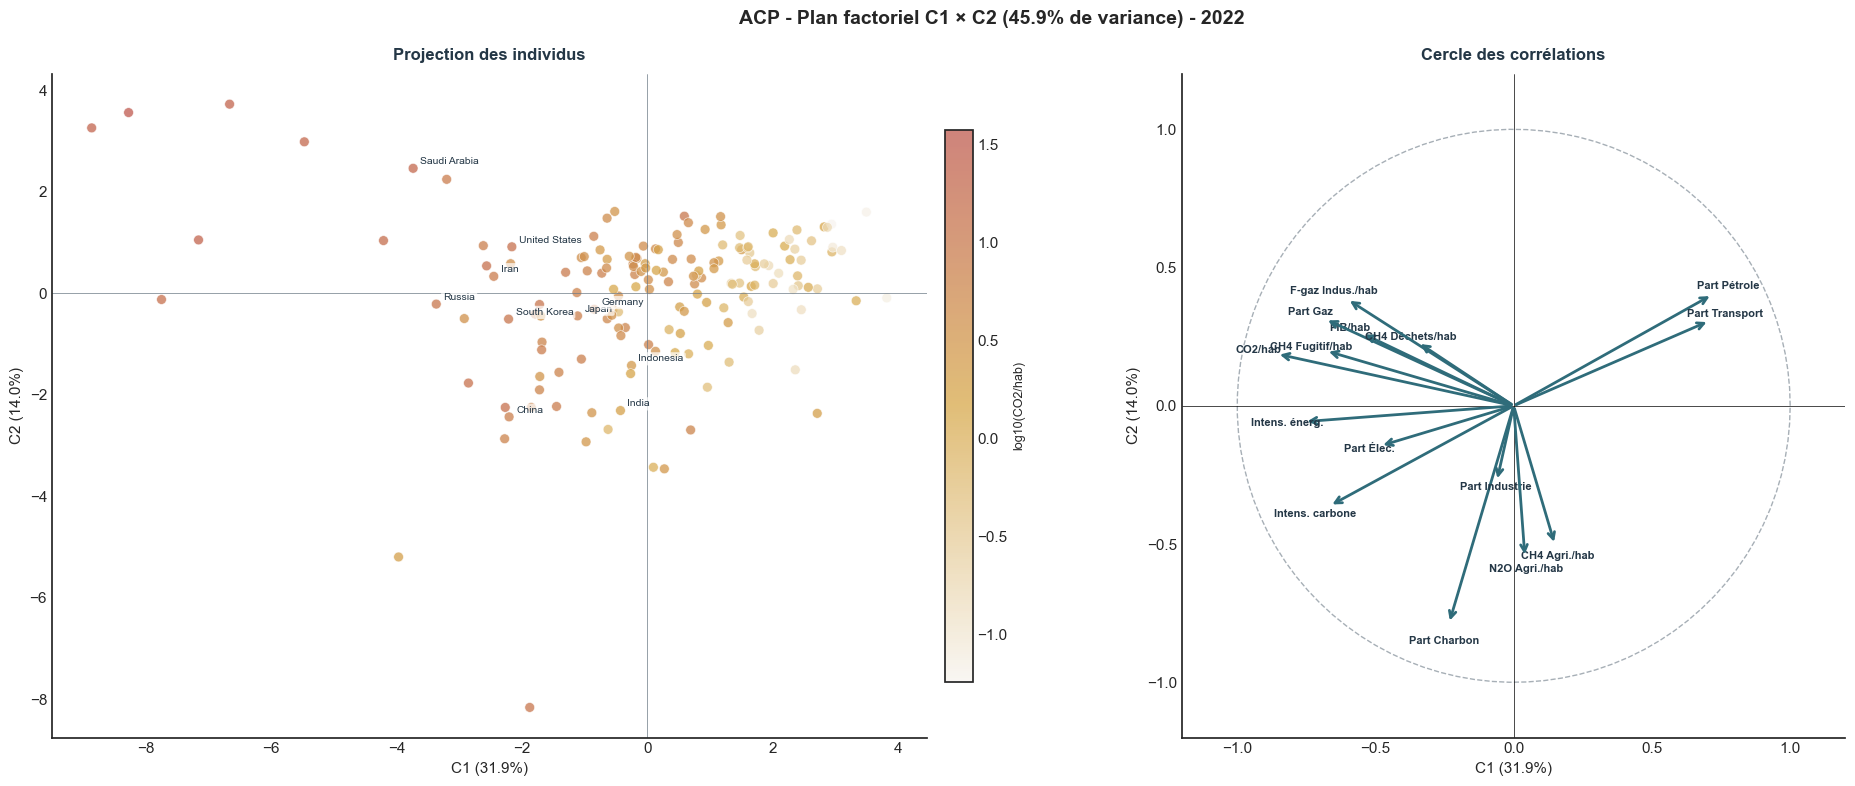

In [25]:
with plt.style.context('seaborn-v0_8-white'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'ACP - Plan factoriel C1 × C2 ({cumul[1]*100:.1f}% de variance) - {latest_year}',
                 fontsize=14, fontweight='bold')

    # -- individus --
    sc = ax1.scatter(Y[:, 0], Y[:, 1], c=np.log10(co2_pc.clip(min=1e-3)),
                     cmap=EMISSIONS_CMAP, alpha=0.75, edgecolors='white', linewidth=0.5, s=50)
    ax1.axhline(0, color=PALETTE['muted'], linewidth=0.5)
    ax1.axvline(0, color=PALETTE['muted'], linewidth=0.5)

    top10_idx = np.argsort(-co2_total)[:10]
    for i in top10_idx:
        ax1.annotate(countries[i][:14], (Y[i, 0], Y[i, 1]),
                     xytext=(5, 3), textcoords='offset points', fontsize=7.5,
                     color=PALETTE['ink'],
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                               alpha=0.7, edgecolor='none'))

    cbar = plt.colorbar(sc, ax=ax1, fraction=0.03, pad=0.02)
    cbar.set_label('log10(CO2/hab)', fontsize=9)
    ax1.set_xlabel(f'C1 ({contribs[0]*100:.1f}%)', fontsize=11)
    ax1.set_ylabel(f'C2 ({contribs[1]*100:.1f}%)', fontsize=11)
    ax1.set_title('Projection des individus', fontsize=12, fontweight='bold')

    # -- cercle des corrélations --
    theta = np.linspace(0, 2 * np.pi, 100)
    ax2.plot(np.cos(theta), np.sin(theta), '--', color=PALETTE['muted'], linewidth=1, alpha=0.6)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.axvline(0, color='black', linewidth=0.5)

    for k in range(p):
        xc = s[0] * eigvecs[k, 0]
        yc = s[1] * eigvecs[k, 1]
        ax2.annotate('', xy=(xc, yc), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=PALETTE['primary'], lw=2))
        ax2.text(xc * 1.08, yc * 1.08, acp_labels[k], fontsize=8,
                 ha='center', va='center', color=PALETTE['ink'], fontweight='bold')

    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_xlabel(f'C1 ({contribs[0]*100:.1f}%)', fontsize=11)
    ax2.set_ylabel(f'C2 ({contribs[1]*100:.1f}%)', fontsize=11)
    ax2.set_title('Cercle des corrélations', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [26]:
# qualités et contributions C1-C2

cos2_c1 = (s[0] * eigvecs[:, 0])**2
cos2_c2 = (s[1] * eigvecs[:, 1])**2
cos2_12 = cos2_c1 + cos2_c2

tab_2d = pd.DataFrame({
    'Variable': acp_labels,
    'cor(X, C1)': s[0] * eigvecs[:, 0],
    'cor(X, C2)': s[1] * eigvecs[:, 1],
    'Ctr C1 (%)': eigvecs[:, 0]**2 * 100,
    'Ctr C2 (%)': eigvecs[:, 1]**2 * 100,
    'cos²(C1)': cos2_c1,
    'cos²(C2)': cos2_c2,
    'cos²(C1+C2)': cos2_12,
}).sort_values('cos²(C1+C2)', ascending=False)

print(tab_2d.to_string(index=False, float_format='{:.3f}'.format))
print(f'\nBien représentées (cos² ≥ 0.5) : {(cos2_12 >= 0.5).sum()} / {p}')

        Variable  cor(X, C1)  cor(X, C2)  Ctr C1 (%)  Ctr C2 (%)  cos²(C1)  cos²(C2)  cos²(C1+C2)
         CO2/hab      -0.856       0.187      15.317       1.674     0.732     0.035        0.768
    Part Pétrole       0.718       0.402      10.776       7.690     0.515     0.161        0.677
    Part Charbon      -0.234      -0.787       1.144      29.507     0.055     0.619        0.674
  Part Transport       0.707       0.307      10.456       4.489     0.500     0.094        0.594
  Intens. énerg.      -0.757      -0.057      11.980       0.157     0.573     0.003        0.576
 Intens. carbone      -0.665      -0.362       9.245       6.236     0.442     0.131        0.573
        Part Gaz      -0.681       0.313       9.700       4.673     0.464     0.098        0.562
F-gaz Indus./hab      -0.601       0.385       7.558       7.069     0.361     0.148        0.510
 CH4 Fugitif/hab      -0.678       0.199       9.621       1.882     0.460     0.039        0.500
         PIB/hab    

#### Interprétation C1 × C2

- **C1** (~32%) : axe d'**intensité fossile** - oppose les pays à fort CO2/hab et forte part pétrole/transport aux pays sobres en carbone
- **C2** (~14%) : axe **charbon + agriculture** - sépare les pays dépendants du charbon et les pays à fortes émissions agricoles (CH4, N2O)
- Les émissions fugitives de CH4 sont côté C1 (liées à l'extraction fossile), pas côté agriculture - logique
- Variables proches du centre (Part Industrie, CH4 Déchets) : mal captées dans ce plan, il faut d'autres axes

**Cercle des corrélations** : les variables d'intensité fossile (CO2/hab, part gaz, intensité énergétique, CH4 fugitif) sont regroupées à gauche $\rightarrow$ forte corrélation mutuelle, même profil d'économie fossile. Part Pétrole et Part Transport sont quasi superposées à droite. Part Charbon pointe seul vers le bas, orthogonal aux autres : dimension indépendante. Les flèches courtes au centre (Part Industrie, CH4 Déchets) sont mal captées par ce plan.

**Projection des individus** : les grands émetteurs fossiles (Arabie saoudite, USA, Russie) sont à gauche, les pays charbon (Inde, Chine) se distinguent vers le bas via C2, les pays sobres en carbone sont à droite. Le gradient de couleur confirme : teintes foncées (fort CO2/hab) à gauche, claires à droite.


### 7.5 Analyse 3D interactive - Projection et sphère des corrélations


In [27]:
# -- projection 3D des individus --
fig = go.Figure(go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2], mode='markers',
    marker=dict(size=4, color=np.log10(co2_pc.clip(min=1e-3)),
                colorscale='YlOrRd', opacity=0.75,
                line=dict(width=0.3, color=PALETTE['muted']),
                colorbar=dict(title='log₁₀(CO2/hab)')),
    text=countries,
    hovertemplate='%{text}<br>C1: %{x:.2f}<br>C2: %{y:.2f}<br>C3: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    height=650,
    title_text=f'Projection 3D - C1 × C2 × C3 ({cumul[2]*100:.1f}% de variance)',
    scene=dict(
        xaxis_title=f'C1 ({contribs[0]*100:.1f}%)',
        yaxis_title=f'C2 ({contribs[1]*100:.1f}%)',
        zaxis_title=f'C3 ({contribs[2]*100:.1f}%)',
        bgcolor=PALETTE['panel'],
    ),
    margin=dict(t=50, b=10, l=10, r=10),
)
fig.show()

In [28]:
# -- sphère des corrélations 3D --

# surface de la sphère unité
u_s = np.linspace(0, 2 * np.pi, 30)
v_s = np.linspace(0, np.pi, 15)
xs = np.outer(np.cos(u_s), np.sin(v_s))
ys = np.outer(np.sin(u_s), np.sin(v_s))
zs = np.outer(np.ones_like(u_s), np.cos(v_s))

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xs, y=ys, z=zs, opacity=0.05,
    colorscale=[[0, PALETTE['muted']], [1, PALETTE['muted']]], showscale=False,
))

# vecteurs des variables
for k in range(p):
    xc = s[0] * eigvecs[k, 0]
    yc = s[1] * eigvecs[k, 1]
    zc = s[2] * eigvecs[k, 2]

    fig.add_trace(go.Scatter3d(
        x=[0, xc], y=[0, yc], z=[0, zc], mode='lines+text',
        line=dict(color=PALETTE['primary'], width=4),
        text=['', acp_labels[k]],
        textposition='top center',
        textfont=dict(size=9, color=PALETTE['ink']),
        showlegend=False,
        hovertemplate=f'{acp_labels[k]}<br>C1: {xc:.3f}<br>C2: {yc:.3f}<br>C3: {zc:.3f}<extra></extra>',
    ))
    fig.add_trace(go.Scatter3d(
        x=[xc], y=[yc], z=[zc], mode='markers',
        marker=dict(size=4, color=PALETTE['primary']),
        showlegend=False, hoverinfo='skip',
    ))

fig.update_layout(
    height=650,
    title_text=f'Sphère des corrélations - C1 × C2 × C3 ({cumul[2]*100:.1f}% de variance)',
    scene=dict(
        xaxis_title=f'C1 ({contribs[0]*100:.1f}%)',
        yaxis_title=f'C2 ({contribs[1]*100:.1f}%)',
        zaxis_title=f'C3 ({contribs[2]*100:.1f}%)',
        xaxis=dict(range=[-1.2, 1.2]),
        yaxis=dict(range=[-1.2, 1.2]),
        zaxis=dict(range=[-1.2, 1.2]),
        bgcolor=PALETTE['panel'],
        aspectmode='cube',
    ),
    margin=dict(t=50, b=10, l=10, r=10),
)
fig.show()

In [29]:
# qualités 2D vs 3D
qual_3d = cos2_12 + (s[2] * eigvecs[:, 2])**2
gain = qual_3d - cos2_12

tab_gain = pd.DataFrame({
    'Variable': acp_labels,
    'Qualité 2D': cos2_12,
    'Qualité 3D': qual_3d,
    'Gain C3': gain,
}).sort_values('Gain C3', ascending=False)

print(tab_gain.to_string(index=False, float_format='{:.3f}'.format))

gagnants = tab_gain[tab_gain['Gain C3'] > 0.1]['Variable'].tolist()
if gagnants:
    print(f'\nGros gains avec C3 : {", ".join(gagnants)}')

        Variable  Qualité 2D  Qualité 3D  Gain C3
   CH4 Agri./hab       0.274       0.924    0.649
   N2O Agri./hab       0.301       0.935    0.634
         PIB/hab       0.368       0.481    0.113
  Part Transport       0.594       0.689    0.095
    Part Charbon       0.674       0.768    0.094
         CO2/hab       0.768       0.854    0.086
      Part Élec.       0.253       0.306    0.053
  Part Industrie       0.078       0.123    0.045
 CH4 Fugitif/hab       0.500       0.542    0.042
F-gaz Indus./hab       0.510       0.549    0.040
    Part Pétrole       0.677       0.714    0.037
        Part Gaz       0.562       0.575    0.013
 Intens. carbone       0.573       0.581    0.009
 CH4 Déchets/hab       0.172       0.172    0.000
  Intens. énerg.       0.576       0.576    0.000

Gros gains avec C3 : CH4 Agri./hab, N2O Agri./hab, PIB/hab


#### Interprétation de C3

**Projection 3D** : l'ajout de C3 porte la variance expliquée à 58.6%. Le gradient de couleur reste cohérent avec le plan 2D - les grands émetteurs (foncés) sont toujours séparés des pays sobres (clairs) sur C1.

**Sphère des corrélations** : C3 sépare nettement CH4 Agri./hab et N2O Agri./hab vers le haut, confirmant que les émissions agricoles forment une dimension propre, indépendante du profil fossile (C1) et du charbon (C2). Les variables Part Pétrole/Transport restent isolées à droite, et le bloc fossile à gauche - la structure 2D est préservée. Part Industrie et CH4 Déchets, mal captés en 2D, gagnent en lisibilité grâce à cette troisième dimension.


### 7.6 Contributions aux 5 axes retenus


In [30]:
n_axes = n_lambda_sup_1

ctr_data = {'Variable': acp_labels}
for k in range(n_axes):
    ctr_data[f'C{k+1} (%)'] = eigvecs[:, k]**2 * 100

tab_ctr = pd.DataFrame(ctr_data).sort_values('C1 (%)', ascending=False)
print(tab_ctr.to_string(index=False, float_format='{:.1f}'.format))

for k in range(n_axes):
    print(f'  Σ ctr C{k+1} = {tab_ctr[f"C{k+1} (%)"].sum():.1f}%')

        Variable  C1 (%)  C2 (%)  C3 (%)  C4 (%)  C5 (%)
         CO2/hab    15.3     1.7     4.5     2.0     0.3
  Intens. énerg.    12.0     0.2     0.0    16.6     2.0
    Part Pétrole    10.8     7.7     2.0     1.9     3.8
  Part Transport    10.5     4.5     5.0     2.5     0.0
        Part Gaz     9.7     4.7     0.7     0.1     3.2
 CH4 Fugitif/hab     9.6     1.9     2.2     9.9     0.9
 Intens. carbone     9.2     6.2     0.5    21.4     2.4
F-gaz Indus./hab     7.6     7.1     2.1     1.6     0.1
         PIB/hab     6.3     3.3     5.9    19.5     8.4
      Part Élec.     4.9     1.0     2.8    13.3    21.5
 CH4 Déchets/hab     2.5     2.5     0.0     0.3    22.0
    Part Charbon     1.1    29.5     4.9     6.2     0.2
   CH4 Agri./hab     0.5    12.0    34.0     0.1     0.2
  Part Industrie     0.1     3.5     2.4     4.5    34.4
   N2O Agri./hab     0.0    14.3    33.2     0.1     0.7
  Σ ctr C1 = 100.0%
  Σ ctr C2 = 100.0%
  Σ ctr C3 = 100.0%
  Σ ctr C4 = 100.0%
  Σ ctr 

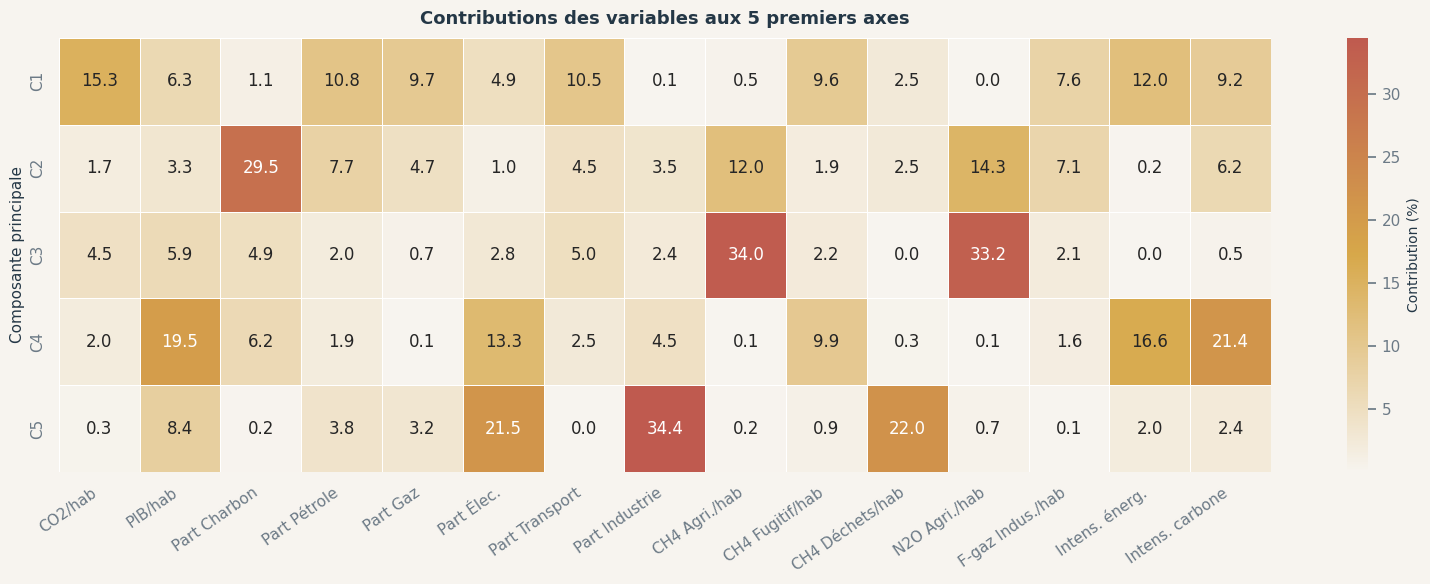

In [31]:
ctr_matrix = np.array([eigvecs[:, k]**2 * 100 for k in range(n_axes)])

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(ctr_matrix, annot=True, fmt='.1f', cmap=EMISSIONS_CMAP,
            yticklabels=[f'C{k+1}' for k in range(n_axes)],
            xticklabels=acp_labels,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Contribution (%)'})
ax.set_title(f'Contributions des variables aux {n_axes} premiers axes',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Composante principale', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 7.7 Synthèse

| Axe    | % var. | Ce qu'il capte                                          |
| ------ | ------ | ------------------------------------------------------- |
| **C1** | ~32%   | Intensité fossile globale (CO2/hab, pétrole, transport) |
| **C2** | ~14%   | Charbon + émissions agricoles (CH4, N2O)                |
| **C3** | ~13%   | Dimension agricole pure (CH4 agri., N2O agri.)          |
| **C4** | ~9%    | Intensité carbone du PIB                                |
| **C5** | ~8%    | Structure industrielle                                  |

**Retour sur l'hypothèse de Phase 1 :** le PIB/hab n'est pas le premier facteur - c'est la dépendance globale aux fossiles qui domine. La part du charbon structure C2, pas C1. Et les émissions agricoles forment une dimension propre (C3), totalement indépendante du CO2 fossile.

**Variables redondantes :** Part Pétrole ≈ Part Transport (même direction sur C1).  
**Variables indépendantes :** CH4/N2O Agriculture apportent une info orthogonale au reste.

L'ACP confirme que 2 dimensions étaient insuffisantes : il faut 5 composantes pour capturer ~76% de la structure des émissions mondiales.


## 8. Régression linéaire multiple

### Objectif

On cherche à expliquer le **CO2 par habitant** à partir de nos variables intensives. En Phase 1, la régression simple sur le PIB/hab donnait $R^2 \approx 0.56$ - insuffisant. L'idée est d'intégrer les variables de mix énergétique et de GES non-CO2 pour voir si un modèle à $p > 2$ variables fait mieux.

### Rappel du modèle

$$y = X \hat{b} + \hat{\varepsilon}$$

L'estimateur des moindres carrés est :

$$\hat{b} = ({}^t\!X \, X)^{-1} \, {}^t\!X \, y$$

La variance des résidus :

$$\hat{\sigma}^2 = \frac{\|\hat{\varepsilon}\|^2}{n - p}$$

La matrice de variance-covariance de $\hat{b}$ :

$$\text{Var}(\hat{b}) = \hat{\sigma}^2 \, ({}^t\!X \, X)^{-1}$$

L'écart-type de chaque coefficient $\hat{b}_j$ se lit sur la diagonale :

$$\hat{\sigma}_{\hat{b}_j} = \hat{\sigma} \sqrt{[({}^t\!X \, X)^{-1}]_{jj}}$$


### 8.1 Corrélations bivariées avec la variable cible

Avant de construire un modèle multiple, on examine la corrélation de chaque variable explicative avec le CO2/hab pour identifier les meilleurs prédicteurs individuels.


In [32]:
y_var = 'co2_per_capita'

x_vars = [
    'gdp_per_capita',
    'part_charbon', 'part_petrole', 'part_gaz',
    'part_elec', 'part_transport', 'part_industrie',
    'ch4_agri_pc', 'ch4_fugit_pc', 'ch4_waste_pc',
    'n2o_agri_pc', 'fgaz_indus_pc',
    'intensite_energ',
]

x_labels = [
    'PIB/hab',
    'Part Charbon', 'Part Pétrole', 'Part Gaz',
    'Part Élec.', 'Part Transport', 'Part Industrie',
    'CH4 Agri./hab', 'CH4 Fugitif/hab', 'CH4 Déchets/hab',
    'N2O Agri./hab', 'F-gaz Indus./hab',
    'Intens. énerg.',
]

label_map = dict(zip(x_vars, x_labels))

corr_results = []
for xv in x_vars:
    r, pval = stats.pearsonr(df_acp[xv], df_acp[y_var])
    corr_results.append({'Variable': label_map[xv], 'r': r, 'R²': r**2, 'p-value': pval})

corr_df = pd.DataFrame(corr_results).sort_values('R²', ascending=False)
print(corr_df.to_string(index=False, float_format='{:.4f}'.format))

        Variable       r     R²  p-value
         PIB/hab  0.7455 0.5558   0.0000
F-gaz Indus./hab  0.6853 0.4697   0.0000
 CH4 Fugitif/hab  0.6275 0.3937   0.0000
        Part Gaz  0.5619 0.3157   0.0000
  Intens. énerg.  0.5428 0.2946   0.0000
    Part Pétrole -0.4638 0.2151   0.0000
  Part Transport -0.4305 0.1853   0.0000
      Part Élec.  0.3290 0.1083   0.0000
 CH4 Déchets/hab  0.3142 0.0987   0.0000
    Part Charbon  0.0790 0.0062   0.3146
   N2O Agri./hab  0.0747 0.0056   0.3417
  Part Industrie -0.0469 0.0022   0.5512
   CH4 Agri./hab -0.0234 0.0005   0.7660


Les p-values confirment la significativité des corrélations : les 9 premières variables ont des p-values quasi nulles, ce qui signifie que leur corrélation avec le CO2/hab n'est pas due au hasard. En revanche, les dernières ont des p-values > 0.05 $\Rightarrow$ leur lien linéaire avec le CO2/hab n'est pas statistiquement significatif. Cela ne veut pas dire qu'elles sont inutiles, mais qu'elles n'expliquent pas le CO2/hab de manière isolée en dimension 2.


### 8.2 Nuages de points bivariés

On visualise chaque variable explicative contre le CO2/hab avec la droite de régression simple et le $R^2$.


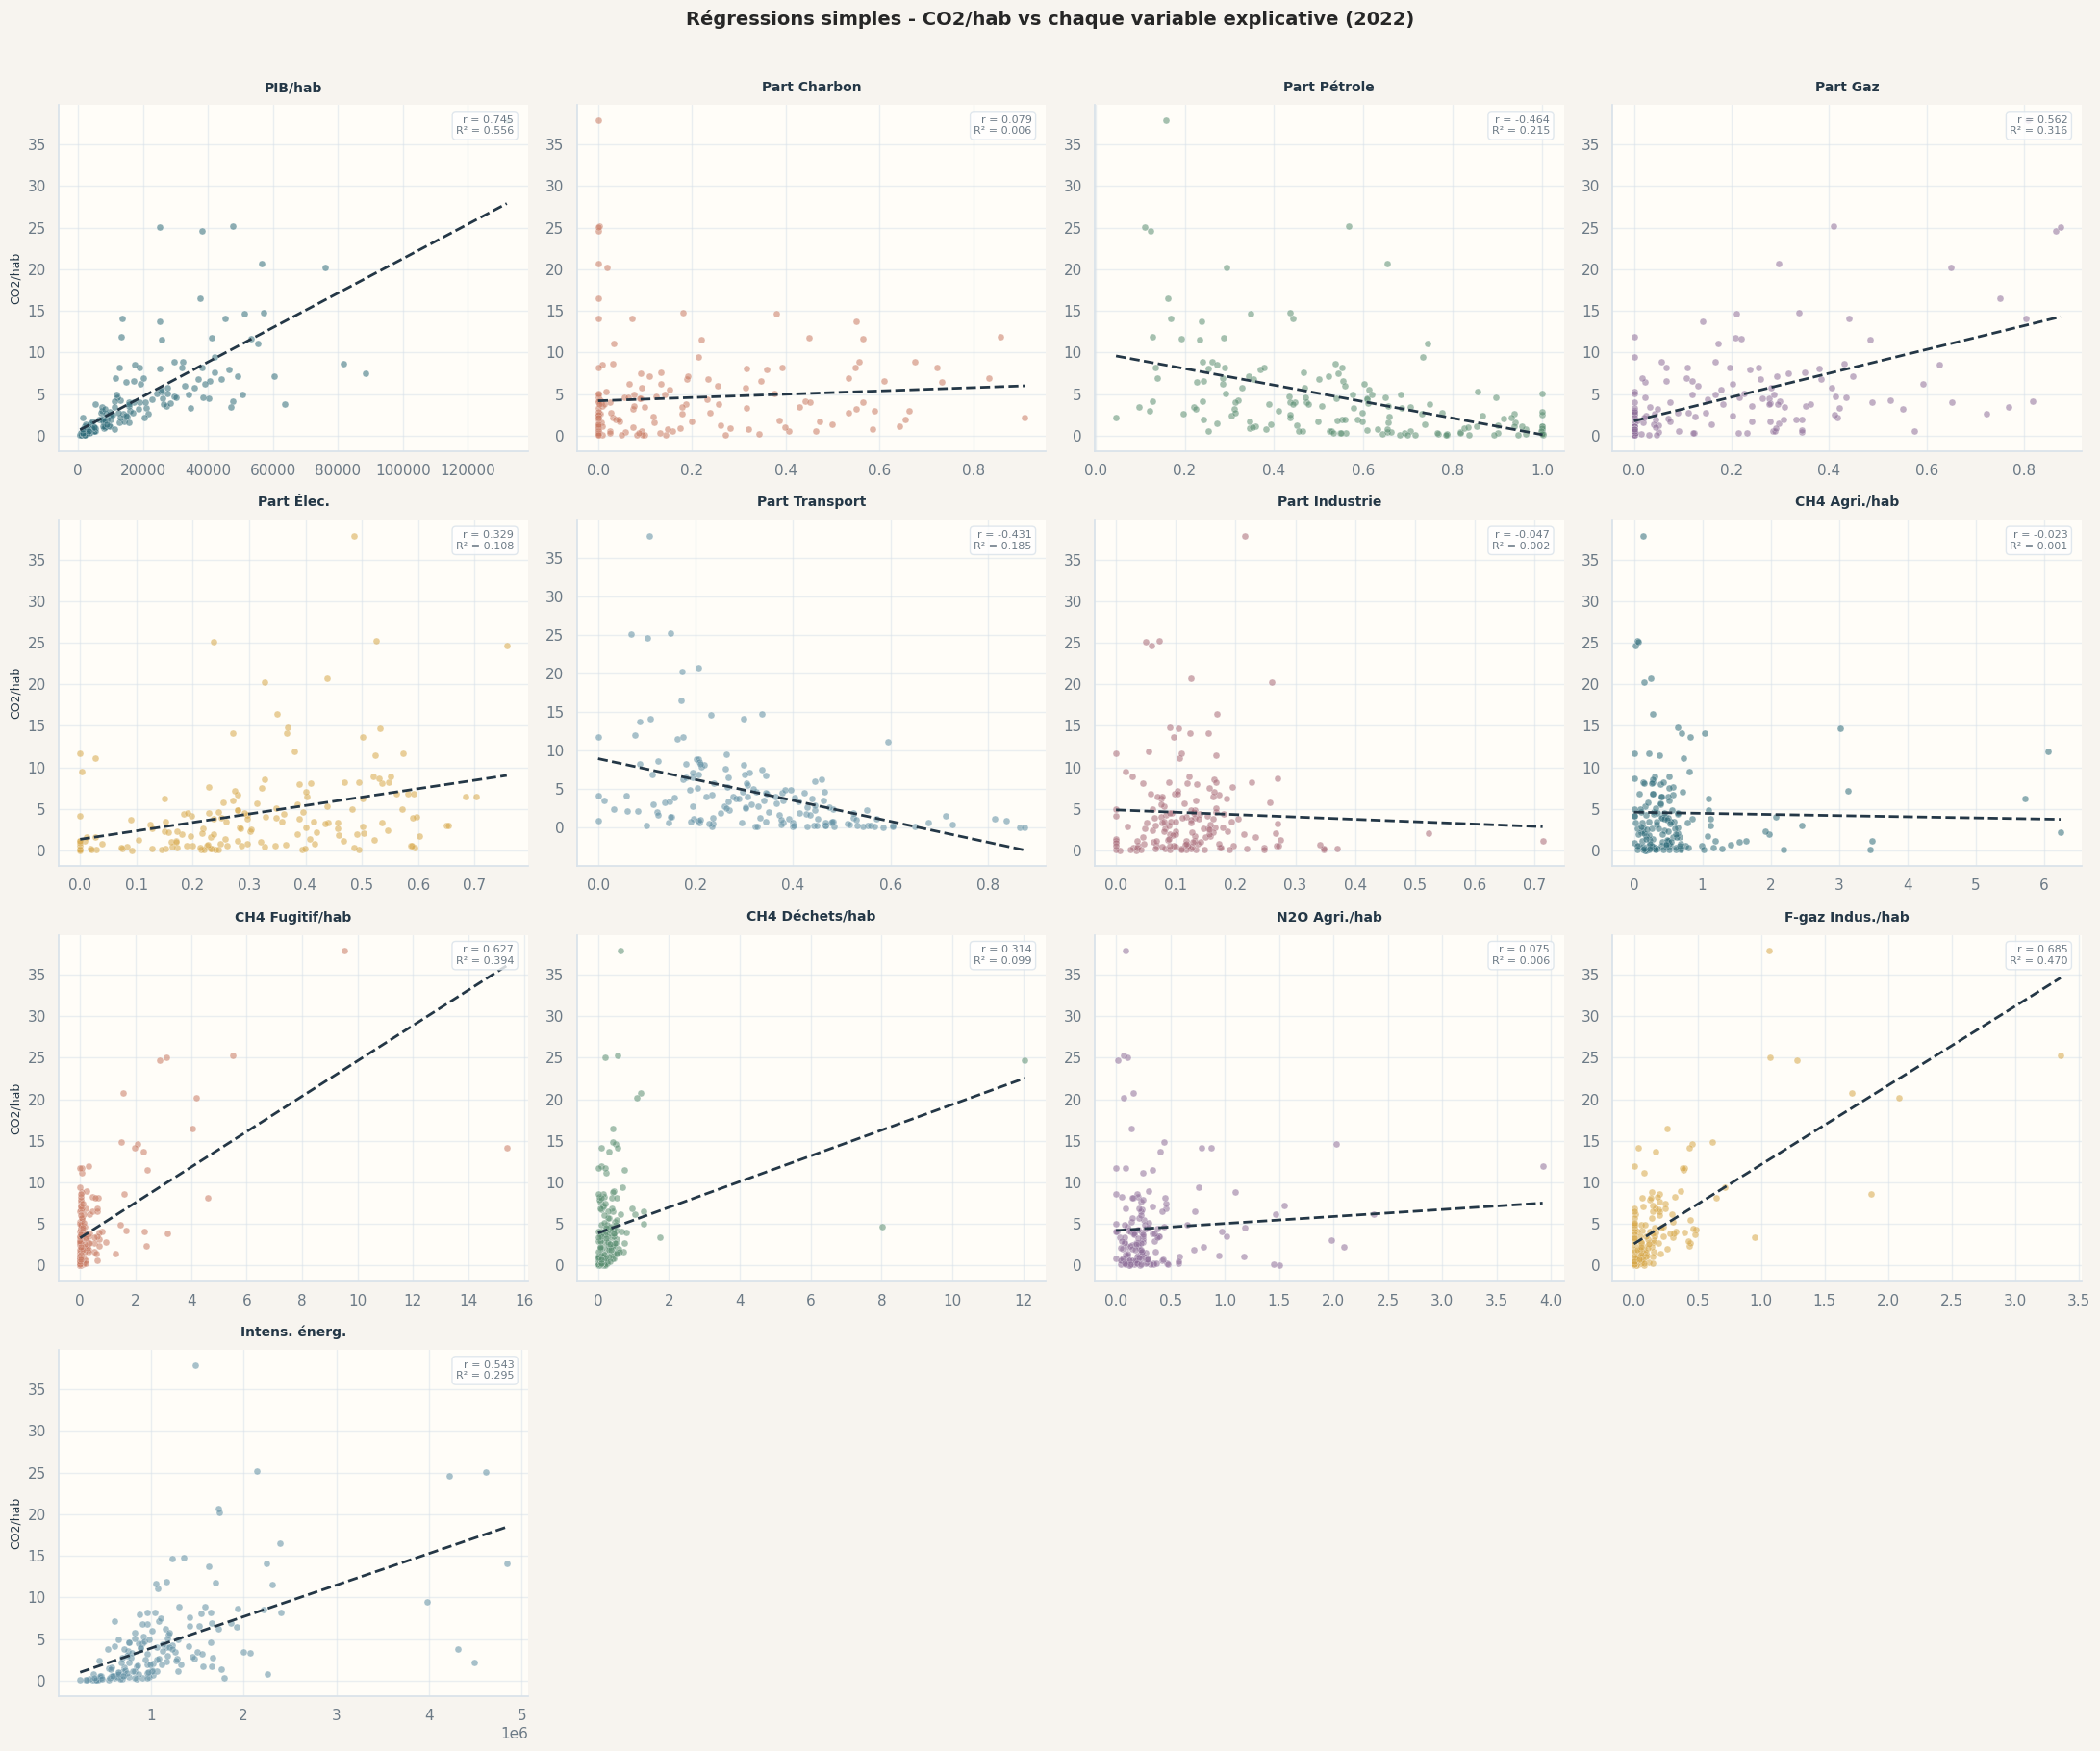

In [33]:
ncols = 4
nrows = (len(x_vars) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4.5))
axes = axes.flatten()

colors = SERIES_COLORS * 2  # assez pour couvrir 13 variables

for i, (xv, color) in enumerate(zip(x_vars, colors)):
    ax = axes[i]
    x = df_acp[xv].values
    y = df_acp[y_var].values

    ax.scatter(x, y, alpha=0.55, s=25, color=color, edgecolors='white', linewidth=0.3)

    mask = np.isfinite(x) & np.isfinite(y)
    z = np.polyfit(x[mask], y[mask], 1)
    xl = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), '--', color=PALETTE['ink'], linewidth=2)

    r, pval = stats.pearsonr(x, y)
    ax.set_title(f'{x_labels[i]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('CO2/hab' if i % ncols == 0 else '', fontsize=9)
    ax.annotate(f'r = {r:.3f}\nR² = {r**2:.3f}',
                xy=(0.97, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8, color=PALETTE['muted'],
                bbox=style_note_box(alpha=0.8))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Régressions simples - CO2/hab vs chaque variable explicative ({latest_year})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Interprétation des régressions simples

Les nuages de points montrent que la plupart des régressions simples s'ajustent mal : les points sont très dispersés autour de la droite ou bien très regroupés autour de l'origine, avec des $R^2$ souvent inférieurs à 0,30. Même le PIB/hab (meilleur prédicteur, $R^2$ ≈ 0.56) laisse près de la moitié de la variance inexpliquée.

Pour les variables comme Part Charbon, Part Industrie ou CH4 Agri./hab, la droite de régression est quasi horizontale $\Rightarrow$ elle n'explique rien. Cela confirme qu'aucune variable seule ne suffit à prédire le CO2/hab, et justifie le recours à la régression multiple en dimension N > 2.


### 8.3 Sélection du meilleur sous-ensemble de variables

Le $R^2$ classique a un défaut : il augmente **mécaniquement** à chaque variable ajoutée, même si elle n'apporte rien. Le $R^2$ ajusté corrige ce biais en pénalisant le nombre de variables $p$ :

$$R^2_{\text{adj}} = 1 - \frac{n - 1}{n - p - 1}(1 - R^2)$$

Le terme $\frac{n-1}{n-p-1}$ grossit avec $p$ : si une variable ajoutée n'améliore pas assez le $R^2$, le $R^2$ ajusté **baisse**. Cela permet de détecter le moment où empiler des variables ne sert plus à rien.

On teste toutes les combinaisons de 2 à 7 variables et on retient celle qui maximise ce critère.

> _Source : [DataCamp - R² ajusté](https://www.datacamp.com/fr/tutorial/adjusted-r-squared)_


In [34]:
df_reg = df_acp[x_vars + [y_var]].dropna()
y = df_reg[y_var].values
n_obs = len(y)

best_models = []

for size in range(2, 8):
    best_r2_adj = -np.inf
    best_combo = None
    best_r2 = 0

    for combo in combinations(x_vars, size):
        X_mat = df_reg[list(combo)].values
        X_aug = np.column_stack([np.ones(n_obs), X_mat])
        b = np.linalg.lstsq(X_aug, y, rcond=None)[0]
        y_pred = X_aug @ b
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot
        r2_adj = 1 - (1 - r2) * (n_obs - 1) / (n_obs - size - 1)

        if r2_adj > best_r2_adj:
            best_r2_adj = r2_adj
            best_combo = combo
            best_r2 = r2

    labels = [label_map[v] for v in best_combo]
    best_models.append({
        'p': size,
        'R²': best_r2,
        'R² ajusté': best_r2_adj,
        'Variables': ', '.join(labels),
        'vars_raw': best_combo,
    })
    print(f'p={size}  R²={best_r2:.4f}  R²adj={best_r2_adj:.4f}  →  {", ".join(labels)}')

p=2  R²=0.7373  R²adj=0.7340  →  PIB/hab, CH4 Fugitif/hab
p=3  R²=0.7943  R²adj=0.7904  →  PIB/hab, CH4 Fugitif/hab, F-gaz Indus./hab
p=4  R²=0.8232  R²adj=0.8188  →  PIB/hab, CH4 Fugitif/hab, F-gaz Indus./hab, Intens. énerg.
p=5  R²=0.8432  R²adj=0.8382  →  PIB/hab, Part Charbon, CH4 Fugitif/hab, CH4 Déchets/hab, F-gaz Indus./hab
p=6  R²=0.8515  R²adj=0.8458  →  PIB/hab, Part Charbon, CH4 Fugitif/hab, CH4 Déchets/hab, F-gaz Indus./hab, Intens. énerg.
p=7  R²=0.8586  R²adj=0.8522  →  PIB/hab, Part Charbon, Part Gaz, Part Industrie, CH4 Fugitif/hab, CH4 Déchets/hab, F-gaz Indus./hab


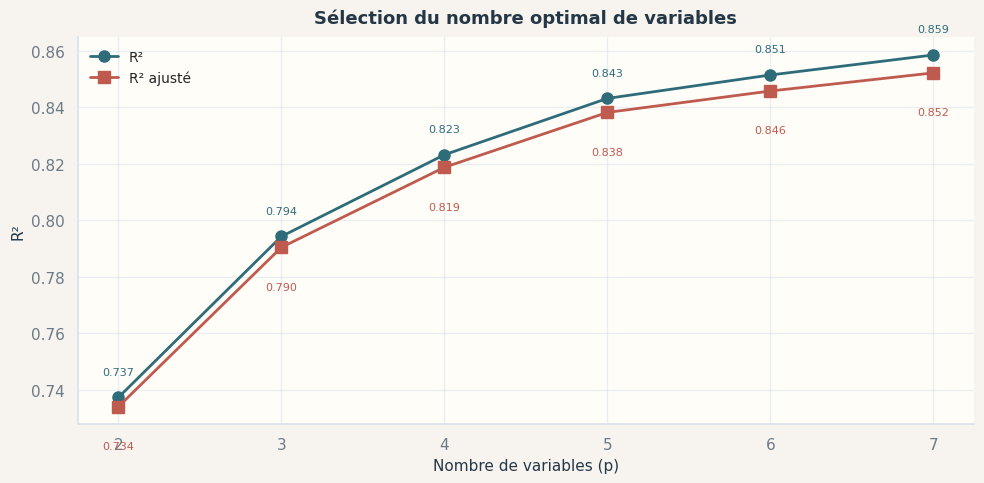

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

ps = [m['p'] for m in best_models]
r2s = [m['R²'] for m in best_models]
r2_adjs = [m['R² ajusté'] for m in best_models]

ax.plot(ps, r2s, '-o', color=PALETTE['primary'], linewidth=2, markersize=8, label='R²')
ax.plot(ps, r2_adjs, '-s', color=PALETTE['danger'], linewidth=2, markersize=8, label='R² ajusté')

for p_val, r2, r2a in zip(ps, r2s, r2_adjs):
    ax.text(p_val, r2 + 0.008, f'{r2:.3f}', ha='center', fontsize=8, color=PALETTE['primary'])
    ax.text(p_val, r2a - 0.015, f'{r2a:.3f}', ha='center', fontsize=8, color=PALETTE['danger'])

ax.set_xlabel('Nombre de variables (p)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Sélection du nombre optimal de variables', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Choix du modèle

Le $R^2$ ajusté progresse fortement jusqu'à **p = 5-6 variables**, puis stagne. On retient le modèle à **6 variables** ($R^2_{\text{adj}} \approx 0.85$).


### 8.4 Modèle retenu - Estimation et inférence

On estime le vecteur des coefficients :

$$\hat{m} = ({}^t\!X \, X)^{-1} \, {}^t\!X \, y = \begin{pmatrix} \hat{a} \\ \hat{b}_1 \\ \vdots \\ \hat{b}_p \end{pmatrix}$$

La matrice de variance-covariance de $\hat{m}$ est :

$$\text{Var}(\hat{m}) = \hat{\sigma}^2 \, ({}^t\!X \, X)^{-1}$$

C'est une matrice $p \times p$ dont l'élément diagonal $[\text{Var}(\hat{m})]_{jj}$ donne la variance de $\hat{b}_j$. L'écart-type de chaque coefficient se lit donc :

$$\hat{\sigma}_{\hat{b}_j} = \hat{\sigma} \sqrt{[({}^t\!X \, X)^{-1}]_{jj}}$$


In [36]:
# modèle retenu (6 variables)
x_final = list(best_models[4]['vars_raw'])  # p=6
x_final_labels = [label_map[v] for v in x_final]

X_raw = df_reg[x_final].values
n, p_vars = X_raw.shape
X = np.column_stack([np.ones(n), X_raw])

# estimation OLS : ^b = (tX X)^-1 tX y
tXX_inv = np.linalg.inv(X.T @ X)
b_hat = tXX_inv @ X.T @ y

y_hat = X @ b_hat
eps_hat = y - y_hat

# variance des résidus : sigma² = ||eps||² / (n - p)
ss_res = np.sum(eps_hat**2)
ss_tot = np.sum((y - y.mean())**2)
ss_reg = ss_tot - ss_res
sigma2 = ss_res / (n - p_vars - 1)
sigma = np.sqrt(sigma2)

# R²
r2 = 1 - ss_res / ss_tot
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p_vars - 1)

# Var(^b) = sigma² * (tX X)^-1
var_b = sigma2 * tXX_inv
se_b = np.sqrt(np.diag(var_b))

# t de Student : t_j = ^b_j / sigma_^b_j
t_stats = b_hat / se_b
t_pvals = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p_vars - 1))

# F global
f_stat = (ss_reg / p_vars) / (ss_res / (n - p_vars - 1))
f_pval = 1 - stats.f.cdf(f_stat, p_vars, n - p_vars - 1)

print(f'=== Modèle retenu : {p_vars} variables ===')
print(f'R²        = {r2:.4f}')
print(f'R² ajusté = {r2_adj:.4f}')
print(f'σ̂²        = {sigma2:.4f}')
print(f'σ̂         = {sigma:.4f}')
print(f'F({p_vars}, {n-p_vars-1})  = {f_stat:.2f},  p = {f_pval:.2e}')
print()

names = ['(constante)'] + x_final_labels
coef_rows = []
for i, name in enumerate(names):
    sig = '***' if t_pvals[i] < 0.001 else '**' if t_pvals[i] < 0.01 else '*' if t_pvals[i] < 0.05 else ''
    coef_rows.append({
        'Variable': name,
        'b̂': b_hat[i],
        'σ̂(b̂)': se_b[i],
        't': t_stats[i],
        'p-value': t_pvals[i],
        'signif.': sig,
    })

coef_df = pd.DataFrame(coef_rows)
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

=== Modèle retenu : 6 variables ===
R²        = 0.8515
R² ajusté = 0.8458
σ̂²        = 4.7870
σ̂         = 2.1879
F(6, 157)  = 150.00,  p = 1.11e-16

        Variable      b̂  σ̂(b̂)       t  p-value signif.
     (constante) -1.2023  0.3613 -3.3282   0.0011      **
         PIB/hab  0.0001  0.0000 13.1864   0.0000     ***
    Part Charbon  3.4562  0.8224  4.2025   0.0000     ***
 CH4 Fugitif/hab  1.1059  0.1351  8.1869   0.0000     ***
 CH4 Déchets/hab  0.6670  0.1639  4.0693   0.0001     ***
F-gaz Indus./hab  3.4361  0.5441  6.3154   0.0000     ***
  Intens. énerg.  0.0000  0.0000  2.9615   0.0035      **


#### Interprétation des coefficients

Tous les coefficients sont **significatifs** (p < 0.01). Le modèle à 6 variables explique **~85%** de la variance du CO2/hab soit un gain de ~30% par rapport au PIB/hab seul. La **combinaison** des déterminants est bien plus puissante que n'importe quel facteur isolé !


### 8.5 Comparaison simple vs multiple - Nuages observé vs prédit


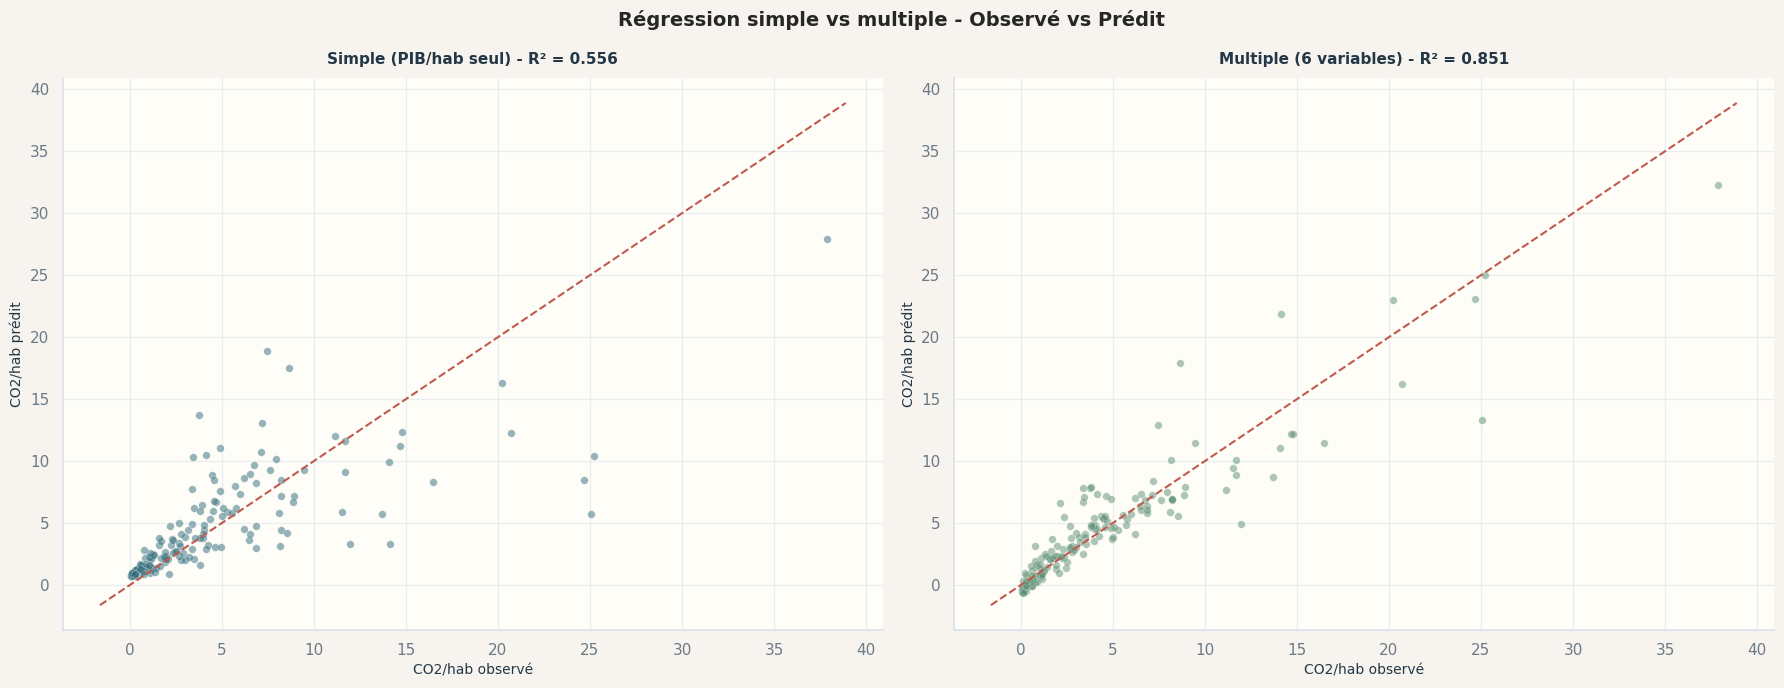

Gain de R² : 0.556 → 0.851 (+29.6 %)


In [37]:
# régression simple PIB/hab seul
x_simple = df_reg['gdp_per_capita'].values
X_s = np.column_stack([np.ones(n_obs), x_simple])
b_simple = np.linalg.lstsq(X_s, y, rcond=None)[0]
y_hat_s = X_s @ b_simple
r2_simple = 1 - np.sum((y - y_hat_s)**2) / ss_tot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Régression simple vs multiple - Observé vs Prédit', fontsize=14, fontweight='bold')

lims = [min(y.min(), y_hat.min(), y_hat_s.min()) - 1,
        max(y.max(), y_hat.max(), y_hat_s.max()) + 1]

# simple
ax1.scatter(y, y_hat_s, alpha=0.5, s=30, color=PALETTE['primary'], edgecolors='white', linewidth=0.3)
ax1.plot(lims, lims, '--', color=PALETTE['danger'], linewidth=1.5)
ax1.set_xlabel('CO2/hab observé', fontsize=10)
ax1.set_ylabel('CO2/hab prédit', fontsize=10)
ax1.set_title(f'Simple (PIB/hab seul) - R² = {r2_simple:.3f}', fontsize=11, fontweight='bold')

# multiple
ax2.scatter(y, y_hat, alpha=0.5, s=30, color=PALETTE['success'], edgecolors='white', linewidth=0.3)
ax2.plot(lims, lims, '--', color=PALETTE['danger'], linewidth=1.5)
ax2.set_xlabel('CO2/hab observé', fontsize=10)
ax2.set_ylabel('CO2/hab prédit', fontsize=10)
ax2.set_title(f'Multiple ({p_vars} variables) - R² = {r2:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Gain de R² : {r2_simple:.3f} → {r2:.3f} (+{(r2 - r2_simple)*100:.1f} %)')

Le passage de la régression simple à la régression multiple améliore nettement la qualité de prédiction. Visuellement, les points se resserrent autour de la diagonale rouge (prédiction parfaite) : à gauche, le nuage est très dispersé avec de nombreux pays mal prédits ; à droite, les points collent beaucoup mieux à la droite y = x. Le modèle multiple explique 85% de la variance du CO2/hab, contre 56% avec le PIB/hab seul $\rightarrow$ les 6 variables combinées captent donc une information que le PIB/hab seul ne pouvait pas fournir.


### 8.6 Diagnostic des résidus


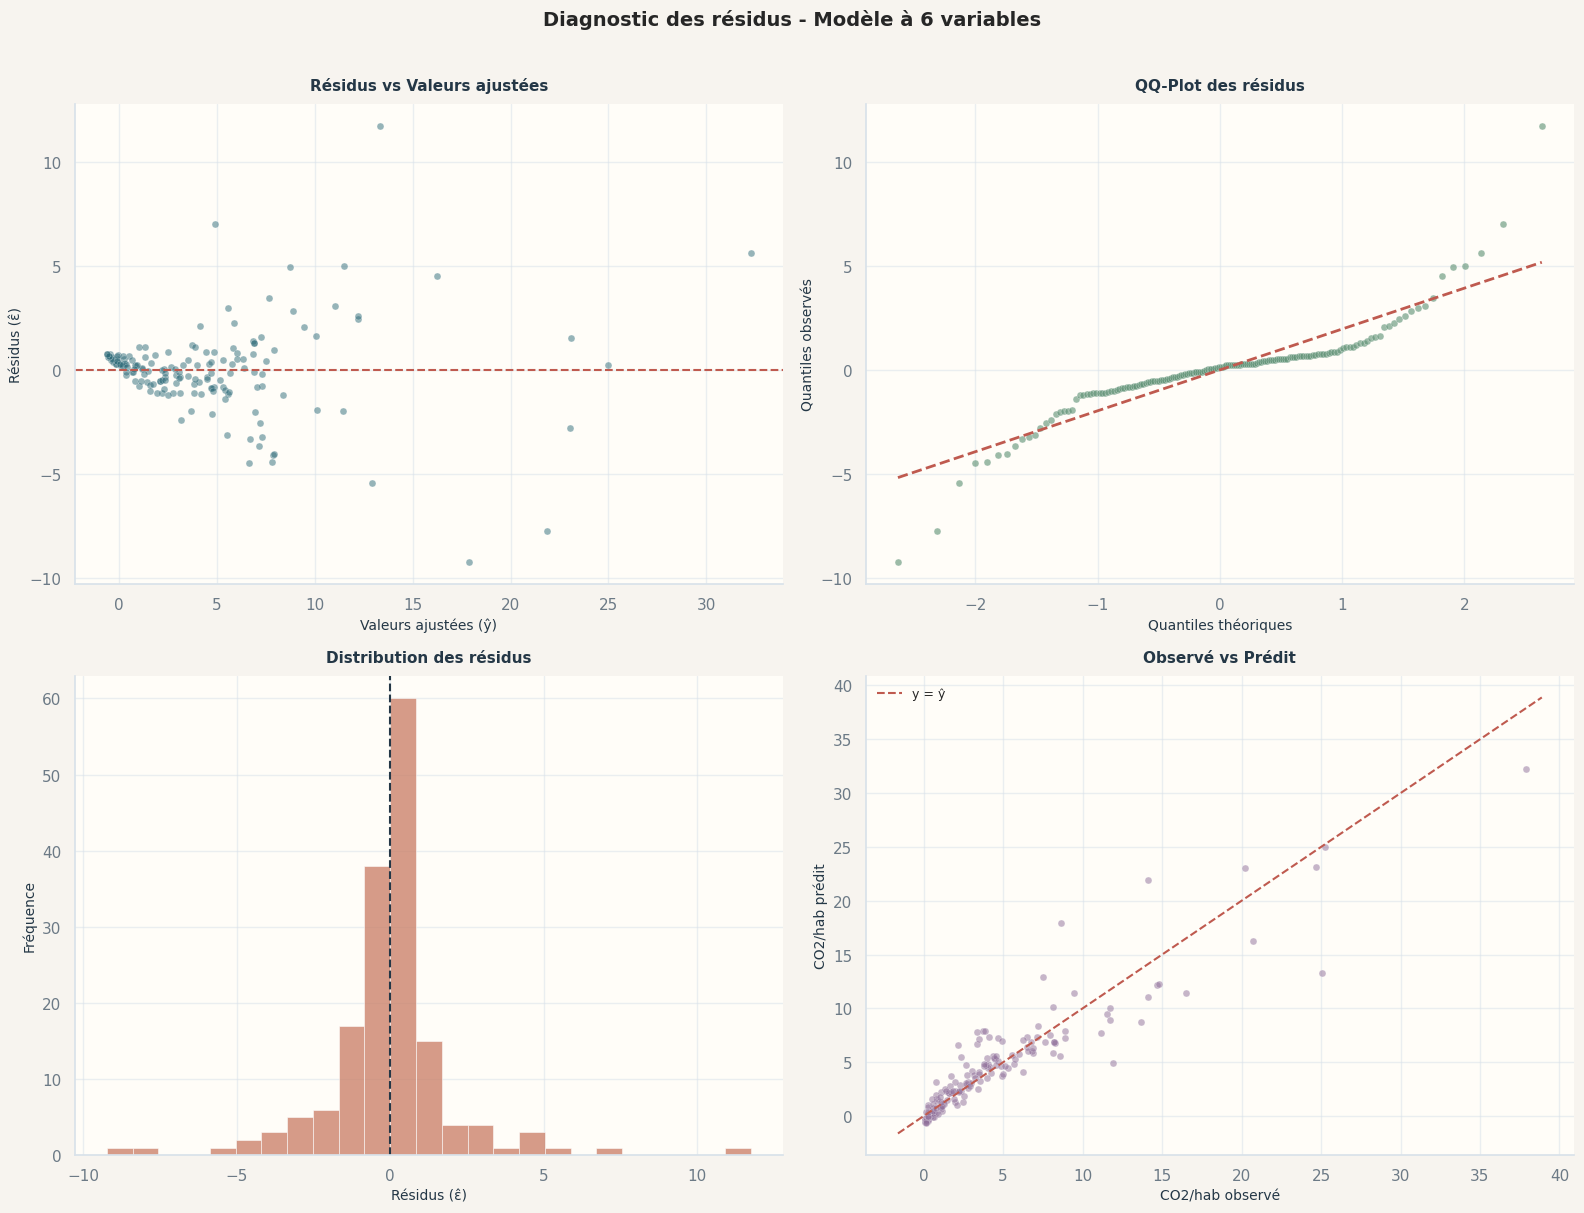

Shapiro-Wilk : W = 0.8371, p = 0.0000
Durbin-Watson : d = 2.0685


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Résidus vs valeurs ajustées
ax = axes[0, 0]
ax.scatter(y_hat, eps_hat, alpha=0.5, s=25, color=PALETTE['primary'], edgecolors='white', linewidth=0.3)
ax.axhline(0, color=PALETTE['danger'], linestyle='--', linewidth=1.5)
ax.set_xlabel('Valeurs ajustées (ŷ)', fontsize=10)
ax.set_ylabel('Résidus (ε̂)', fontsize=10)
ax.set_title('Résidus vs Valeurs ajustées', fontsize=11, fontweight='bold')

# 2. QQ-plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, _) = stats.probplot(eps_hat, dist='norm')
ax.scatter(osm, osr, alpha=0.6, s=25, color=PALETTE['success'], edgecolors='white', linewidth=0.3)
ax.plot(osm, slope * np.array(osm) + intercept, '--', color=PALETTE['danger'], linewidth=2)
ax.set_xlabel('Quantiles théoriques', fontsize=10)
ax.set_ylabel('Quantiles observés', fontsize=10)
ax.set_title('QQ-Plot des résidus', fontsize=11, fontweight='bold')

# 3. Histogramme des résidus
ax = axes[1, 0]
ax.hist(eps_hat, bins=25, color=PALETTE['secondary'], alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=PALETTE['ink'], linestyle='--', linewidth=1.5)
ax.set_xlabel('Résidus (ε̂)', fontsize=10)
ax.set_ylabel('Fréquence', fontsize=10)
ax.set_title('Distribution des résidus', fontsize=11, fontweight='bold')

# 4. Observé vs Prédit
ax = axes[1, 1]
ax.scatter(y, y_hat, alpha=0.5, s=25, color=PALETTE['cluster_4'], edgecolors='white', linewidth=0.3)
ax.plot(lims, lims, '--', color=PALETTE['danger'], linewidth=1.5, label='y = ŷ')
ax.set_xlabel('CO2/hab observé', fontsize=10)
ax.set_ylabel('CO2/hab prédit', fontsize=10)
ax.set_title('Observé vs Prédit', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

shap_stat, shap_p = stats.shapiro(eps_hat)
dw = np.sum(np.diff(eps_hat)**2) / ss_res

fig.suptitle(f'Diagnostic des résidus - Modèle à {p_vars} variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Shapiro-Wilk : W = {shap_stat:.4f}, p = {shap_p:.4f}')
print(f'Durbin-Watson : d = {dw:.4f}')

#### Interprétation des diagnostics

- **Résidus vs ajustées** : pas de structure en cône ou courbe → linéarité et homoscédasticité OK
- **QQ-plot** : les queues s'écartent un peu → quelques pays extrêmes, mais le modèle reste robuste avec $n = 164$
- **Durbin-Watson** ≈ 2 : pas d'autocorrélation des résidus

Le test de Shapiro-Wilk rejette formellement la normalité ce qui est logique avec n = 164. De plus, le test est très sensible aux quelques pays extrêmes visibles dans les queues du QQ-plot. En pratique, le coeur de la distribution est bien centré sur zéro, l'histogramme est approximativement symétrique, et le Durbin-Watson ≈ 2 confirme l'indépendance des résidus. Le modèle respecte donc raisonnablement les hypothèses de la régression linéaire.


### 8.7 Tube de confiance à 95%

Quand le modèle prédit $\hat{y}_i$ pour un pays, cette prédiction est incertaine. On distingue deux types d'incertitude :

**Intervalle de confiance (IC)** : où se situe la _vraie moyenne_ au risque de 5% ?

$$\bar{\hat{y}}_i \pm t_{\alpha/2, \, n-p} \cdot \hat{\sigma} \sqrt{x_i^{\,t} ({}^t\!X \, X)^{-1} x_i}$$

Le terme $x_i^{\,t} ({}^t\!X \, X)^{-1} x_i$ mesure à quel point le pays $i$ est "loin" du centre du nuage - plus il est atypique, plus l'incertitude est grande.

**Intervalle de prédiction (IP)** : où se situe la _prédiction individuelle_ au risque de 5% ?
$$\hat{y}_i \pm t_{\alpha/2, \, n-p} \cdot \hat{\sigma} \sqrt{1 + x_i^{\,t} ({}^t\!X \, X)^{-1} x_i}$$

Le **+1** sous la racine est la clé. Dans l'IC, on n'a que le terme $x_i^t (X^tX)^{-1} x_i$ qui est l'incertitude sur la **moyenne estimée**, autrement dit : est-ce que la droite passe au bon endroit pour ce $x_i$ ?

Mais quand on prédit un **pays réel**, il faut ajouter son résidu individuel $\varepsilon_i$. Ce résidu a une variance de $\hat{\sigma}^2$, indépendante de l'incertitude sur le modèle. La variance totale devient donc :

$$\text{Var}(\text{prédiction}) = \underbrace{\hat{\sigma}^2 \cdot x_i^t(X^tX)^{-1}x_i}_{\text{incertitude sur la moyenne}} + \underbrace{\hat{\sigma}^2}_{\text{variabilité individuelle}}$$

En factorisant par $\hat{\sigma}^2$ :

$$= \hat{\sigma}^2 \left( x_i^t(X^tX)^{-1}x_i + 1 \right)$$

Conséquence : même avec un modèle parfaitement estimé (incertitude sur les coefficients $\rightarrow$ 0), l'IP ne descend jamais en dessous de $\pm t \cdot \hat{\sigma}$. C'est un **plancher incompressible** lié à la dispersion naturelle des pays autour de la tendance.

L'IP est donc toujours plus large que l'IC. C'est le même esprit que l'intervalle de fluctuation vu pour les proportions, mais appliqué ici à une variable continue.


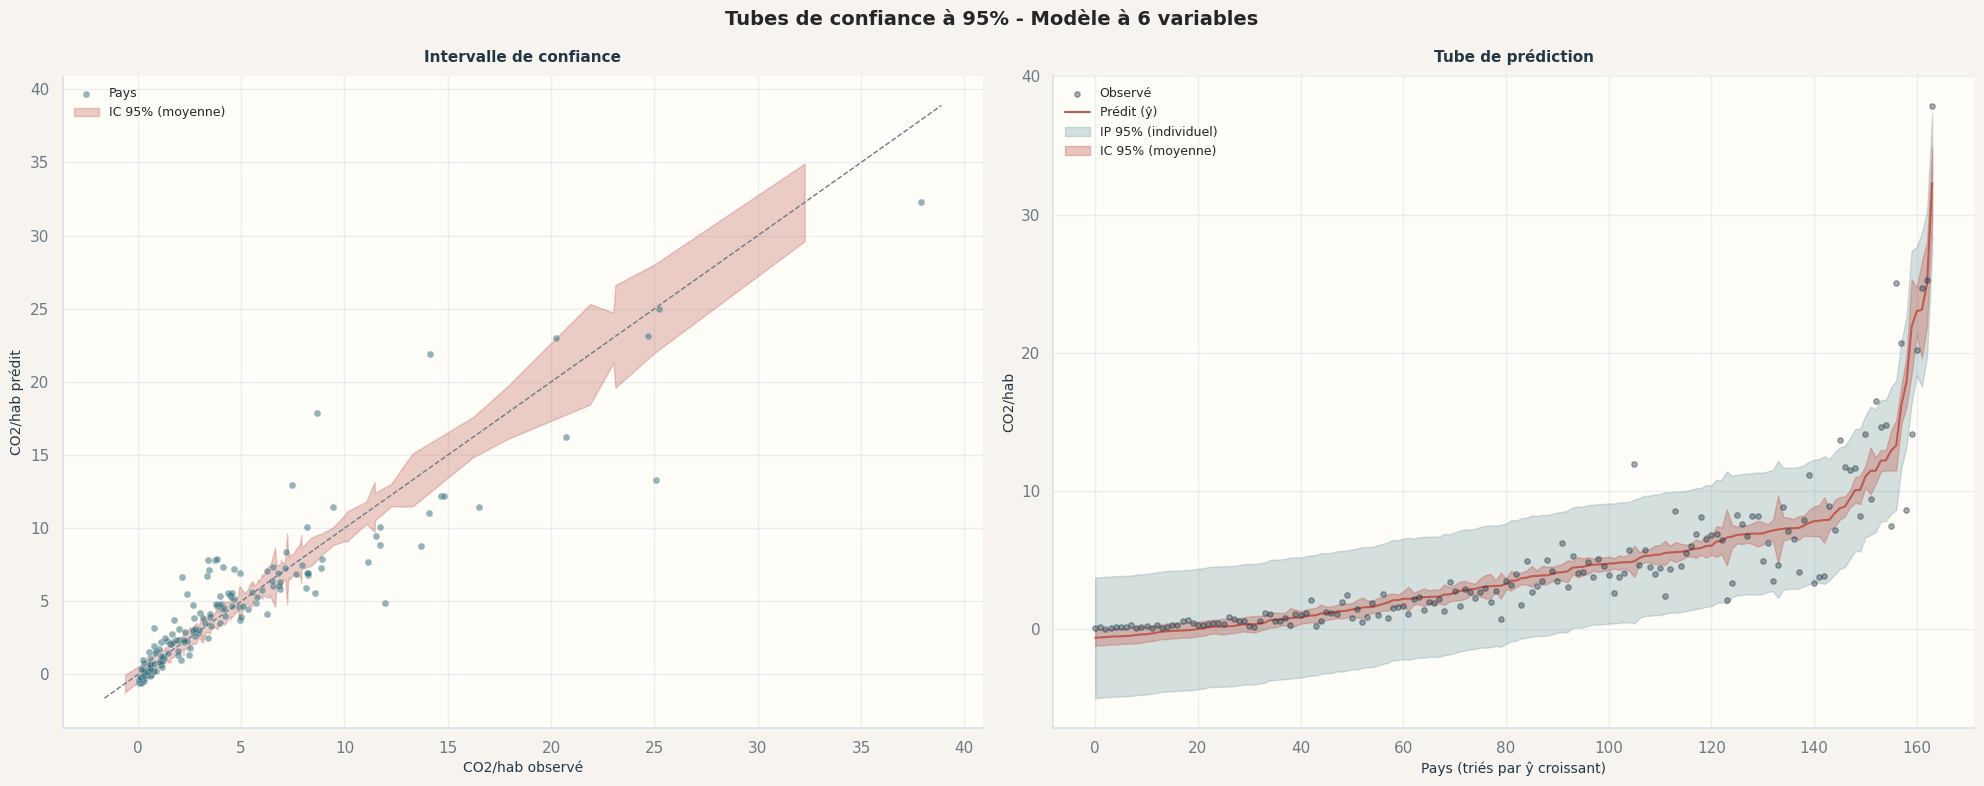

Couverture IC 95% : 39.6% des pays
Couverture IP 95% : 95.1% des pays


In [39]:
# intervalles de confiance et de prédiction
t_crit = stats.t.ppf(0.975, n - p_vars - 1)

# variance de chaque ŷ_i : sigma² * x_i^t (tX X)^-1 x_i
var_yhat = np.array([sigma2 * X[i] @ tXX_inv @ X[i] for i in range(n)])
se_yhat = np.sqrt(var_yhat)

# intervalle de confiance (sur la moyenne)
ci_low = y_hat - t_crit * se_yhat
ci_high = y_hat + t_crit * se_yhat

# intervalle de prédiction (pour un individu)
se_pred = np.sqrt(sigma2 + var_yhat)
pi_low = y_hat - t_crit * se_pred
pi_high = y_hat + t_crit * se_pred

# tri par ŷ pour un affichage propre
order = np.argsort(y_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Tubes de confiance à 95% - Modèle à {p_vars} variables',
             fontsize=14, fontweight='bold')

# -- graphique 1 : observé vs prédit + IC --
ax1.scatter(y[order], y_hat[order], alpha=0.5, s=25, color=PALETTE['primary'],
            edgecolors='white', linewidth=0.3, zorder=3, label='Pays')
ax1.fill_between(y_hat[order], ci_low[order], ci_high[order],
                 alpha=0.3, color=PALETTE['danger'], label='IC 95% (moyenne)')
ax1.plot(lims, lims, '--', color=PALETTE['muted'], linewidth=1)
ax1.set_xlabel('CO2/hab observé', fontsize=10)
ax1.set_ylabel('CO2/hab prédit', fontsize=10)
ax1.set_title('Intervalle de confiance', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# -- graphique 2 : ŷ trié + tube de prédiction --
idx = np.arange(n)
ax2.scatter(idx, y[order], alpha=0.4, s=15, color=PALETTE['ink'], label='Observé', zorder=3)
ax2.plot(idx, y_hat[order], color=PALETTE['danger'], linewidth=1.5, label='Prédit (ŷ)')
ax2.fill_between(idx, pi_low[order], pi_high[order],
                 alpha=0.2, color=PALETTE['primary'], label='IP 95% (individuel)')
ax2.fill_between(idx, ci_low[order], ci_high[order],
                 alpha=0.35, color=PALETTE['danger'], label='IC 95% (moyenne)')
ax2.set_xlabel('Pays (triés par ŷ croissant)', fontsize=10)
ax2.set_ylabel('CO2/hab', fontsize=10)
ax2.set_title('Tube de prédiction', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# stats de couverture
in_ci = np.mean((y >= ci_low) & (y <= ci_high)) * 100
in_pi = np.mean((y >= pi_low) & (y <= pi_high)) * 100
print(f'Couverture IC 95% : {in_ci:.1f}% des pays')
print(f'Couverture IP 95% : {in_pi:.1f}% des pays')

#### Interprétation

- Le **tube de confiance** (rouge) est étroit : le modèle est assez précis sur l'estimation de la moyenne
- Le **tube de prédiction** (bleu) est plus large : la variabilité individuelle reste importante - certains pays s'écartent de leur profil prédit
- La couverture de l'IP est proche de 95% comme attendu $\Rightarrow$ le modèle est bien calibré


### Équation du modèle final

$$\hat{y} = \hat{a} + \hat{b}_1 x_1 + \hat{b}_2 x_2 + \hat{b}_3 x_3 + \hat{b}_4 x_4 + \hat{b}_5 x_5 + \hat{b}_6 x_6$$

avec :

- $\hat{y}$ : CO2 par habitant (t/hab)
- $x_1$ : PIB par habitant (USD/hab)
- $x_2$ : Part du charbon dans le CO2 total
- $x_3$ : CH4 fugitif par habitant (t CO2eq/hab)
- $x_4$ : CH4 déchets par habitant (t CO2eq/hab)
- $x_5$ : F-gaz industriels par habitant (t CO2eq/hab)
- $x_6$ : Intensité énergétique (TWh / Mrd$)


In [40]:
print(f'ŷ = {b_hat[0]:.4f}')
for i, name in enumerate(x_final_labels):
    sign = '+' if b_hat[i+1] >= 0 else '-'
    print(f'    {sign} {abs(b_hat[i+1]):.4f} × {name}')

ŷ = -1.2023
    + 0.0001 × PIB/hab
    + 3.4562 × Part Charbon
    + 1.1059 × CH4 Fugitif/hab
    + 0.6670 × CH4 Déchets/hab
    + 3.4361 × F-gaz Indus./hab
    + 0.0000 × Intens. énerg.


### 8.8 Synthèse de la régression

Le passage de la régression simple ($R^2 = 0.56$) à la régression multiple à 6 variables ($R^2 = 0.85$) fait passer le pouvoir explicatif de 56% à 85% de la variance du CO2/hab. Les variables retenues au-delà du PIB/hab :

- **Part du charbon** : dépendance au charbon → émissions plus élevées à PIB comparable
- **CH4 fugitif/hab** : proxy de l'activité extractive (fuites de méthane)
- **CH4 déchets/hab** : traitement des déchets
- **F-gaz industriels/hab** : marqueur d'industrialisation avancée
- **Intensité énergétique** : consommation d'énergie par unité de PIB

Le niveau de richesse seul est insuffisant $\rightarrow$ c'est la **structure énergétique et industrielle** qui fait la différence entre pays à PIB/hab comparable. C'est cohérent avec l'ACP où C1 (dépendance fossile) dominait devant le PIB/hab.


## 9. Classification en dimension N > 2

### Objectif

En Phase 1, la classification se limitait à 2 variables (log CO2/hab × log PIB/hab). On passe maintenant aux **15 variables intensives** utilisées dans l'ACP pour capturer la structure complète des profils d'émissions : mix fossile, GES non-CO2, intensités économiques.

On utilise les mêmes méthodes qu'en Phase 1 (CAH Ward + K-Means) mais sur les données standardisées en dimension 15.


### 9.1 Standardisation

Les variables sont centrées-réduites (même matrice $X$ que pour l'ACP) pour que chacune pèse le même poids dans le calcul des distances euclidiennes.


In [41]:
# standardisation et projections réutilisées
X_clust = X_std
Y_proj  = Y

print(f'Individus : {n} | Variables : {p}')

Individus : 164 | Variables : 15


### 9.2 CAH - Coude et dendrogramme

On applique la méthode de Ward et on cherche le nombre optimal de clusters via le coude des distances de fusion et le dendrogramme.


Nombre optimal de clusters (CAH) : 4


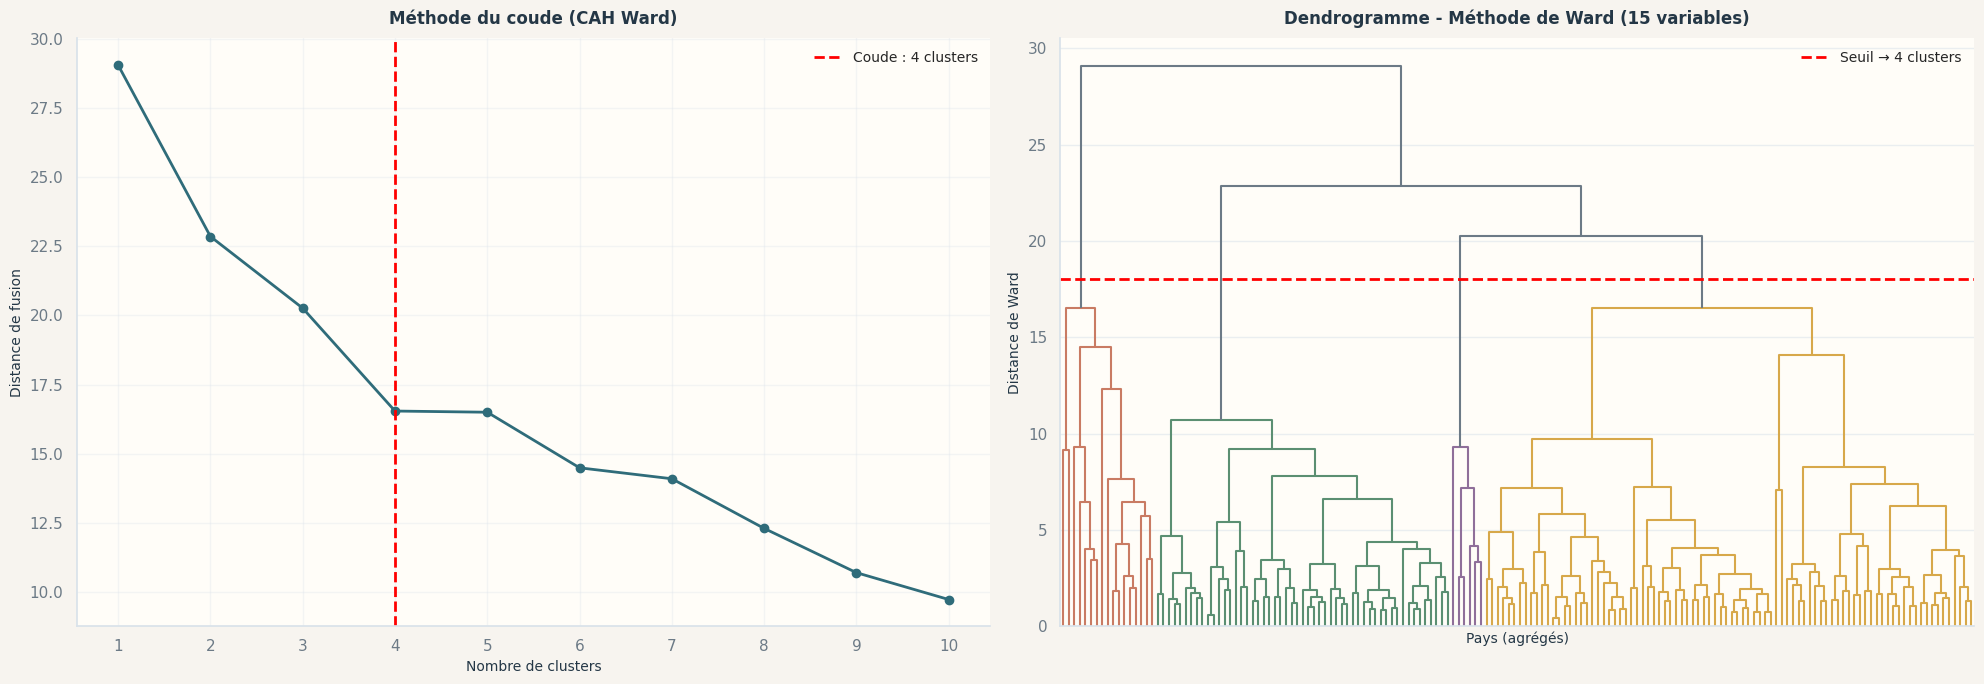

In [42]:
distance_matrix = pdist(X_clust, metric='euclidean')
Z = linkage(distance_matrix, method='ward')

# coude sur les dernières fusions
last = Z[-10:, 2]
last_rev = last[::-1]
idxs = np.arange(1, len(last) + 1)
knee_cah = KneeLocator(idxs, last_rev, curve='convex', direction='decreasing')
optimal_cah = knee_cah.knee
print(f'Nombre optimal de clusters (CAH) : {optimal_cah}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# coude
ax1.plot(idxs, last_rev, marker='o', color=PALETTE['primary'], linewidth=2)
ax1.axvline(optimal_cah, color='red', linestyle='--', linewidth=2,
            label=f'Coude : {optimal_cah} clusters')
ax1.set_title('Méthode du coude (CAH Ward)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Nombre de clusters', fontsize=10)
ax1.set_ylabel('Distance de fusion', fontsize=10)
ax1.set_xticks(idxs)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# dendrogramme
dendrogram(Z, no_labels=True, color_threshold=Z[-optimal_cah + 1, 2], ax=ax2,
           leaf_rotation=90, above_threshold_color=PALETTE['muted'])
ax2.axhline(y=18, color='red', linestyle='--', linewidth=2,
            label=f'Seuil → {optimal_cah} clusters')
ax2.set_title('Dendrogramme - Méthode de Ward (15 variables)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Pays (agrégés)', fontsize=10)
ax2.set_ylabel('Distance de Ward', fontsize=10)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Interprétation

Le coude se situe clairement à **K = 4** : la distance de fusion chute fortement entre 1 et 4 clusters, puis la courbe s'aplatit. Le dendrogramme confirme ce choix - le seuil en rouge coupe l'arbre en 4 branches bien distinctes, avec un saut de distance important entre le niveau 3 et 4 groupes.

On note que les deux petits clusters à droite du dendrogramme (pays pétroliers et agro-exportateurs) se séparent très tôt du reste, signe que ces profils sont les plus atypiques dans l'espace des 15 variables.


### 9.3 Visualisation CAH - Projection ACP


Dans notre cas, la classification est réalisée dans un espace de dimension élevée, ce qui ne permet pas une visualisation directe. Nous projetons donc les données sur les premières composantes principales issues de l’ACP précedente, afin d’obtenir une représentation en 2D et 3D.

Ce choix n’est pas arbitraire, car ces composantes maximisent la variance et capturent ainsi l’essentiel de l’information des données. Cela permet de visualiser les clusters de manière pertinente, même si cette projection reste une approximation de la structure réelle.

D’autres méthodes de réduction de dimension (comme t-SNE ou UMAP) existent et pourraient être utilisées, mais elles n’ont pas été abordées en cours ; nous avons donc choisi de ne pas les utiliser ici.

In [43]:
K_cah = optimal_cah
df_pca['cluster_cah'] = fcluster(Z, t=K_cah, criterion='maxclust') - 1


seed = 123456789
labels_df = (
    df_pca.groupby('cluster_cah', group_keys=False)
    .sample(n=2, random_state=seed, replace=True)
)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.7, 0.3],
    subplot_titles=('Projection ACP (C1 × C2) - Clusters CAH', 'Effectifs par cluster')
)

for k in sorted(df_pca['cluster_cah'].unique()):
    mask = df_pca['cluster_cah'] == k
    fig.add_trace(go.Scatter(
        x=Y_proj[mask, 0], y=Y_proj[mask, 1], mode='markers',
        name=f'Cluster {k}',
        marker=dict(color=COLORS_CAH[k], size=8, line=dict(width=0.5, color='white')),
        text=countries[mask],
        hovertemplate='<b>%{text}</b><br>C1: %{x:.2f}<br>C2: %{y:.2f}<extra></extra>',
    ), row=1, col=1)

# centroïdes
centroids_cah = df_pca.groupby('cluster_cah')[acp_vars].mean().values
centroids_cah_proj = np.array([X_std[df_pca['cluster_cah'] == k].mean(axis=0) for k in range(K_cah)]) @ eigvecs
for k in range(K_cah):
    fig.add_trace(go.Scatter(
        x=[centroids_cah_proj[k, 0]], y=[centroids_cah_proj[k, 1]], mode='markers',
        marker=dict(size=18, symbol='star', color=COLORS_CAH[k],
                    line=dict(width=1.5, color='black')),
        showlegend=False,
    ), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=14, symbol='star', color='black'),
    name='Centroïde',
), row=1, col=1)

for _, row in labels_df.iterrows():
    i = np.where(countries == row['country'])[0][0]
    fig.add_annotation(
        x=Y_proj[i, 0], y=Y_proj[i, 1], text=row['country'],
        showarrow=False, xanchor='left', yanchor='middle', xshift=5,
        font=dict(size=11, color=PALETTE['ink']),
        bgcolor=PALETTE['paper'], bordercolor='rgba(0,0,0,0)', borderpad=3,
    )

sizes_cah = df_pca['cluster_cah'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=[f'Cluster {k}' for k in sizes_cah.index], y=sizes_cah.values,
    marker_color=[COLORS_CAH[k] for k in sizes_cah.index],
    text=sizes_cah.values, textposition='outside', showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=f'CAH Ward (K={K_cah}) - Plan ACP ({latest_year})', height=600,
)
fig.update_xaxes(title_text=f'C1 ({contribs[0]*100:.1f}%)', row=1, col=1)
fig.update_yaxes(title_text=f'C2 ({contribs[1]*100:.1f}%)', row=1, col=1)
fig.update_yaxes(title_text='Nombre de pays', row=1, col=2)
fig.show()

La CAH identifie 4 groupes : un gros cluster central (88 pays), un cluster intermédiaire (53), et deux petits groupes atypiques - le cluster 0 (pays pétroliers, isolés à gauche sur C1) et le cluster 2 (pays agricoles, tirés vers le bas sur C2 par la Mongolie et l'Uruguay).


### 9.4 K-Means - Coude


Nombre optimal de clusters (K-Means) : 4


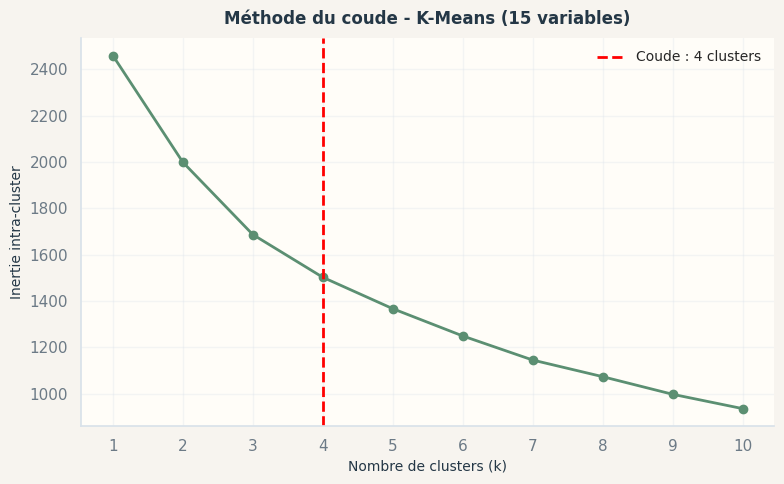

In [44]:
K_range = range(1, 11)
inertias = []

for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_tmp.fit(X_clust)
    inertias.append(km_tmp.inertia_)

knee_km = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_km = knee_km.knee
print(f'Nombre optimal de clusters (K-Means) : {optimal_km}')

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color=PALETTE['success'], linewidth=2)
plt.axvline(optimal_km, color='red', linestyle='--', linewidth=2,
            label=f'Coude : {optimal_km} clusters')
plt.title('Méthode du coude - K-Means (15 variables)', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de clusters (k)', fontsize=10)
plt.ylabel('Inertie intra-cluster', fontsize=10)
plt.xticks(K_range)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.5 Visualisation K-Means - Projection ACP


In [45]:
K = optimal_km
km = KMeans(n_clusters=K, random_state=42, n_init=20)
df_pca['cluster'] = km.fit_predict(X_clust)


centroids_proj = km.cluster_centers_ @ eigvecs

seed = 123456789
labels_df = (
    df_pca.groupby('cluster', group_keys=False)
    .sample(n=2, random_state=seed, replace=True)
)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.7, 0.3],
    subplot_titles=('Projection ACP (C1 × C2) - Clusters K-Means', 'Effectifs par cluster')
)

for k in range(K):
    mask = df_pca['cluster'] == k
    fig.add_trace(go.Scatter(
        x=Y_proj[mask, 0], y=Y_proj[mask, 1], mode='markers',
        name=f'Cluster {k}',
        marker=dict(color=CLUSTER_COLORS[k], size=8, line=dict(width=0.5, color='white')),
        text=countries[mask],
        hovertemplate='<b>%{text}</b><br>C1: %{x:.2f}<br>C2: %{y:.2f}<extra></extra>',
    ), row=1, col=1)

for k in range(K):
    fig.add_trace(go.Scatter(
        x=[centroids_proj[k, 0]], y=[centroids_proj[k, 1]], mode='markers',
        marker=dict(size=18, symbol='star', color=CLUSTER_COLORS[k],
                    line=dict(width=1.5, color='black')),
        showlegend=False,
    ), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=14, symbol='star', color='black'),
    name='Centroïde',
), row=1, col=1)

for _, row in labels_df.iterrows():
    i = np.where(countries == row['country'])[0][0]
    fig.add_annotation(
        x=Y_proj[i, 0], y=Y_proj[i, 1], text=row['country'],
        showarrow=False, xanchor='left', yanchor='middle', xshift=5,
        font=dict(size=11, color=PALETTE['ink']),
        bgcolor=PALETTE['paper'], bordercolor='rgba(0,0,0,0)', borderpad=3,
    )

sizes_km = df_pca['cluster'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=[f'Cluster {k}' for k in sizes_km.index], y=sizes_km.values,
    marker_color=[CLUSTER_COLORS[k] for k in sizes_km.index],
    text=sizes_km.values, textposition='outside', showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=f'K-Means (K={K}) - Plan ACP ({latest_year})', height=600,
)
fig.update_xaxes(title_text=f'C1 ({contribs[0]*100:.1f}%)', row=1, col=1)
fig.update_yaxes(title_text=f'C2 ({contribs[1]*100:.1f}%)', row=1, col=1)
fig.update_yaxes(title_text='Nombre de pays', row=1, col=2)
fig.show()

K-Means produit une partition plus équilibrée : deux gros clusters (72 et 74 pays) au centre, et deux petits groupes bien séparés - le cluster 2 (pays pétroliers/gaziers, à gauche sur C1) et le cluster 3 (pays agro-exportateurs, tirés vers le bas sur C2). Les centroïdes sont bien espacés, confirmant des profils distincts.


### 9.6 Comparaison - Silhouette


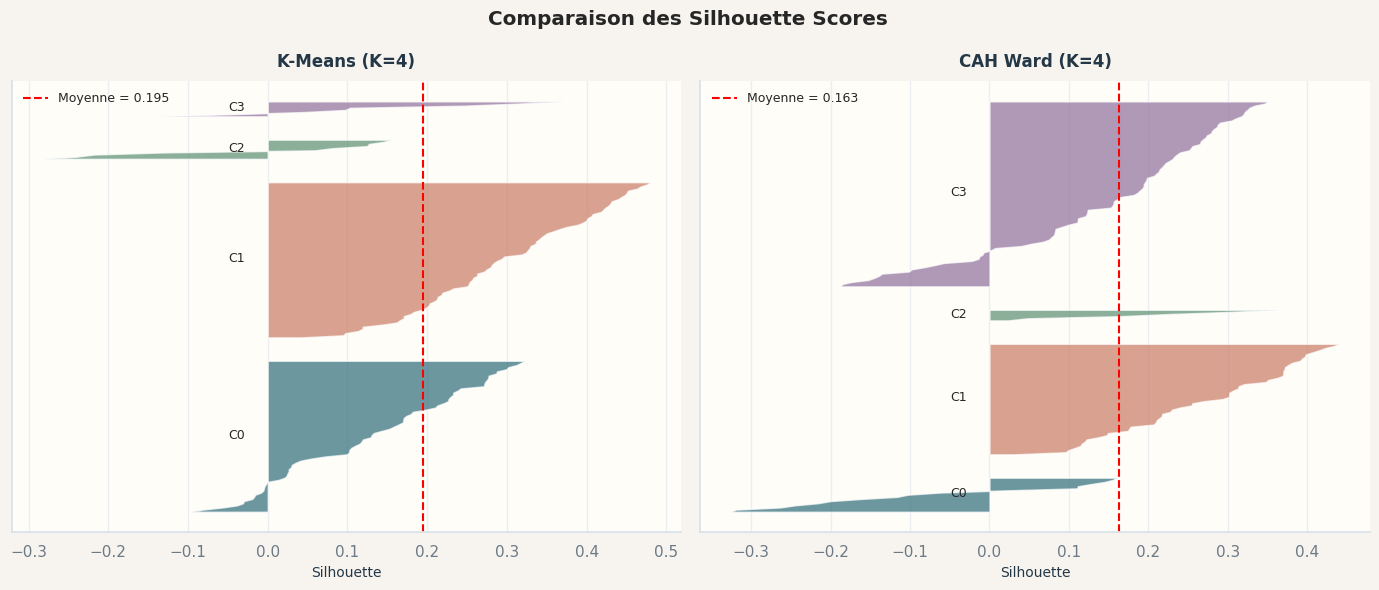

K-Means (K=4) : silhouette = 0.195
CAH Ward (K=4) : silhouette = 0.163


In [46]:
labels_km = df_pca['cluster'].values
labels_cah_arr = fcluster(Z, K_cah, criterion='maxclust') - 1

methods = {
    f'K-Means (K={K})': labels_km,
    f'CAH Ward (K={K_cah})': labels_cah_arr,
}

fig, axes = plt.subplots(1, len(methods), figsize=(14, 6))

for ax, (name, labels) in zip(axes, methods.items()):
    score = silhouette_score(X_clust, labels)
    sample_scores = silhouette_samples(X_clust, labels)
    y_lower = 10
    n_clusters = len(set(labels))

    for k in range(n_clusters):
        cluster_scores = np.sort(sample_scores[labels == k])
        size = len(cluster_scores)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores, alpha=0.7)
        ax.text(-0.05, y_lower + size / 2, f'C{k}', fontsize=9, va='center')
        y_lower = y_upper + 10

    ax.axvline(score, color='red', linestyle='--', label=f'Moyenne = {score:.3f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Silhouette')
    ax.set_yticks([])
    ax.legend(fontsize=9)

plt.suptitle('Comparaison des Silhouette Scores', fontweight='bold')
plt.tight_layout()
plt.show()

for name, labels in methods.items():
    print(f'{name} : silhouette = {silhouette_score(X_clust, labels):.3f}')

#### Interprétation des silhouettes

Les deux scores de silhouette sont nettement plus faibles qu'en dimension 2. Cette chute était prévisible : avec 15 variables, les distances se diluent et les frontières entre profils de pays deviennent progressives plutôt que tranchées. C'est d'ailleurs pour cette raison qu'on a dû projeter les résultats sur les deux premières composantes de l'ACP, qui ne captent ensemble qu'environ la moitié de l'inertie totale $\rightarrow$ des clusters bien séparés en dimension 15 peuvent donc paraître chevauchants une fois projetés sur ce plan.

Les scores négatifs, nombreux dans les deux méthodes, confirment ce constat. Certains clusters présentent des silhouettes quasi entièrement négatives, ce qui signifie que leurs membres sont en moyenne plus proches d'un autre groupe que du leur. Ce sont des pays "frontaliers" dont le profil énergétique ne s'inscrit franchement dans aucune catégorie. Il s'agit d'un phénomène cohérent avec la réalité, quand on pense à des pays comme l'Irlande ou l'Ouzbékistan qui combinent des caractéristiques de plusieurs profils.

On remarque aussi un fort déséquilibre des effectifs dans les deux cas, particulièrement marqué pour la CAH qui concentre l'essentiel des pays dans un seul cluster. Cette asymétrie tire mécaniquement les silhouettes vers le bas : les gros clusters hétérogènes ont des distances intra-cluster élevées, ce qui comprime le score.

Malgré des performances globales modestes, le K-Means reste légèrement plus cohérent et produit des clusters mieux équilibrés. On retient donc la **partition K-Means** pour la suite de l'analyse.

### 9.7 Caractérisation des clusters


In [47]:
rows = []
for k in range(K):
    grp = df_pca[df_pca['cluster'] == k]
    r = {'Cluster': f'Cluster {k}', 'N pays': len(grp)}
    for v, l in zip(acp_vars, acp_labels):
        r[l] = grp[v].mean()
    rows.append(r)

char_df = pd.DataFrame(rows).set_index('Cluster')
print(char_df.to_string(float_format='{:.3f}'.format))

print()
for k in range(K):
    grp = df_pca[df_pca['cluster'] == k]
    top5 = ', '.join(grp.nlargest(5, 'co2')['country'].tolist())
    print(f'  Cluster {k} - Top 5 émetteurs : {top5}')

           N pays  CO2/hab   PIB/hab  Part Charbon  Part Pétrole  Part Gaz  Part Élec.  Part Transport  Part Industrie  CH4 Agri./hab  CH4 Fugitif/hab  CH4 Déchets/hab  N2O Agri./hab  F-gaz Indus./hab  Intens. énerg.  Intens. carbone
Cluster                                                                                                                                                                                                                                  
Cluster 0      72    5.212 23263.068         0.300         0.369     0.259       0.390           0.217           0.139          0.413            0.432            0.329          0.286             0.203     1324430.842       280093.229
Cluster 1      74    1.675 10932.183         0.062         0.765     0.083       0.226           0.448           0.123          0.554            0.069            0.304          0.280             0.072      809098.349       169259.363
Cluster 2      10   19.643 44485.829         0.003         0.327

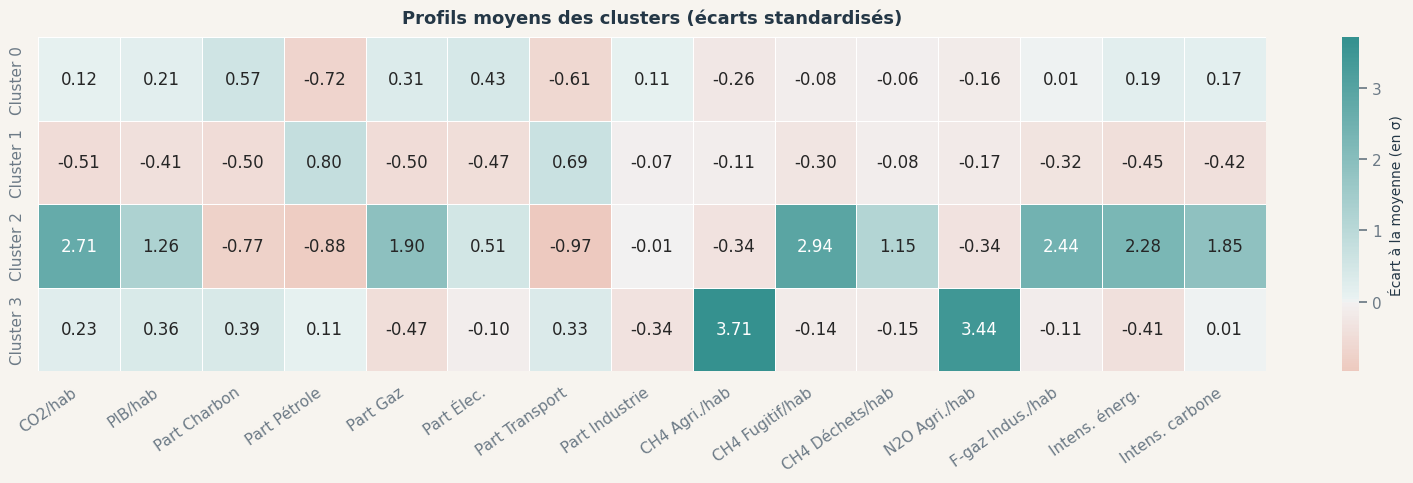

In [48]:
# écarts à la moyenne globale (en nombre d'écarts-types)
global_mean = df_pca[acp_vars].mean().values
global_std = df_pca[acp_vars].std().values

means_centered = []
for k in range(K):
    grp = df_pca[df_pca['cluster'] == k]
    means_centered.append((grp[acp_vars].mean().values - global_mean) / global_std)

means_centered = np.array(means_centered)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(means_centered, annot=True, fmt='.2f', cmap=HEATMAP_CMAP, center=0,
            xticklabels=acp_labels,
            yticklabels=[f'Cluster {k}' for k in range(K)],
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Écart à la moyenne (en σ)'})
ax.set_title('Profils moyens des clusters (écarts standardisés)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

#### Lecture de la heatmap

Chaque case indique de combien d'écarts-types le cluster s'éloigne de la moyenne mondiale sur cette variable. Les profils sont clairs :

- **Cluster 0** : pays industrialisés à mix charbon/gaz/élec élevé, faible transport $\rightarrow$ **profil "usine du monde" (Chine, Inde, Russie)**
- **Cluster 1** : émissions basses sur toute la ligne, seule la part pétrole/transport ressort $\rightarrow$ **pays en développement ou économies de services (Brésil, France, Nigéria)**
- **Cluster 2** : valeurs extrêmes sur CO2/hab, gaz, CH4 fugitif, intensité énergétique $\rightarrow$ **pays pétroliers/gaziers du Golfe**
- **Cluster 3** : CH4 agri. et N2O agri. explosent (+3.7σ et +3.4σ), le reste est proche de la moyenne $\rightarrow$ **pays agro-exportateurs (Australie, Nouvelle-Zélande, Uruguay)**

C'est le cluster 3 qui est le plus intéressant : invisible en classification 2D (Phase 1), il n'émerge qu'en intégrant les émissions non-CO2 détaillées.


### 9.8 Projection 3D interactive


Pour mieux apprécier la structure des clusters, on projette cette fois sur les trois premières composantes de l'ACP (C1, C2 et C3). En passant de deux à trois axes, on récupère près de **60 %** de l'inertie totale contre seulement 46 % précédemment, ce qui donne une représentation plus fidèle des distances réelles entre pays dans l'espace à 15 dimensions.

In [49]:
fig = go.Figure()

for k in range(K):
    mask = df_pca['cluster'].values == k
    fig.add_trace(go.Scatter3d(
        x=Y_proj[mask, 0], y=Y_proj[mask, 1], z=Y_proj[mask, 2],
        mode='markers',
        marker=dict(size=4, color=CLUSTER_COLORS[k], opacity=0.75,
                    line=dict(width=0.3, color='white')),
        text=countries[mask],
        name=f'Cluster {k} ({mask.sum()})',
        hovertemplate='%{text}<br>C1: %{x:.2f}<br>C2: %{y:.2f}<br>C3: %{z:.2f}<extra></extra>',
    ))

fig.update_layout(
    height=650,
    title_text=f'Classification K-Means (K={K}) - Projection 3D',
    scene=dict(
        xaxis_title=f'C1 ({contribs[0]*100:.1f}%)',
        yaxis_title=f'C2 ({contribs[1]*100:.1f}%)',
        zaxis_title=f'C3 ({contribs[2]*100:.1f}%)',
        bgcolor=PALETTE['panel'],
    ),
    margin=dict(t=50, b=10, l=10, r=10),
)
fig.show()

#### Interprétation

Comme nous pouvons le voir, en effet, en trois dimensions, on distingue nettement mieux les clusters, **car la projection selon trois composantes principales permet de réduire les chevauchements observés en 2D et de mieux capturer la structure intrinsèque des données**. On observe ainsi une séparation plus claire entre certains groupes, même si quelques points restent proches ou partiellement superposés, ce qui suggère des similarités entre ces observations ou une variance non totalement expliquée par ces trois composantes.

### 9.9 Synthèse de la classification N > 2

La classification en 15 dimensions identifie **4 profils de pays** plus nuancés qu'en Phase 1 :

| Cluster | Profil                                                                                            | Pays caractéristiques                          |
| ------- | ------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| **0**   | Pays industrialisés à mix diversifié (charbon + gaz + pétrole), émissions moyennes                | Chine, USA, Inde, Russie, Japon                |
| **1**   | Pays à faibles émissions, dominés par le pétrole et le transport, peu d'industrie lourde          | Brésil, France, Nigéria, Colombie              |
| **2**   | Pays pétroliers/gaziers à très fortes émissions, forte intensité énergétique et CH4 fugitif élevé | Arabie Saoudite, Qatar, Koweït, EAU            |
| **3**   | Pays à fortes émissions agricoles (CH4 + N2O), profil agro-exportateur                            | Australie, Nouvelle-Zélande, Uruguay, Paraguay |

**Apport par rapport à la Phase 1 :** la classification 2D (CO2/hab × PIB/hab) ne distinguait pas les pays agricoles des pays fossiles. En intégrant les 15 variables, on voit émerger un **cluster agricole** (cluster 3) totalement invisible en 2D - ce sont des pays à CO2/hab modéré mais à très fortes émissions de méthane et de N2O. C'est cohérent avec l'axe C3 de l'ACP qui isolait cette dimension.

La CAH et le K-Means produisent des partitions proches, ce qui confirme la robustesse de la structure identifiée.


## 10. Conclusion générale

### Retour sur la problématique

La question centrale était : **quels déterminants expliquent le mieux les émissions de CO2 par habitant, et sur quels leviers agir ?** L'hypothèse de Phase 1 supposait que le mix énergétique combiné au PIB/hab serait le meilleur prédicteur. Nos trois analyses de Phase 2 permettent d'y répondre.

### Ce que chaque analyse a apporté

**L'ACP** a révélé que la structure des émissions mondiales ne se résume pas à un ou deux facteurs. Il faut **5 dimensions** pour capturer 76% de l'information : l'intensité fossile (C1, 32%), le type de combustible (C2, 14%), les émissions agricoles (C3, 13%), l'efficacité économique (C4) et la structure industrielle (C5). Le PIB/hab, que la Phase 1 plaçait au centre, se retrouve diffus sur plusieurs axes $\Rightarrow$ ce n'est pas ***le*** facteur structurant, c'est ***un*** facteur parmi d'autres.

**La régression multiple** confirme ce résultat quantitativement : le PIB/hab seul explique 56% du CO2/hab, mais en ajoutant 5 variables on atteint **85%**. Les 29% de $R^2$ gagnés viennent intégralement de la structure énergétique et industrielle. Autrement dit, à richesse égale, c'est le **choix du mix énergétique** qui fait la différence.

**La classification en 15 dimensions** a fait émerger un profil invisible en 2D : les **pays agro-exportateurs** (Australie, Nouvelle-Zélande, Uruguay), dont le CO2/hab est modéré mais dont les émissions de CH4 et N2O agricoles explosent à +3.7 $\times \sigma$ au-dessus de la moyenne mondiale. Ce groupe n'existait pas dans la classification Phase 1 $\rightarrow$ il fallait intégrer les GES non-CO2 pour le voir.

### Réponse à l'hypothèse

L'hypothèse est **partiellement confirmée** : le mix énergétique est bien un prédicteur majeur, mais il ne suffit pas. Les émissions non-CO2 (méthane agricole, émissions fugitives, F-gaz) apportent une dimension propre, indépendante du CO2 fossile, et indispensable pour comprendre le profil complet d'un pays.

### Leviers d'action identifiés

Nos analyses convergent vers trois leviers prioritaires :

1. **Sortie du charbon** : la part du charbon structure un axe entier de l'ACP (C2) et reste significative dans la régression même après contrôle du PIB/hab
2. **Réduction des fuites de méthane** : le CH4 fugitif (lié à l'extraction fossile) est le 2ème prédicteur le plus fort du modèle - un levier à fort impact et à coût relativement faible
3. **Transition agricole** : les émissions de CH4 et N2O agricoles forment une dimension totalement indépendante du CO2, souvent ignorée dans les politiques climatiques centrées sur les fossiles

### Limites

- Les données sont annuelles et par pays : elles ne captent pas les inégalités infra-nationales ni les dynamiques infra-annuelles
- La convention EDGAR (NaN → 0) peut sous-estimer les émissions des pays à faible capacité statistique
- Le modèle de régression est linéaire : des interactions non-linéaires entre variables pourraient améliorer le pouvoir explicatif